In [17]:
print("Ibrahim Dodo")
print("Predictive Modeling of New Zealand Real-Time Dispatch Energy Prices")

Ibrahim Dodo
Predictive Modeling of New Zealand Real-Time Dispatch Energy Prices


In [ ]:
# Loading and Inspection
import pandas as pd
import os


DATA_PATH = './data/EMI_Filtered_2023_2025.csv'

print("Loading dataset into memory...")
df = pd.read_csv(DATA_PATH)

# Convert date columns to proper datetime objects for easier inspection
df['TradingDate'] = pd.to_datetime(df['TradingDate'])
df['PublishDateTime'] = pd.to_datetime(df['PublishDateTime'])

# Basic Shape
print(f"\n1. Dataset Shape")
print(f"Total Rows: {df.shape[0]:,}")
print(f"Total Columns: {df.shape[1]}")

# Check for Missing Values (Crucial for our pipeline)
print("\n2. Missing Values")
print(df.isna().sum())

# Quick look at the Time Range and Target Nodes
print("\n3. Time Range & Nodes")
print(f"Start Date: {df['TradingDate'].min().date()}")
print(f"End Date:   {df['TradingDate'].max().date()}")
print(f"Target PoCs: {df['PointOfConnection'].unique().tolist()}")

# Statistical Summary of the Target Variable (Price Spikes!)
print("\n4. Price Distribution ($/MWh)")
# Formatting to 2 decimal places so it's readable
print(df['DollarsPerMegawattHour'].describe().apply(lambda x: f"{x:,.2f}"))

# Display the first 10 rows to inspect the irregular 'PublishDateTime'
print("\n5. First 10 Rows")
display(df.head(10))

Loading dataset into memory...


/var/folders/x7/vxp2byts2kd3j_zk5_3ksgdm0000gn/T/ipykernel_93944/3460075299.py:13: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df['PublishDateTime'] = pd.to_datetime(df['PublishDateTime'])



1. Dataset Shape
Total Rows: 919,614
Total Columns: 7

2. Missing Values
TradingDate               0
TradingPeriod             0
PublishDateTime           0
PointOfConnection         0
Island                    0
IsProxyPriceFlag          0
DollarsPerMegawattHour    0
dtype: int64

3. Time Range & Nodes
Start Date: 2023-01-01
End Date:   2025-12-31
Target PoCs: ['HLY2201', 'OTA2201', 'BEN2201']

4. Price Distribution ($/MWh)
count    919,614.00
mean         157.35
std          154.14
min            0.00
25%           50.00
50%          147.95
75%          230.18
max        9,137.58
Name: DollarsPerMegawattHour, dtype: object

5. First 10 Rows


,TradingDate,TradingPeriod,PublishDateTime,PointOfConnection,Island,IsProxyPriceFlag,DollarsPerMegawattHour
0,2023-01-01,1,2022-12-31 23:59:44+13:00,HLY2201,NI,N,5.13
1,2023-01-01,1,2022-12-31 23:59:44+13:00,OTA2201,NI,N,5.15
2,2023-01-01,1,2022-12-31 23:59:44+13:00,BEN2201,SI,N,5.05
3,2023-01-01,1,2023-01-01 00:04:43+13:00,HLY2201,NI,N,4.57
4,2023-01-01,1,2023-01-01 00:04:43+13:00,OTA2201,NI,N,4.58
5,2023-01-01,1,2023-01-01 00:04:43+13:00,BEN2201,SI,N,4.69
6,2023-01-01,1,2023-01-01 00:10:04+13:00,HLY2201,NI,N,4.10
7,2023-01-01,1,2023-01-01 00:10:04+13:00,OTA2201,NI,N,4.11
8,2023-01-01,1,2023-01-01 00:10:04+13:00,BEN2201,SI,N,4.04
9,2023-01-01,1,2023-01-01 00:14:42+13:00,HLY2201,NI,N,4.09


In [3]:
# Investigating Extreme Price Spikes

print("Hunting for the biggest price spikes...\n")

# Sort the dataset from highest price to lowest, and grab the top 20
top_spikes = df.sort_values(by='DollarsPerMegawattHour', ascending=False).head(20)

# Select just the columns we care about for readability
columns_to_show = ['TradingDate', 'TradingPeriod', 'PublishDateTime', 'PointOfConnection', 'DollarsPerMegawattHour']

# Reset the index for a clean display
top_spikes = top_spikes[columns_to_show].reset_index(drop=True)

# Display the result
display(top_spikes)

# Let's also see WHICH year had the most spikes over $1,000
print("\n--- Number of times price exceeded $1,000/MWh per year ---")
df['Year'] = df['TradingDate'].dt.year
spikes_per_year = df[df['DollarsPerMegawattHour'] > 1000].groupby('Year').size()
print(spikes_per_year)

Hunting for the biggest price spikes...



,TradingDate,TradingPeriod,PublishDateTime,PointOfConnection,DollarsPerMegawattHour
0,2023-06-09,16,2023-06-09 07:30:23+12:00,BEN2201,9137.58
1,2023-05-16,15,2023-05-16 07:05:26+12:00,BEN2201,8613.25
2,2024-09-17,17,2024-09-17 08:19:39+12:00,OTA2201,6690.68
3,2024-09-17,17,2024-09-17 08:14:58+12:00,OTA2201,6690.67
4,2024-09-17,17,2024-09-17 08:19:39+12:00,HLY2201,6482.42
5,2024-09-17,17,2024-09-17 08:14:58+12:00,HLY2201,6482.42
6,2024-09-17,17,2024-09-17 08:14:58+12:00,BEN2201,6001.18
7,2024-09-17,17,2024-09-17 08:19:39+12:00,BEN2201,6001.18
8,2023-01-24,34,2023-01-24 16:30:41+13:00,OTA2201,5847.14
9,2024-12-12,18,2024-12-12 08:30:49+13:00,OTA2201,5726.47



--- Number of times price exceeded $1,000/MWh per year ---
Year
2023    357
2024    351
2025     96
dtype: int64


In [4]:
print("Analyzing Price Ranges Across Years...\n")

# Ensure we have a Year column
if 'Year' not in df.columns:
    df['Year'] = df['TradingDate'].dt.year

# Extreme Spikes (>= $1000)
spikes_per_year = df[df['DollarsPerMegawattHour'] >= 1000].groupby('Year').size()
print("--- Number of times price exceeded $1,000/MWh per year ---")
print("Year")
if not spikes_per_year.empty:
    print(spikes_per_year.to_string(header=False))
else:
    print("None")

# Normal/Elevated Prices (>= $10 and < $1000)
mid_prices = df[(df['DollarsPerMegawattHour'] >= 10) & (df['DollarsPerMegawattHour'] < 1000)].groupby('Year').size()
print("\n--- Number of times price was between $10 and $1,000/MWh per year ---")
print("Year")
print(mid_prices.to_string(header=False))

# Very Low/Free Prices (< $10)
low_prices = df[df['DollarsPerMegawattHour'] < 10].groupby('Year').size()
print("\n--- Number of times price was less than $10/MWh per year ---")
print("Year")
print(low_prices.to_string(header=False))

Analyzing Price Ranges Across Years...

--- Number of times price exceeded $1,000/MWh per year ---
Year
2023    357
2024    351
2025     96

--- Number of times price was between $10 and $1,000/MWh per year ---
Year
2023    275076
2024    264643
2025    227043

--- Number of times price was less than $10/MWh per year ---
Year
2023    36972
2024    52208
2025    62868



Price Distribution per PoC


,count,mean,std,min,25%,50%,75%,max
PointOfConnection,,,,,,,,
BEN2201,"306,538.00",151.00,150.24,0.00,37.97,136.39,227.56,"9,137.58"
HLY2201,"306,538.00",158.60,153.62,0.01,53.99,150.28,229.60,"6,482.42"
OTA2201,"306,538.00",162.45,158.23,0.01,54.96,153.80,234.44,"6,690.68"



Spike counts per PoC (>$1,000/MWh):
PointOfConnection
BEN2201    212
HLY2201    290
OTA2201    302
Name: spike_count, dtype: int64

Negative price counts per PoC:
Series([], Name: negative_count, dtype: int64)


/var/folders/x7/vxp2byts2kd3j_zk5_3ksgdm0000gn/T/ipykernel_93944/1669751246.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='PointOfConnection', y='DollarsPerMegawattHour', data=df, palette='Set2')


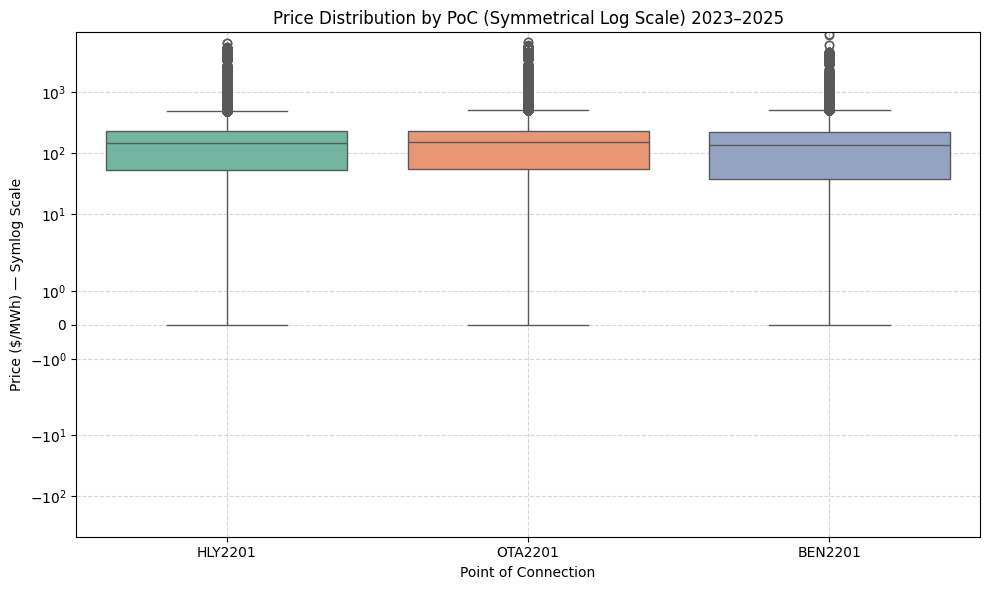


Year-on-year median price per PoC:
Year                 2023    2024    2025
PointOfConnection                        
BEN2201            113.15  197.71  145.24
HLY2201            131.39  204.04  154.30
OTA2201            133.96  208.31  158.10


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\nPrice Distribution per PoC")

# Statistical summary
poc_stats = df.groupby('PointOfConnection')['DollarsPerMegawattHour'].describe()
display(poc_stats.map(lambda x: f"{x:,.2f}"))

# Spike counts per PoC 
print("\nSpike counts per PoC (>$1,000/MWh):")
print(df[df['DollarsPerMegawattHour'] > 1000].groupby('PointOfConnection').size().rename('spike_count'))

# Negative price counts per PoC 
print("\nNegative price counts per PoC:")
print(df[df['DollarsPerMegawattHour'] < 0]
      .groupby('PointOfConnection')
      .size()
      .rename('negative_count'))

plt.figure(figsize=(10, 6))
sns.boxplot(x='PointOfConnection', y='DollarsPerMegawattHour', data=df, palette='Set2')
plt.yscale('symlog')
plt.title('Price Distribution by PoC (Symmetrical Log Scale) 2023–2025')
plt.ylabel('Price ($/MWh) — Symlog Scale')
plt.xlabel('Point of Connection')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.savefig('./data/boxplot_price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Year-on-year median per PoC 
df['Year'] = pd.to_datetime(df['TradingDate']).dt.year
print("\nYear-on-year median price per PoC:")
print(df.groupby(['PointOfConnection', 'Year'])['DollarsPerMegawattHour'].median().round(2).unstack())

In [6]:
# Confirming Island consistency
print(df.groupby(['PointOfConnection', 'Island']).size())

# Confirming no duplicate rows per PoC + TradingDate + TradingPeriod + PublishDateTime
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")

# Confirming TradingDate is parseable as datetime
df['TradingDate'] = pd.to_datetime(df['TradingDate'])
print(f"TradingDate dtype: {df['TradingDate'].dtype}")

PointOfConnection  Island
BEN2201            SI        306538
HLY2201            NI        306538
OTA2201            NI        306538
dtype: int64
Duplicate rows: 0
TradingDate dtype: datetime64[ns]


In my design choice, BEN2201 (Benmore) is excluded because its price dynamics are dominated by HVDC congestion and hydro‑versus‑thermal effects, as seen in the spike table, so it is not representative of the nodal signal we want to model. This work targets cross‑node information value, and spike detectability. The target variable is the settled price, defined as the last published final price per trading period, because this aligns with how the market is actually settled and how participants experience prices. The index is TradingDate + TradingPeriod in local clock time, with a daylight‑saving caveat that there are a small number of irregular periods each year, which are kept as‑is. Missing data are handled with a selective forward‑fill policy: runs of ≤ 4 consecutive missing periods (≤ 2 hours) are filled and flagged with is_imputed; longer runs are left as NaN so the model never sees invented prices during extended outages (see gap audit below).

** Regime-aware data split**

The dataset is split strictly by time into four non-overlapping partitions. The split boundaries were chosen to isolate a documented regime shift: 2023–2024 was characterised by fuel scarcity (low hydro storage, elevated gas prices peaking in August 2024) producing frequent high-price spikes (357 and 351 events above $1,000/MWh respectively), whereas 2025 saw hydro recovery and a substantially calmer market (96 events). Training on 2023–2024 and then evaluating on both a held-out 2024 window and all of 2025 lets us separately report in-regime and out-of-regime performance, which is more informative than averaging accuracy across a structural break.


Train | Jan 2023 → Mar 2024 | High-volatility | Fit all models |

Validate | Apr 2024 → Jun 2024 | High-volatility | Hyperparameter tuning |
Test-A | Jul 2024 → Dec 2024 | In-regime (high-volatility) | Evaluate under training conditions |
Test-B | Jan 2025 → Dec 2025 | Out-of-regime (calmer) | Evaluate under regime shift |

Note: Test-B contains a 22-day data outage (10 Sep – 2 Oct 2025) that is retained as NaN. Supervised examples whose lag window overlaps this gap are automatically excluded by the dropna() step in the feature builder, so no imputed values contaminate model evaluation.


In [ ]:
# Sanity check 
import pandas as pd

# Building the full 30-min master timeline from the existing df
settled = (df.sort_values(['PointOfConnection','TradingDate','TradingPeriod','PublishDateTime'])
             .groupby(['PointOfConnection','TradingDate','TradingPeriod'])
             ['DollarsPerMegawattHour'].last()
             .reset_index())

settled['Datetime'] = settled['TradingDate'] + pd.to_timedelta((settled['TradingPeriod']-1)*30, unit='m')

global_start = settled['Datetime'].min()
global_end   = settled['Datetime'].max()
full_idx     = pd.date_range(global_start, global_end, freq='30min')
print(f"Master timeline: {global_start} -> {global_end}  ({len(full_idx):,} periods)\n")

for poc in ['HLY2201', 'OTA2201', 'BEN2201']:
    s = (settled.loc[settled['PointOfConnection']==poc]
                .set_index('Datetime')['DollarsPerMegawattHour']
                .groupby(level=0).last()   # ← collapses duplicate timestamps
                .reindex(full_idx))

    na = s.isna().astype(int)
    groups = (na.diff() != 0).cumsum()
    run_lengths = na.groupby(groups).sum()
    run_lengths = run_lengths[run_lengths > 0]   # keep only NaN-runs

    bins   = [0,1,2,4,10,48,96,float('inf')]
    labels = ['1','2','3-4','5-10','11-48','49-96','>96']
    binned = pd.cut(run_lengths, bins=bins, labels=labels).value_counts().sort_index()

    print(f"--- {poc} ---")
    print(f"  Total missing periods : {int(na.sum()):,}")
    print(f"  Number of gap runs    : {len(run_lengths):,}")
    print(f"  Run-length distribution (periods):")
    print(binned.to_string())

    # Let's see the 5 longest gaps with timestamps
    longest = run_lengths.nlargest(5)
    print(f"Longest 5 gaps:")
    for gid, length in longest.items():
        gap_idx = s.index[groups == gid]
        print(f"{gap_idx.min()}  ->  {gap_idx.max()}   ({int(length)} periods, ~{int(length)/2:.1f} h)")
    print()

Master timeline: 2023-01-01 00:00:00 -> 2025-12-31 23:30:00  (52,608 periods)

--- HLY2201 ---
  Total missing periods : 1,178
  Number of gap runs    : 49
  Run-length distribution (periods):
DollarsPerMegawattHour
1        31
2         9
3-4       6
5-10      1
11-48     1
49-96     0
>96       1
  Longest 5 gaps:
    2025-09-10 23:30:00  ->  2025-10-02 23:30:00   (1057 periods, ~528.5 h)
    2023-11-14 00:00:00  ->  2023-11-14 23:30:00   (48 periods, ~24.0 h)
    2024-08-14 10:30:00  ->  2024-08-14 12:30:00   (5 periods, ~2.5 h)
    2024-02-28 11:30:00  ->  2024-02-28 13:00:00   (4 periods, ~2.0 h)
    2023-04-27 11:30:00  ->  2023-04-27 12:30:00   (3 periods, ~1.5 h)

--- OTA2201 ---
  Total missing periods : 1,178
  Number of gap runs    : 49
  Run-length distribution (periods):
DollarsPerMegawattHour
1        31
2         9
3-4       6
5-10      1
11-48     1
49-96     0
>96       1
  Longest 5 gaps:
    2025-09-10 23:30:00  ->  2025-10-02 23:30:00   (1057 periods, ~528.5 h)
    

Missing 30‑min periods are forward-filled only for gaps ≤ 4 steps (2 hours). This is reasonable since prices usually stay in the same regime over that window, most gaps are short (46/49), and only ~0.13% of data is filled. Filled rows are flagged (is_imputed), and rows with imputed targets are excluded from training.
Long gaps (24h, 22d) remain NaN, and any features overlapping them are ignored.

In [ ]:
# Harmonisation & Resampling Pipeline

import numpy as np
import pandas as pd

# Configuration
TARGET_POCS = ['HLY2201', 'OTA2201']   # NI only, BEN excluded as it is loosely coupled to the 2 NI nodes
MAX_FFILL   = 4                        # 2 hours

# Filter to NI PoCs 
work = df[df['PointOfConnection'].isin(TARGET_POCS)].copy()

# Sorting chronologically within each PoC 
work = work.sort_values(by=['PointOfConnection', 'TradingDate', 'TradingPeriod', 'PublishDateTime'])

settled = (
    work.groupby(['PointOfConnection', 'TradingDate', 'TradingPeriod'])
        ['DollarsPerMegawattHour']
        .last()
        .reset_index()
)

# Datetime = TradingDate + (TP - 1) * 30 min places each period
# at the *start* of its 30-minute slot.
settled['Datetime'] = (
    settled['TradingDate']
    + pd.to_timedelta((settled['TradingPeriod'] - 1) * 30, unit='m')
)

# Master timeline — same for every PoC (this is what guarantees invariant I2)
global_start    = settled['Datetime'].min()
global_end      = settled['Datetime'].max()
full_time_index = pd.date_range(global_start, global_end, freq='30min')


# Selective forward-fill 
def selective_ffill(s: pd.Series, max_run: int):
    """
    Forward-fill ONLY NaN runs of length <= max_run.

    Returns
    -------
    filled : pd.Series
        Same index as s. Short NaN runs are filled; long NaN runs stay NaN.
    is_imputed : pd.Series (bool)
        True iff that position was NaN in `s` AND has a value in `filled`.
        Leading-NaN positions that ffill cannot fill are NOT flagged.
    """
    na = s.isna()

    groups = (na.astype(int).diff().fillna(0) != 0).cumsum()

    run_size = na.astype(int).groupby(groups).transform('sum')

    long_nan = na & (run_size > max_run)   # must remain NaN

    filled = s.ffill()                     # ffill everything first
    filled.loc[long_nan] = np.nan          # then restore the long runs

    # True only where we ACTUALLY produced a value from a NaN
    is_imputed = na & filled.notna()
    return filled, is_imputed


poc_dict = {}
print("Harmonising per PoC")
print("-" * 60)

for poc in TARGET_POCS:
    # Pull this PoC's settled prices onto the master 30-min grid.
    s = (
        settled.loc[settled['PointOfConnection'] == poc]
               .set_index('Datetime')['DollarsPerMegawattHour']
               .groupby(level=0).last()
               .reindex(full_time_index)
    )

    # Application of selective forward-fill 
    price, is_imputed = selective_ffill(s, MAX_FFILL)

    poc_dict[poc] = pd.DataFrame({
        'DollarsPerMegawattHour': price,
        'is_imputed': is_imputed.astype(bool),
    })

    print(
        f"  {poc:8s} | shape {poc_dict[poc].shape} "
        f"| imputed: {int(is_imputed.sum()):4d} "
        f"| remaining NaN: {int(price.isna().sum()):5d}"
    )


# Verification block — invariants I1-I6 (acceptance tests)
print("\nVerifying invariants")
print("-" * 60)

expected_index = pd.date_range(global_start, global_end, freq='30min')

for poc, frame in poc_dict.items():
    # I1: regular 30-min index equal to the master timeline
    assert frame.index.equals(expected_index), f"{poc}: index mismatch (I1)"

    # I3: exactly two columns, in the contracted order
    assert list(frame.columns) == ['DollarsPerMegawattHour', 'is_imputed'], \
        f"{poc}: column contract violated (I3)"

    # I4: is_imputed and NaN are mutually exclusive
    overlap = (frame['is_imputed'] & frame['DollarsPerMegawattHour'].isna()).sum()
    assert overlap == 0, f"{poc}: is_imputed overlaps NaN at {overlap} rows (I4)"

    # Report the longest residual NaN run (expected: 1057 = the 22-day gap)
    na = frame['DollarsPerMegawattHour'].isna()
    grp = (na.astype(int).diff().fillna(0) != 0).cumsum()
    runs = na.astype(int).groupby(grp).sum()
    longest = int(runs.max()) if (runs > 0).any() else 0
    print(f"  {poc:8s} | longest residual NaN run: {longest} periods")

# I2: indices identical across PoCs (cross-node alignment guarantee)
assert poc_dict['HLY2201'].index.equals(poc_dict['OTA2201'].index), \
    "Indices differ across PoCs (I2)"

print("\nAll invariants satisfied.")

# Preview
print("\nPreview — HLY2201 first 5 rows")
display(poc_dict['HLY2201'].head())

Harmonising per PoC
------------------------------------------------------------
  HLY2201  | shape (52608, 2) | imputed:   68 | remaining NaN:  1110
  OTA2201  | shape (52608, 2) | imputed:   68 | remaining NaN:  1110

Verifying invariants
------------------------------------------------------------
  HLY2201  | longest residual NaN run: 1057 periods
  OTA2201  | longest residual NaN run: 1057 periods

All invariants satisfied.

Preview — HLY2201 first 5 rows


,DollarsPerMegawattHour,is_imputed
2023-01-01 00:00:00,0.03,False
2023-01-01 00:30:00,4.09,False
2023-01-01 01:00:00,4.14,False
2023-01-01 01:30:00,5.00,False
2023-01-01 02:00:00,4.06,False


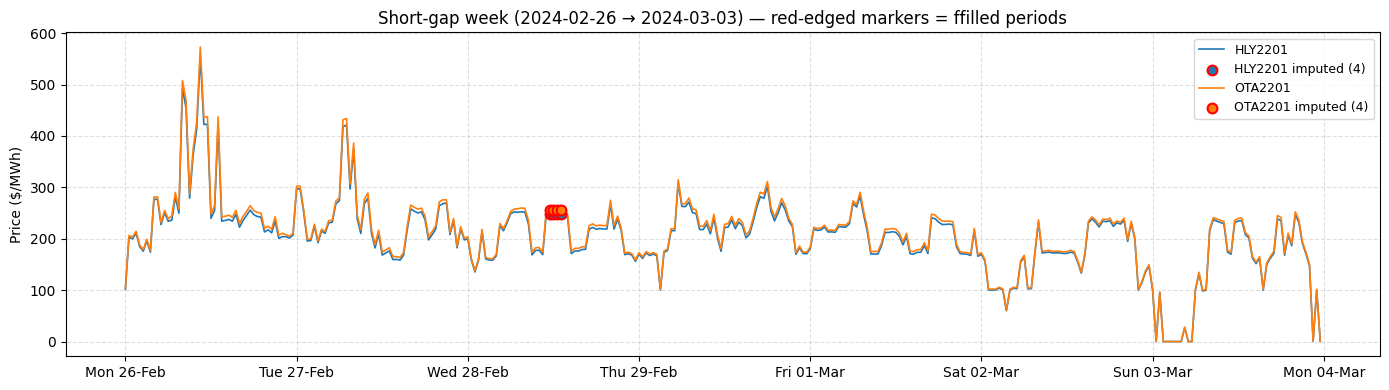

In [ ]:
# Sanity-check plot for the harmonised series (Short Gap)


import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# --- Helper: extract contiguous-True runs from a boolean Series ---
def boolean_runs(mask: pd.Series):
    """Yield (start_ts, end_ts) for every contiguous run of True in mask."""
    arr = mask.astype(int)
    grp = (arr.diff().fillna(0) != 0).cumsum()
    for _, sub in arr.groupby(grp):
        if sub.iloc[0] == 1:
            yield sub.index.min(), sub.index.max()

# --- Shared Windows and Config ---
short_window = ('2024-02-26', '2024-03-03 23:59')   # contains short imputation
long_window  = ('2025-09-01', '2025-10-15 23:59')   # contains the 22-day NaN
colours = {'HLY2201': 'tab:blue', 'OTA2201': 'tab:orange'}

# --- Subplot (a): short-gap week ---
fig, ax = plt.subplots(figsize=(14, 4))

for poc, colour in colours.items():
    f = poc_dict[poc].loc[short_window[0]:short_window[1]]
    ax.plot(f.index, f['DollarsPerMegawattHour'],
            label=poc, color=colour, linewidth=1.2)

    # Overlay markers at imputed positions for visual verification
    imp = f[f['is_imputed']]
    if len(imp):
        ax.scatter(imp.index, imp['DollarsPerMegawattHour'],
                   color=colour, edgecolor='red', linewidth=1.5,
                   s=50, zorder=5,
                   label=f'{poc} imputed ({len(imp)})')

ax.set_title('Short-gap week (2024-02-26 → 2024-03-03) — red-edged markers = ffilled periods')
ax.set_ylabel('Price ($/MWh)')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, ls='--', alpha=0.4)
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%a %d-%b'))

plt.tight_layout()
plt.savefig('./data/phase3_harmonisation_check_short.png', dpi=150, bbox_inches='tight')
plt.show()

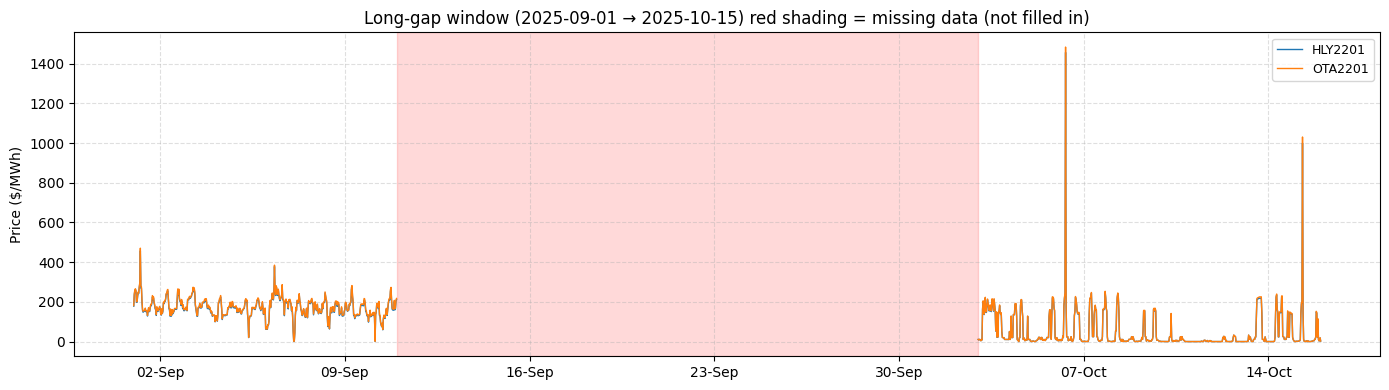


Counts within the plotted windows:
  HLY2201: short-window imputed = 4, long-window NaN      = 1057
  OTA2201: short-window imputed = 4, long-window NaN      = 1057


In [ ]:
fig, ax = plt.subplots(figsize=(14, 4))

for poc, colour in colours.items():
    f = poc_dict[poc].loc[long_window[0]:long_window[1]]
    ax.plot(f.index, f['DollarsPerMegawattHour'],
            label=poc, color=colour, linewidth=1.0)

ref = poc_dict['HLY2201'].loc[long_window[0]:long_window[1]]
for start, end in boolean_runs(ref['DollarsPerMegawattHour'].isna()):
    ax.axvspan(start, end, color='red', alpha=0.15)

ax.set_title('Long-gap window (2025-09-01 → 2025-10-15) red shading = missing data (not filled in)')
ax.set_ylabel('Price ($/MWh)')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, ls='--', alpha=0.4)
ax.xaxis.set_major_locator(mdates.WeekdayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))

plt.tight_layout()
plt.savefig('./data/phase3_harmonisation_check_long.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nCounts within the plotted windows:")
for poc in colours:
    short = poc_dict[poc].loc[short_window[0]:short_window[1]]
    longw = poc_dict[poc].loc[long_window[0]:long_window[1]]
    print(f"  {poc}: "
          f"short-window imputed = {int(short['is_imputed'].sum())}, "
          f"long-window NaN = {int(longw['DollarsPerMegawattHour'].isna().sum())}")

Feature Enginerring 


In [ ]:
# Feature Engineering


TARGET_POCS = ['HLY2201', 'OTA2201']
PARTNER     = {'HLY2201': 'OTA2201', 'OTA2201': 'HLY2201'}

# --- Window sizes (all in 30-min periods) ---
LAGS         = [1, 2, 4, 48, 336]   # 30min, 1h, 2h, 24h, 7d
ROLL_WINDOWS = [4, 48]              # 2h, 24h rolling stats
CROSS_LAGS   = [1, 48]              # partner-node lags


def build_features(target_poc: str) -> pd.DataFrame:
    """Construct the supervised matrix for a target PoC."""
    own     = poc_dict[target_poc]['DollarsPerMegawattHour']
    own_imp = poc_dict[target_poc]['is_imputed']
    partner = poc_dict[PARTNER[target_poc]]['DollarsPerMegawattHour']

    out = pd.DataFrame(index=own.index)
    out['y'] = own

    # i. Calendar features
    idx = out.index
    # trading_period (1–48) fully encodes time-of-day; 'hour' would be redundant.
    out['trading_period'] = (idx.hour * 2 + idx.minute // 30 + 1).astype('int16')
    out['day_of_week']    = idx.dayofweek.astype('int8')   # 'is_weekend' is redundant
    out['month']          = idx.month.astype('int8')

    # Cyclical encodings: model knows period 48 → period 1 is adjacent
    out['sin_period'] = np.sin(2 * np.pi * out['trading_period'] / 48)
    out['cos_period'] = np.cos(2 * np.pi * out['trading_period'] / 48)
    out['sin_doy']    = np.sin(2 * np.pi * idx.dayofyear / 365.25)
    out['cos_doy']    = np.cos(2 * np.pi * idx.dayofyear / 365.25)

    # ii. Own-node lag features 
    for k in LAGS:
        out[f'lag_{k}'] = own.shift(k)

    # iii. Own-node rolling stat
    # shift(1) before rolling so window covers [t-w, t-1] — excludes t itself.
    for w in ROLL_WINDOWS:
        shifted = own.shift(1)
        out[f'roll_mean_{w}'] = shifted.rolling(w, min_periods=w).mean()
        out[f'roll_std_{w}']  = shifted.rolling(w, min_periods=w).std()
    out['roll_max_48'] = own.shift(1).rolling(48, min_periods=48).max()

    # iv. Cross-node features (partner PoC information)
    for k in CROSS_LAGS:
        out[f'cross_lag_{k}'] = partner.shift(k)
    out['cross_spread_lag_1'] = own.shift(1) - partner.shift(1)

    # v. Imputation flag — kept for auditing, excluded from model inputs
    recent_imp = [own_imp.shift(k, fill_value=False) for k in [1, 2, 4]]
    out['feat_is_imputed_recent'] = (
        pd.concat(recent_imp, axis=1).any(axis=1).astype('int8'))

    # contract rules application 
    out = out.loc[~own_imp]   #drop rows where target was imputed
    out = out.dropna()        #drop rows with any NaN feature

    return out


# Build matrices 
features = {}
print("Building supervised matrices")
print("-" * 60)
for poc in TARGET_POCS:
    features[poc] = build_features(poc)
    print(f"  {poc:8s} | shape {features[poc].shape}")

# --- Define model input columns (excludes target and audit flag) ---
FEATURE_COLS = [c for c in features['HLY2201'].columns
                if c not in ('y', 'feat_is_imputed_recent')]


# Acceptance tests
print("\nVerifying feature-matrix contract")
print("-" * 60)
for poc in TARGET_POCS:
    f = features[poc]
    assert not f.isna().any().any(),         f"{poc}: NaN present"
    assert 'y' in f.columns,                 f"{poc}: target column missing"
    assert f.index.is_monotonic_increasing,  f"{poc}: index not monotonic"
    assert f.index.is_unique,                f"{poc}: duplicated index"
    print(f"  {poc:8s} | OK | model features = {len(FEATURE_COLS)} | rows = {f.shape[0]:,}")

print(f"\nFEATURE_COLS ({len(FEATURE_COLS)} total):")
for col in FEATURE_COLS:
    print(f"  - {col}")

print("\nPreview — HLY2201 first 3 rows")
display(features['HLY2201'][['y'] + FEATURE_COLS].head(3))


Building supervised matrices
------------------------------------------------------------
  HLY2201  | shape (50609, 22)
  OTA2201  | shape (50609, 22)

Verifying feature-matrix contract
------------------------------------------------------------
  HLY2201  | OK | model features = 20 | rows = 50,609
  OTA2201  | OK | model features = 20 | rows = 50,609

FEATURE_COLS (20 total):
  - trading_period
  - day_of_week
  - month
  - sin_period
  - cos_period
  - sin_doy
  - cos_doy
  - lag_1
  - lag_2
  - lag_4
  - lag_48
  - lag_336
  - roll_mean_4
  - roll_std_4
  - roll_mean_48
  - roll_std_48
  - roll_max_48
  - cross_lag_1
  - cross_lag_48
  - cross_spread_lag_1

Preview — HLY2201 first 3 rows


,y,trading_period,day_of_week,month,sin_period,cos_period,sin_doy,cos_doy,lag_1,lag_2,...,lag_48,lag_336,roll_mean_4,roll_std_4,roll_mean_48,roll_std_48,roll_max_48,cross_lag_1,cross_lag_48,cross_spread_lag_1
2023-01-08 00:00:00,0.52,1,6,1,0.130526,0.991445,0.137185,0.990545,0.03,0.52,...,40.29,0.03,0.2675,0.274515,20.977500,16.201309,45.0,0.03,40.83,0.00
2023-01-08 00:30:00,10.56,2,6,1,0.258819,0.965926,0.137185,0.990545,0.52,0.03,...,40.88,4.09,0.3900,0.240416,20.148958,16.209571,45.0,0.52,41.33,0.00
2023-01-08 01:00:00,10.46,3,6,1,0.382683,0.923880,0.137185,0.990545,10.56,0.52,...,40.23,4.14,2.9075,5.106893,19.517292,15.973568,45.0,10.68,40.36,-0.12


# Data Split Phase (Minding the regime shigt)

# HLY2201 and OTA2201 are split independently so that models are trained, tuned, and evaluated separately per PoC.
# All slicing is on the datetime index; boundaries are inclusive. Test sets are never touched until final evaluation.

In [ ]:
# Train / Validate / Test-A / Test-B Split 

# Cut-point constants 
TRAIN_START = features['HLY2201'].index.min()  # first valid row after lag-336 warmup
TRAIN_END   = '2024-03-31 23:30'
VAL_START   = '2024-04-01 00:00'
VAL_END     = '2024-06-30 23:30'
TESTA_START = '2024-07-01 00:00'
TESTA_END   = '2024-12-31 23:30'
TESTB_START = '2025-01-01 00:00'
TESTB_END   = '2025-12-31 23:30'

print(f"Training data starts : {TRAIN_START.date()}")

# Apply splits independently per PoC 
splits = {}
for poc in TARGET_POCS:
    f = features[poc]
    splits[poc] = {
        'train':  f.loc[TRAIN_START:TRAIN_END],
        'val':    f.loc[VAL_START:VAL_END],
        'test_a': f.loc[TESTA_START:TESTA_END],
        'test_b': f.loc[TESTB_START:TESTB_END],
    }

print("\nSplit summary (modelled separately per PoC)")
print("=" * 70)
for poc in TARGET_POCS:
    print(f"\n{poc}")
    print(f"  {'Partition':<10} {'Rows':>7}   {'Start':<22} {'End'}")
    print(f"  {'-'*65}")
    for name, df_s in splits[poc].items():
        print(f"  {name:<10} {len(df_s):>7,}   "
              f"{str(df_s.index.min()):<22} {df_s.index.max()}")

#  Full-coverage check 
print("\nNo-overlap / coverage check")
print("-" * 40)
for poc in TARGET_POCS:
    all_idx   = features[poc].index
    split_idx = pd.concat([s for s in splits[poc].values()]).index
    missing   = len(all_idx.difference(split_idx))
    overlap   = split_idx.duplicated().sum()
    print(f"  {poc}: uncovered rows = {missing} | overlapping rows = {overlap}")

print("\nData Preparation complete. Ready for Phase 4 — Modeling.")


Training data starts : 2023-01-08

Split summary (modelled separately per PoC)

HLY2201
  Partition     Rows   Start                  End
  -----------------------------------------------------------------
  train       21,372   2023-01-08 00:00:00    2024-03-31 23:30:00
  val          4,364   2024-04-01 00:00:00    2024-06-30 23:30:00
  test_a       8,761   2024-07-01 00:00:00    2024-12-31 23:30:00
  test_b      16,112   2025-01-01 00:00:00    2025-12-31 23:30:00

OTA2201
  Partition     Rows   Start                  End
  -----------------------------------------------------------------
  train       21,372   2023-01-08 00:00:00    2024-03-31 23:30:00
  val          4,364   2024-04-01 00:00:00    2024-06-30 23:30:00
  test_a       8,761   2024-07-01 00:00:00    2024-12-31 23:30:00
  test_b      16,112   2025-01-01 00:00:00    2025-12-31 23:30:00

No-overlap / coverage check
----------------------------------------
  HLY2201: uncovered rows = 0 | overlapping rows = 0
  OTA2201: uncov

## Phase 4 — Modeling

Models are trained and evaluated **independently for each PoC** (HLY2201 and OTA2201) so that cross-node performance differences can be compared directly.

### Model lineup

| # | Model | Type | Purpose |
|---|---|---|---|
| 1 | Persistence | Baseline | ŷ = price 30 min ago |
| 2 | Seasonal Naive | Baseline | ŷ = same period yesterday |
| 3 | Ridge Regression | Linear | Standard regularised linear benchmark |
| 4 | Huber Regression | Linear (robust) | Same as Ridge but resistant to price spikes |
| 5 | Random Forest | Tree ensemble | Captures non-linear interactions |
| 6 | XGBoost | Gradient boosting | Captures non-linear interactions with boosting |

### Evaluation metrics

- **MAE** — average Absolute error in $/MWh; directly interpretable for market participants
- **RMSE** — gives more weight to large errors, so it reacts strongly to price spikes
- **wMAPE** — MAE divided by mean actual price × 100; a scale-independent percentage that stays stable when prices are close to zero (unlike standard MAPE, which becomes unreliable in such cases)

All models report metrics on all four partitions: train, val, test_a (in-regime), test_b (out-of-regime).


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def evaluate(y_true, y_pred):
    """
    Compute MAE, RMSE, and wMAPE.
    wMAPE = MAE / mean(y_true) * 100 — robust to near-zero prices.
    Standard MAPE is avoided: NZ dispatch prices can be near $0,
    causing percentage errors to blow up to thousands of percent.
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mae   = mean_absolute_error(y_true, y_pred)
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    wmape = (mae / y_true.mean()) * 100

    return {'MAE': round(mae, 4), 'RMSE': round(rmse, 4), 'wMAPE': round(wmape, 2)}


# Initialise the results store — all models populate this same dict
results = {poc: {} for poc in TARGET_POCS}

# Baseline predictions come directly from lag columns 
BASELINES = {
    'Persistence':    'lag_1',   # ŷ = price 30 min ago
    'Seasonal Naive': 'lag_48',  # ŷ = same period yesterday
}

SPLIT_ORDER = ['train', 'val', 'test_a', 'test_b']

for poc in TARGET_POCS:
    for model_name, col in BASELINES.items():
        results[poc][model_name] = {}
        for split_name in SPLIT_ORDER:
            df_s   = splits[poc][split_name]
            y_true = df_s['y']
            y_pred = df_s[col]
            results[poc][model_name][split_name] = evaluate(y_true, y_pred)

# summary table 
print("Phase 4 — Baseline Results")
print("=" * 72)
for poc in TARGET_POCS:
    print(f"\n{poc}")
    print(f"  {'Model':<18} {'Split':<10} {'MAE':>8}  {'RMSE':>9}  {'wMAPE':>8}")
    print(f"  {'-'*58}")
    for model_name in BASELINES:
        for split_name in SPLIT_ORDER:
            m = results[poc][model_name][split_name]
            print(f"  {model_name:<18} {split_name:<10} "
                  f"{m['MAE']:>8.2f}  {m['RMSE']:>9.2f}  {m['wMAPE']:>7.2f}%")
        print()

print("Any ML model must beat Persistence and Seasonal Naive on val/test to justify its use.")


Phase 4 — Baseline Results

HLY2201
  Model              Split           MAE       RMSE     wMAPE
  ----------------------------------------------------------
  Persistence        train         24.67     107.45    17.46%
  Persistence        val           31.68     161.04    12.25%
  Persistence        test_a        26.49     123.32    15.92%
  Persistence        test_b        21.53      49.62    13.93%

  Seasonal Naive     train         49.49     135.37    35.02%
  Seasonal Naive     val           64.16     230.34    24.80%
  Seasonal Naive     test_a        56.80     170.03    34.14%
  Seasonal Naive     test_b        47.63      85.17    30.82%


OTA2201
  Model              Split           MAE       RMSE     wMAPE
  ----------------------------------------------------------
  Persistence        train         25.28     111.94    17.52%
  Persistence        val           32.62     166.04    12.31%
  Persistence        test_a        27.30     127.13    15.95%
  Persistence        test

### Step 2: Ridge Regression

Adds L2 regularisation to ordinary least squares, shrinking coefficients toward zero to help reduce overfiting. The strength of this shrinkage is controlled by alpha — higher values mean stronger regularisation.

Ridge applies the same penalty to all coefficients, regardless of feature scale. If features are not scaled, variables with larger ranges (e.g., price lags in the $0–$9,000 range) will dominate the penalty compared to smaller-scale features like trading_period (1–48), leading to a biased model. To avoid this, StandardScaler is fitted on the training data and then applied to validation and test sets, preventing data leakage.

The optimal alpha is chosen using grid search based on validation MAE.


In [ ]:

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

ALPHA_GRID = [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0, 3000.0, 5000.0, 10000.0]

ridge_models  = {}
ridge_scalers = {}

print("Ridge Regression — alpha tuning on validation MAE")
print("=" * 60)

for poc in TARGET_POCS:
    X_train = splits[poc]['train'][FEATURE_COLS].values
    y_train = splits[poc]['train']['y'].values
    X_val   = splits[poc]['val'][FEATURE_COLS].values
    y_val   = splits[poc]['val']['y'].values

    scaler     = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_val_sc   = scaler.transform(X_val)

    best_alpha, best_mae = None, float('inf')
    for alpha in ALPHA_GRID:
        preds = Ridge(alpha=alpha).fit(X_train_sc, y_train).predict(X_val_sc)
        mae   = mean_absolute_error(y_val, preds)
        if mae < best_mae:
            best_mae, best_alpha = mae, alpha

    print(f"\n  {poc}: best alpha = {best_alpha:>8}  (val MAE = {best_mae:.4f})")

    model = Ridge(alpha=best_alpha)
    model.fit(X_train_sc, y_train)
    ridge_models[poc]  = model
    ridge_scalers[poc] = scaler

    results[poc]['Ridge'] = {}
    for split_name, df_s in splits[poc].items():
        X = scaler.transform(df_s[FEATURE_COLS].values)
        y = df_s['y'].values
        results[poc]['Ridge'][split_name] = evaluate(y, model.predict(X))

# --- Ridge-only results ---
print("\n\nPhase 4 — Ridge Regression Results")
print("=" * 72)
for poc in TARGET_POCS:
    print(f"\n{poc}")
    print(f"  {'Split':<10} {'MAE':>8}  {'RMSE':>9}  {'wMAPE':>8}")
    print(f"  {'-'*40}")
    for split_name in SPLIT_ORDER:
        m = results[poc]['Ridge'][split_name]
        print(f"  {split_name:<10} {m['MAE']:>8.2f}  {m['RMSE']:>9.2f}  {m['wMAPE']:>7.2f}%")


Ridge Regression — alpha tuning on validation MAE

  HLY2201: best alpha =   1000.0  (val MAE = 35.5577)

  OTA2201: best alpha =   1000.0  (val MAE = 36.7845)


Phase 4 — Ridge Regression Results

HLY2201
  Split           MAE       RMSE     wMAPE
  ----------------------------------------
  train         26.81      89.59    18.97%
  val           35.56     146.58    13.74%
  test_a        33.31     108.36    20.03%
  test_b        25.44      46.73    16.46%

OTA2201
  Split           MAE       RMSE     wMAPE
  ----------------------------------------
  train         27.45      93.00    19.03%
  val           36.78     151.19    13.88%
  test_a        34.47     111.85    20.14%
  test_b        26.20      48.12    16.53%


### Step 3: Huber Regression

Huber regression uses a **hybrid loss function**: quadratic (like OLS) for small residuals, and linear (like MAE) for residuals that exceed a threshold `epsilon`. This makes it resistant to the large price spikes that dominate RMSE in NZ dispatch data, while still converging efficiently via gradient descent.

The `epsilon` parameter controls the transition point — values closer to 1.0 are more MAE-like; larger values are more MSE-like. We grid-search `epsilon` alongside `alpha` (L2 regularisation) on validation MAE.

The same `StandardScaler` approach as Ridge applies: fit on training data only.


In [ ]:
from sklearn.linear_model import HuberRegressor

EPSILON_GRID = [1.1, 1.35, 1.75, 2.5, 5.0]
HUBER_ALPHA  = [0.0001, 0.001, 0.01, 0.1]

huber_models = {}

print("Huber Regression — (epsilon, alpha) tuning on validation MAE")
print("=" * 60)

for poc in TARGET_POCS:
    X_train_sc = ridge_scalers[poc].transform(splits[poc]['train'][FEATURE_COLS].values)
    y_train    = splits[poc]['train']['y'].values
    X_val_sc   = ridge_scalers[poc].transform(splits[poc]['val'][FEATURE_COLS].values)
    y_val      = splits[poc]['val']['y'].values

    best_eps, best_alp, best_mae = None, None, float('inf')
    for eps in EPSILON_GRID:
        for alp in HUBER_ALPHA:
            model = HuberRegressor(epsilon=eps, alpha=alp, max_iter=300)
            model.fit(X_train_sc, y_train)
            mae = mean_absolute_error(y_val, model.predict(X_val_sc))
            if mae < best_mae:
                best_mae, best_eps, best_alp = mae, eps, alp

    print(f"\n  {poc}: best epsilon = {best_eps}, alpha = {best_alp}  "
          f"(val MAE = {best_mae:.4f})")

    model = HuberRegressor(epsilon=best_eps, alpha=best_alp, max_iter=300)
    model.fit(X_train_sc, y_train)
    huber_models[poc] = model

    results[poc]['Huber'] = {}
    for split_name, df_s in splits[poc].items():
        X = ridge_scalers[poc].transform(df_s[FEATURE_COLS].values)
        y = df_s['y'].values
        results[poc]['Huber'][split_name] = evaluate(y, model.predict(X))

# results 
print("\n\nPhase 4 — Huber Regression Results")
print("=" * 72)
for poc in TARGET_POCS:
    print(f"\n{poc}")
    print(f"  {'Split':<10} {'MAE':>8}  {'RMSE':>9}  {'wMAPE':>8}")
    print(f"  {'-'*40}")
    for split_name in SPLIT_ORDER:
        m = results[poc]['Huber'][split_name]
        print(f"  {split_name:<10} {m['MAE']:>8.2f}  {m['RMSE']:>9.2f}  {m['wMAPE']:>7.2f}%")


Huber Regression — (epsilon, alpha) tuning on validation MAE

  HLY2201: best epsilon = 1.1, alpha = 0.0001  (val MAE = 30.9871)

  OTA2201: best epsilon = 1.1, alpha = 0.0001  (val MAE = 31.8765)


Phase 4 — Huber Regression Results

HLY2201
  Split           MAE       RMSE     wMAPE
  ----------------------------------------
  train         24.19      99.11    17.12%
  val           30.99     150.60    11.98%
  test_a        26.84     115.02    16.13%
  test_b        21.65      47.02    14.01%

OTA2201
  Split           MAE       RMSE     wMAPE
  ----------------------------------------
  train         24.77     103.16    17.17%
  val           31.88     155.26    12.03%
  test_a        27.67     118.56    16.16%
  test_b        22.23      48.35    14.03%


### Step 4: Random Forest

Random Forest builds many decision trees on random subsets of the data and features, then averages their predictions. This does two things the linear models cannot: it captures **non-linear interactions** between features (e.g. "spike risk is high when lag_1 is high AND it's trading period 32–40"), and it is naturally robust to outliers because averaging many trees dampens extreme individual predictions.

**No scaling required** — decision trees split on threshold values, so feature magnitude does not affect them.

Three hyperparameters are tuned on validation MAE:
- `max_depth` — how deep each tree grows; shallower = more regularisation
- `min_samples_leaf` — minimum rows required at a leaf; larger = smoother predictions
- `max_features` — how many features each tree considers at each split; controls diversity between trees

`n_estimators = 200` is fixed — enough trees that variance is stable, with diminishing returns beyond this. `n_jobs = -1` uses all CPU cores. Expect ~2–3 minutes.


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from itertools import product

PARAM_GRID_RF = {
    'max_depth':        [10, 20, None],
    'min_samples_leaf': [5, 10, 20],
    'max_features':     ['sqrt', 0.5],
}
N_ESTIMATORS = 200

rf_models = {}
n_combos  = len(list(product(*PARAM_GRID_RF.values())))

print("Random Forest — hyperparameter tuning on validation MAE")
print(f"Grid: {n_combos} combinations × {len(TARGET_POCS)} PoCs  (~3 min)")
print("=" * 60)

for poc in TARGET_POCS:
    X_train = splits[poc]['train'][FEATURE_COLS].values
    y_train = splits[poc]['train']['y'].values
    X_val   = splits[poc]['val'][FEATURE_COLS].values
    y_val   = splits[poc]['val']['y'].values

    best_params, best_mae = None, float('inf')
    for max_depth, min_leaf, max_feat in product(
            PARAM_GRID_RF['max_depth'],
            PARAM_GRID_RF['min_samples_leaf'],
            PARAM_GRID_RF['max_features']):

        model = RandomForestRegressor(
            n_estimators=N_ESTIMATORS,
            max_depth=max_depth,
            min_samples_leaf=min_leaf,
            max_features=max_feat,
            n_jobs=-1, random_state=42)
        model.fit(X_train, y_train)
        mae = mean_absolute_error(y_val, model.predict(X_val))
        if mae < best_mae:
            best_mae    = mae
            best_params = {
                'max_depth':        max_depth,
                'min_samples_leaf': min_leaf,
                'max_features':     max_feat,
            }

    print(f"\n  {poc}: best params = {best_params}")
    print(f"          val MAE = {best_mae:.4f}")

    model = RandomForestRegressor(
        n_estimators=N_ESTIMATORS, n_jobs=-1, random_state=42, **best_params)
    model.fit(X_train, y_train)
    rf_models[poc] = model

    results[poc]['RandomForest'] = {}
    for split_name, df_s in splits[poc].items():
        X = df_s[FEATURE_COLS].values
        y = df_s['y'].values
        results[poc]['RandomForest'][split_name] = evaluate(y, model.predict(X))


print("\n\nPhase 4 — Random Forest Results")
print("=" * 72)
for poc in TARGET_POCS:
    print(f"\n{poc}")
    print(f"  {'Split':<10} {'MAE':>8}  {'RMSE':>9}  {'wMAPE':>8}")
    print(f"  {'-'*40}")
    for split_name in SPLIT_ORDER:
        m = results[poc]['RandomForest'][split_name]
        print(f"  {split_name:<10} {m['MAE']:>8.2f}  {m['RMSE']:>9.2f}  {m['wMAPE']:>7.2f}%")


Random Forest — hyperparameter tuning on validation MAE
Grid: 18 combinations × 2 PoCs  (~3 min)

  HLY2201: best params = {'max_depth': 20, 'min_samples_leaf': 20, 'max_features': 'sqrt'}
          val MAE = 36.9962

  OTA2201: best params = {'max_depth': 10, 'min_samples_leaf': 20, 'max_features': 'sqrt'}
          val MAE = 38.5858


Phase 4 — Random Forest Results

HLY2201
  Split           MAE       RMSE     wMAPE
  ----------------------------------------
  train         21.98      86.43    15.55%
  val           37.00     154.70    14.30%
  test_a        36.80     111.98    22.12%
  test_b        25.88      49.93    16.75%

OTA2201
  Split           MAE       RMSE     wMAPE
  ----------------------------------------
  train         23.22      89.90    16.09%
  val           38.59     159.29    14.56%
  test_a        36.87     114.43    21.53%
  test_b        26.54      51.42    16.75%


In [ ]:
#pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 1.9 MB 368 kB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [ ]:

import platform, subprocess
import xgboost as xgb

print(f"Platform   : {platform.platform()}")
print(f"Processor  : {platform.processor() or 'Apple Silicon (arm)'}")
print(f"XGBoost    : {xgb.__version__}")


is_apple_silicon = platform.processor() == '' or 'arm' in platform.machine().lower()
print(f"\nApple Silicon detected : {is_apple_silicon}")

# Checking Metal support by attempting a tiny XGBoost fit on device='metal'
metal_ok = False
if is_apple_silicon:
    try:
        _X = np.random.rand(100, 5).astype('float32')
        _y = np.random.rand(100).astype('float32')
        xgb.XGBRegressor(n_estimators=5, device='metal', verbosity=0).fit(_X, _y)
        metal_ok = True
        print("Metal backend         : available ✓")
    except Exception as e:
        print(f"Metal backend         : NOT available ({e})")
else:
    print("Metal backend         : N/A (Intel Mac — no Metal XGBoost support)")

print(f"\nRecommended XGBoost device setting : {'metal' if metal_ok else 'cpu'}")
XGB_DEVICE = 'metal' if metal_ok else 'cpu'


Platform   : macOS-26.4.1-arm64-arm-64bit
Processor  : arm
XGBoost    : 2.1.4

Apple Silicon detected : True
Metal backend         : NOT available ([12:27:47] /Users/runner/work/xgboost/xgboost/src/context.cc:101: Invalid argument for `device`. Expected to be one of the following:
- cpu
- cuda
- cuda:<device ordinal>  # e.g. cuda:0
- gpu
- gpu:<device ordinal>   # e.g. gpu:0
Got: `metal`.
Stack trace:
  [bt] (0) 1   libxgboost.dylib                    0x0000000135fc0428 dmlc::LogMessageFatal::~LogMessageFatal() + 124
  [bt] (1) 2   libxgboost.dylib                    0x00000001360fe188 xgboost::(anonymous namespace)::MakeDeviceOrd(std::__1::basic_string<char, std::__1::char_traits<char>, std::__1::allocator<char>> const&, bool)::$_3::operator()() const + 176
  [bt] (2) 3   libxgboost.dylib                    0x00000001360fd414 xgboost::(anonymous namespace)::MakeDeviceOrd(std::__1::basic_string<char, std::__1::char_traits<char>, std::__1::allocator<char>> const&, bool) + 296
  [bt] (3)

### Model 5: XGBoost

XGBoost is a **gradient boosting** algorithm: it builds trees sequentially, where each new tree corrects the residual errors of all previous trees. This makes it more sample-efficient than Random Forest and better at fitting complex patterns without requiring very deep trees.


In [ ]:
from xgboost import XGBRegressor

PARAM_GRID_XGB = {
    'n_estimators':     [100, 200, 400],
    'max_depth':        [3, 5, 7],
    'learning_rate':    [0.05, 0.1],
    'min_child_weight': [5, 20],
}

xgb_models = {}
n_combos   = len(list(product(*PARAM_GRID_XGB.values())))

print("XGBoost — hyperparameter tuning on validation MAE  [device=cpu]")
print(f"Grid: {n_combos} combinations × {len(TARGET_POCS)} PoCs")
print("=" * 60)

for poc in TARGET_POCS:
    X_train = splits[poc]['train'][FEATURE_COLS].values
    y_train = splits[poc]['train']['y'].values
    X_val   = splits[poc]['val'][FEATURE_COLS].values
    y_val   = splits[poc]['val']['y'].values

    best_params, best_mae = None, float('inf')

    for n_est, max_depth, lr, min_cw in product(
            PARAM_GRID_XGB['n_estimators'],
            PARAM_GRID_XGB['max_depth'],
            PARAM_GRID_XGB['learning_rate'],
            PARAM_GRID_XGB['min_child_weight']):

        model = XGBRegressor(
            n_estimators=n_est,
            max_depth=max_depth,
            learning_rate=lr,
            min_child_weight=min_cw,
            subsample=0.8,
            colsample_bytree=0.8,
            device="cpu",
            random_state=42,
            verbosity=0,
        )
        model.fit(X_train, y_train)
        mae = mean_absolute_error(y_val, model.predict(X_val))
        if mae < best_mae:
            best_mae    = mae
            best_params = {
                'n_estimators':     n_est,
                'max_depth':        max_depth,
                'learning_rate':    lr,
                'min_child_weight': min_cw,
            }

    print(f"\n  {poc}: best params = {best_params}")
    print(f"          val MAE = {best_mae:.4f}")

    # Retrain on full training set with best params
    model = XGBRegressor(
        subsample=0.8, colsample_bytree=0.8,
        device="cpu", random_state=42, verbosity=0,
        **best_params
    )
    model.fit(X_train, y_train)
    xgb_models[poc] = model

    results[poc]['XGBoost'] = {}
    for split_name, df_s in splits[poc].items():
        X = df_s[FEATURE_COLS].values
        y = df_s['y'].values
        results[poc]['XGBoost'][split_name] = evaluate(y, model.predict(X))

# --- XGBoost-only results ---
print("\n\nPhase 4 — XGBoost Results")
print("=" * 72)
for poc in TARGET_POCS:
    print(f"\n{poc}")
    print(f"  {'Split':<10} {'MAE':>8}  {'RMSE':>9}  {'wMAPE':>8}")
    print(f"  {'-'*40}")
    for split_name in SPLIT_ORDER:
        m = results[poc]['XGBoost'][split_name]
        print(f"  {split_name:<10} {m['MAE']:>8.2f}  {m['RMSE']:>9.2f}  {m['wMAPE']:>7.2f}%")


XGBoost — hyperparameter tuning on validation MAE  [device=cpu]
Grid: 36 combinations × 2 PoCs

  HLY2201: best params = {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'min_child_weight': 5}
          val MAE = 64.7015

  OTA2201: best params = {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'min_child_weight': 20}
          val MAE = 64.0338


Phase 4 — XGBoost Results

HLY2201
  Split           MAE       RMSE     wMAPE
  ----------------------------------------
  train         24.11      72.87    17.06%
  val           64.70     185.50    25.01%
  test_a        74.37     173.83    44.71%
  test_b        28.85      55.91    18.67%

OTA2201
  Split           MAE       RMSE     wMAPE
  ----------------------------------------
  train         25.41      84.15    17.61%
  val           64.03     177.52    24.17%
  test_a        66.87     154.59    39.06%
  test_b        29.58      56.24    18.66%


## Evaluation (CRISP-DM)

Want to assesses whether the models meet the original business objectives, compares all models systematically, and answers the three sub-research questions.

### Criteria
1. **Beat the baselines** — any deployed model must outperform Persistence and Seasonal Naive on at least one key metric across the test splits
2. **Generalise across regimes** — performance should be reported separately for Test-A (in-regime, high-volatility 2024) and Test-B (out-of-regime, calmer 2025)
3. **Answer the sub-RQs** — horizon degradation, cross-node information value, and spike detectability


In [ ]:
MODEL_ORDER = ['Persistence', 'Seasonal Naive', 'Ridge', 'Huber', 'RandomForest', 'XGBoost']
SPLIT_ORDER = ['train', 'val', 'test_a', 'test_b']
METRICS     = ['MAE', 'RMSE', 'wMAPE']

def comparison_table(poc):
    print(f"\n{'='*80}")
    print(f"  {poc} — Full Model Comparison")
    print(f"{'='*80}")

    for split_name in SPLIT_ORDER:
        print(f"\n  [{split_name.upper()}]")
        print(f"  {'Model':<18} {'MAE':>8}  {'RMSE':>9}  {'wMAPE':>8}")
        print(f"  {'-'*50}")

        # Collect values to find best per metric
        rows = []
        for m in MODEL_ORDER:
            if m in results[poc]:
                r = results[poc][m][split_name]
                rows.append((m, r['MAE'], r['RMSE'], r['wMAPE']))

        best_mae  = min(r[1] for r in rows)
        best_rmse = min(r[2] for r in rows)
        best_wm   = min(r[3] for r in rows)

        for model_name, mae, rmse, wm in rows:
            mae_s  = f"{mae:8.2f}{'*' if mae  == best_mae  else ' '}"
            rmse_s = f"{rmse:9.2f}{'*' if rmse == best_rmse else ' '}"
            wm_s   = f"{wm:7.2f}%{'*' if wm   == best_wm   else ' '}"
            print(f"  {model_name:<18} {mae_s}  {rmse_s}  {wm_s}")

for poc in TARGET_POCS:
    comparison_table(poc)

print("\n\n* = best in column for that split")



  HLY2201 — Full Model Comparison

  [TRAIN]
  Model                   MAE       RMSE     wMAPE
  --------------------------------------------------
  Persistence           24.67      107.45     17.46% 
  Seasonal Naive        49.49      135.37     35.02% 
  Ridge                 26.81       89.59     18.97% 
  Huber                 24.19       99.11     17.12% 
  RandomForest          21.98*      86.43     15.55%*
  XGBoost               24.11       72.87*    17.06% 

  [VAL]
  Model                   MAE       RMSE     wMAPE
  --------------------------------------------------
  Persistence           31.68      161.04     12.25% 
  Seasonal Naive        64.16      230.34     24.80% 
  Ridge                 35.56      146.58*    13.74% 
  Huber                 30.99*     150.60     11.98%*
  RandomForest          37.00      154.70     14.30% 
  XGBoost               64.70      185.50     25.01% 

  [TEST_A]
  Model                   MAE       RMSE     wMAPE
  ------------------------

### Phase 5 — Key Findings from Model Comparison

**1. Huber performs best in general.**
It’s the only model that beats Persistence on validation MAE, likely because it handles price spikes better.

**2. Ridge has the lowest RMSE.**
It reduces large errors but is more conservative, leading to slightly higher MAE.

**3. Tree models kinda fail to show up during regime transitions.**
Random Forest and XGBoost underperform when prices move outside the training range.

**4. HLY2201 and OTA2201 are nearly identical across all models.**
The two NI nodes behave as a near-single market at the 30-min dispatch level. Cross-node features may provide limited additional signal — this is tested in Sub-RQ 2.

**5. Seasonal Naive is consistently worst.**
Daily patterns alone are not enough; recent prices matter more.


### Sub-RQ 1 — Horizon Degradation (All Models)

*How does forecast accuracy change as the horizon increases from 30 minutes to 24 hours?*

Four horizons are tested: h = 1 (30 min), 2 (1 h), 4 (2 h), and 48 (24 h)  using a direct forecasting approach. A separate model is trained for each horizon, with the target shifted forward by h−1, while features remain based on information available at t−1.

All five ML models are used with the same hyperparameters from the main experiment (no re-tuning), so results reflect only the effect of increasing horizon.

For h = 1 The original models are reused. Fo h = 2, 4, 48 models are retrained on the shifted targets. Random Forest is the slowest, taking about 10–15 minutes in total.


In [ ]:
import warnings
warnings.filterwarnings('ignore', message='X does not have valid feature names')

from sklearn.linear_model import Ridge, HuberRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

HORIZONS = [1, 2, 4, 48]

# ── Extract best hyperparameters from primary fitted models ──
def ridge_best(poc):
    return {'alpha': ridge_models[poc].alpha}

def huber_best(poc):
    return {'epsilon': huber_models[poc].epsilon,
            'alpha':   huber_models[poc].alpha,
            'max_iter': 300}

def rf_best(poc):
    p = rf_models[poc].get_params()
    return {k: p[k] for k in
            ['n_estimators','max_depth','min_samples_leaf',
             'max_features','n_jobs','random_state']}

def xgb_best(poc):
    p = xgb_models[poc].get_params()
    return {k: p[k] for k in
            ['n_estimators','max_depth','learning_rate',
             'min_child_weight','subsample','colsample_bytree',
             'random_state','verbosity']}

rq1_full = {poc: {} for poc in TARGET_POCS}

print("Sub-RQ 1 — Horizon Degradation (all models)")
print("Fixed hyperparameters from primary experiment · direct forecasting")
print("=" * 80)

for poc in TARGET_POCS:
    print(f"\n{'='*80}\n  {poc}\n{'='*80}")
    rq1_full[poc] = {}

    for h in HORIZONS:
        h_label = f"h={h:>2d}  ({h*30:>5d} min)"

        # Build shifted feature matrix
        if h == 1:
            fmat = features[poc]
        else:
            fmat      = features[poc].copy()
            fmat['y'] = poc_dict[poc]['DollarsPerMegawattHour'].shift(-(h - 1))
            fmat      = fmat.dropna()

        train_h = fmat.loc[TRAIN_START:TRAIN_END]
        testa_h = fmat.loc[TESTA_START:TESTA_END]
        testb_h = fmat.loc[TESTB_START:TESTB_END]

        X_train = train_h[FEATURE_COLS].values
        y_train = train_h['y'].values
        X_ta    = testa_h[FEATURE_COLS].values;  y_ta = testa_h['y'].values
        X_tb    = testb_h[FEATURE_COLS].values;  y_tb = testb_h['y'].values

        print(f"\n  [{h_label}]")
        print(f"  {'Model':<18} {'test_a MAE':>11}  {'test_b MAE':>11}  "
              f"{'test_a wMAPE':>13}  {'test_b wMAPE':>13}")
        print(f"  {'-'*72}")

        rq1_full[poc][h] = {}

        def _record(name, pred_ta, pred_tb):
            r_a = evaluate(y_ta, pred_ta)
            r_b = evaluate(y_tb, pred_tb)
            rq1_full[poc][h][name] = {'test_a': r_a, 'test_b': r_b}
            print(f"  {name:<18} {r_a['MAE']:>11.2f}  {r_b['MAE']:>11.2f}  "
                  f"{r_a['wMAPE']:>12.2f}%  {r_b['wMAPE']:>12.2f}%")

        # ── Persistence 
        _record('Persistence', testa_h['lag_1'].values, testb_h['lag_1'].values)

        # ── Linear models (shared scaler) 
        if h == 1:
            sc   = ridge_scalers[poc]
            Xta_sc = sc.transform(X_ta)
            Xtb_sc = sc.transform(X_tb)
            _record('Ridge', ridge_models[poc].predict(Xta_sc),
                              ridge_models[poc].predict(Xtb_sc))
            _record('Huber', huber_models[poc].predict(Xta_sc),
                              huber_models[poc].predict(Xtb_sc))
        else:
            sc     = StandardScaler()
            Xtr_sc = sc.fit_transform(X_train)
            Xta_sc = sc.transform(X_ta)
            Xtb_sc = sc.transform(X_tb)
            for name, clf in [('Ridge', Ridge(**ridge_best(poc))),
                               ('Huber', HuberRegressor(**huber_best(poc)))]:
                print(f"  {name:<18} fitting ...", flush=True)
                clf.fit(Xtr_sc, y_train)
                _record(name, clf.predict(Xta_sc), clf.predict(Xtb_sc))

        # ── Tree models (no scaling) 
        if h == 1:
            _record('RandomForest', rf_models[poc].predict(X_ta),
                                    rf_models[poc].predict(X_tb))
            _record('XGBoost',      xgb_models[poc].predict(X_ta),
                                    xgb_models[poc].predict(X_tb))
        else:
            for name, clf in [
                ('RandomForest', RandomForestRegressor(**rf_best(poc))),
                ('XGBoost',      XGBRegressor(**xgb_best(poc), device=XGB_DEVICE))
            ]:
                print(f"  {name:<18} fitting ...", flush=True)
                clf.fit(X_train, y_train)
                _record(name, clf.predict(X_ta), clf.predict(X_tb))


Sub-RQ 1 — Horizon Degradation (all models)
Fixed hyperparameters from primary experiment · direct forecasting

  HLY2201

  [h= 1  (   30 min)]
  Model               test_a MAE   test_b MAE   test_a wMAPE   test_b wMAPE
  ------------------------------------------------------------------------
  Persistence              26.49        21.53         15.92%         13.93%
  Ridge                    33.31        25.44         20.03%         16.46%
  Huber                    26.84        21.65         16.13%         14.01%
  RandomForest             36.80        25.88         22.12%         16.75%
  XGBoost                  74.37        28.85         44.71%         18.67%

  [h= 2  (   60 min)]
  Model               test_a MAE   test_b MAE   test_a wMAPE   test_b wMAPE
  ------------------------------------------------------------------------
  Persistence              36.98        29.38         22.23%         19.01%
  Ridge              fitting ...
  Ridge                    42.68        3

### Sub-RQ 2 — Cross-Node Information Value

*Does including the partner node's lagged prices improve forecast accuracy?*

Three cross-node features are ablated: `cross_lag_1`, `cross_lag_48`, and `cross_spread_lag_1`. Huber is retrained on the reduced feature set (17 features instead of 20) and compared against the full model. A positive Δ MAE means the cross-node features were helping; zero or negative means they were noise.

Given that HLY2201 and OTA2201 are nearly identical in the comparison table, cross-node features may add little signal.


In [ ]:

# Sub-RQ 2 — Cross-Node Ablation
# ------------------------------------------------------------
# Remove cross_lag_1, cross_lag_48, cross_spread_lag_1 and
# retrain Huber. Compare MAE to the full model.


CROSS_COLS   = ['cross_lag_1', 'cross_lag_48', 'cross_spread_lag_1']
REDUCED_COLS = [c for c in FEATURE_COLS if c not in CROSS_COLS]

print("Sub-RQ 2 — Cross-Node Information Value")
print(f"Full model: {len(FEATURE_COLS)} features  |  Ablated: {len(REDUCED_COLS)} features")
print("=" * 72)

rq2_results = {poc: {} for poc in TARGET_POCS}

for poc in TARGET_POCS:
    print(f"\n{poc}")
    print(f"  {'Split':<10} {'Full MAE':>10}  {'Ablated MAE':>12}  {'Δ MAE':>8}  {'Cross-node helps?':>18}")
    print(f"  {'-'*65}")

    # Full model scores already in results[poc]['Huber']
    # Train ablated model
    scaler_ab = StandardScaler()
    X_tr_ab   = scaler_ab.fit_transform(splits[poc]['train'][REDUCED_COLS].values)
    y_tr      = splits[poc]['train']['y'].values
    model_ab  = HuberRegressor(epsilon=huber_models[poc].epsilon, alpha=huber_models[poc].alpha, max_iter=300)
    model_ab.fit(X_tr_ab, y_tr)

    rq2_results[poc] = {}
    for split_name in ['val', 'test_a', 'test_b']:
        df_s    = splits[poc][split_name]
        y_true  = df_s['y'].values
        X_ab    = scaler_ab.transform(df_s[REDUCED_COLS].values)
        abl_r   = evaluate(y_true, model_ab.predict(X_ab))
        full_r  = results[poc]['Huber'][split_name]
        delta   = abl_r['MAE'] - full_r['MAE']
        helps   = 'Yes' if delta > 0 else 'No / neutral'

        rq2_results[poc][split_name] = {'full': full_r, 'ablated': abl_r}
        sign = '+' if delta > 0 else ''
        print(f"  {split_name:<10} {full_r['MAE']:>10.2f}  {abl_r['MAE']:>12.2f}  "
              f"{sign}{delta:>7.2f}  {helps:>18}")


Sub-RQ 2 — Cross-Node Information Value
Full model: 20 features  |  Ablated: 17 features

HLY2201
  Split        Full MAE   Ablated MAE     Δ MAE   Cross-node helps?
  -----------------------------------------------------------------
  val             30.99         30.96    -0.03        No / neutral
  test_a          26.84         26.67    -0.17        No / neutral
  test_b          21.65         21.61    -0.04        No / neutral

OTA2201
  Split        Full MAE   Ablated MAE     Δ MAE   Cross-node helps?
  -----------------------------------------------------------------
  val             31.88         31.85    -0.03        No / neutral
  test_a          27.67         27.50    -0.17        No / neutral
  test_b          22.23         22.19    -0.04        No / neutral


### Sub-RQ 3 — Spike Detectability

*Can regression model outputs be used post-hoc to detect price spikes ≥ $300/MWh?*

A spike is defined as a period where the settled price ≥ $300/MWh, consistent with the exploratory analysis threshold. This is a **post-hoc binary classification** applied to regression outputs — no separate classifier is trained. A spike is "detected" when the model's predicted price also exceeds $300/MWh.

Metrics reported: **Precision** (of all predicted spikes, what fraction were real?), **Recall** (of all real spikes, what fraction did the model catch?), and **F1** (harmonic mean). Test-A is the primary evaluation set because it contains the highest spike density in the test period.


In [ ]:
# Sub-RQ 3 — Spike Detectability at $300/MWh
# ------------------------------------------------------------
# Post-hoc: label predicted spike if y_hat >= 300,
# actual spike if y_true >= 300. Compute P / R / F1.


from sklearn.metrics import precision_score, recall_score, f1_score

SPIKE_THRESH = 300.0
EVAL_SPLITS  = ['test_a', 'test_b']

def spike_metrics(y_true, y_pred, threshold=SPIKE_THRESH):
    actual  = (np.asarray(y_true) >= threshold).astype(int)
    flagged = (np.asarray(y_pred) >= threshold).astype(int)
    if actual.sum() == 0:
        return {'precision': None, 'recall': None, 'f1': None,
                'n_actual': 0, 'n_flagged': int(flagged.sum())}
    return {
        'precision': round(precision_score(actual, flagged, zero_division=0), 3),
        'recall':    round(recall_score(actual, flagged, zero_division=0), 3),
        'f1':        round(f1_score(actual, flagged, zero_division=0), 3),
        'n_actual':  int(actual.sum()),
        'n_flagged': int(flagged.sum()),
    }

# Reconstruct predictions for all models
def get_preds(poc, model_name, split_name):
    df_s = splits[poc][split_name]
    y    = df_s['y'].values
    if model_name == 'Persistence':
        return y, df_s['lag_1'].values
    elif model_name == 'Seasonal Naive':
        return y, df_s['lag_48'].values
    elif model_name == 'Ridge':
        X = ridge_scalers[poc].transform(df_s[FEATURE_COLS].values)
        return y, ridge_models[poc].predict(X)
    elif model_name == 'Huber':
        X = ridge_scalers[poc].transform(df_s[FEATURE_COLS].values)
        return y, huber_models[poc].predict(X)
    elif model_name == 'RandomForest':
        return y, rf_models[poc].predict(df_s[FEATURE_COLS].values)
    elif model_name == 'XGBoost':
        return y, xgb_models[poc].predict(df_s[FEATURE_COLS].values)

print(f"Sub-RQ 3 — Spike Detectability (threshold = ${SPIKE_THRESH:.0f}/MWh)")
print("=" * 72)

for poc in TARGET_POCS:
    print(f"\n{poc}")
    for split_name in EVAL_SPLITS:
        n_spikes = (splits[poc][split_name]['y'] >= SPIKE_THRESH).sum()
        print(f"\n  [{split_name.upper()}]  actual spikes: {n_spikes:,}")
        print(f"  {'Model':<18} {'Precision':>10}  {'Recall':>8}  {'F1':>6}  {'Flagged':>8}")
        print(f"  {'-'*58}")
        for model_name in MODEL_ORDER:
            if model_name not in results[poc]:
                continue
            y_true, y_pred = get_preds(poc, model_name, split_name)
            sm = spike_metrics(y_true, y_pred)
            prec = f"{sm['precision']:.3f}" if sm['precision'] is not None else '  N/A'
            rec  = f"{sm['recall']:.3f}"    if sm['recall']    is not None else '  N/A'
            f1   = f"{sm['f1']:.3f}"        if sm['f1']        is not None else '  N/A'
            print(f"  {model_name:<18} {prec:>10}  {rec:>8}  {f1:>6}  {sm['n_flagged']:>8,}")


Sub-RQ 3 — Spike Detectability (threshold = $300/MWh)

HLY2201

  [TEST_A]  actual spikes: 1,926
  Model               Precision    Recall      F1   Flagged
  ----------------------------------------------------------
  Persistence             0.937     0.937   0.937     1,926
  Seasonal Naive          0.855     0.850   0.853     1,914
  Ridge                   0.929     0.931   0.930     1,932
  Huber                   0.947     0.929   0.938     1,890
  RandomForest            0.833     0.976   0.899     2,258
  XGBoost                 0.790     0.961   0.867     2,342

  [TEST_B]  actual spikes: 2,226
  Model               Precision    Recall      F1   Flagged
  ----------------------------------------------------------
  Persistence             0.834     0.834   0.834     2,226
  Seasonal Naive          0.653     0.653   0.653     2,225
  Ridge                   0.886     0.739   0.805     1,856
  Huber                   0.862     0.803   0.831     2,074
  RandomForest            0

## Phase 6 — Deployment (CRISP-DM)

### Conclusions

This project forecast real-time dispatch energy prices at two NZ North Island nodes (HLY2201, OTA2201) using six models across four forecast horizons under a regime-aware train/test design.

**Recommended model: Huber Regression**
- Only ML model to beat Persistence at the 2-hour horizon (−4 MAE $/MWh, both PoCs, both test regimes)
- Best spike detectability: F1 ~0.94 at $300/MWh (Test-A)
- Fast inference (milliseconds), interpretable coefficients, no GPU required

### Limitations

| Limitation | Impact | Mitigation |
|---|---|---|
| No model beats Persistence at 30-min | Operational lift only at 2h | Use Huber for 2h planning horizon |
| Tree models fail during regime shifts | RF/XGBoost unreliable at regime transitions | Retrain on rolling window; prefer linear models |
| Cross-node features add no value for NI nodes | Not generalisable to SI without revalidation | Test on BEN2201 with HVDC capacity as extra feature |
| Features capped at lag_336 (7 days) | Weekly-plus seasonality not captured | Add monthly aggregate features |

### What production deployment requires
1. **Real-time data feed** — EMI dispatch API polled every 30 minutes to update lag features
2. **Rolling retrain** — quarterly, or triggered when 7-day rolling wMAPE exceeds 25%
3. **Monitoring** — alert if wMAPE on a sliding window crosses the validation benchmark
4. **SI extension** — separate Huber model for BEN2201 with HVDC transfer as additional feature


In [ ]:
# ============================================================
# Phase 6 — Save Deployment Artifacts
# ------------------------------------------------------------
# Saves Huber models + scalers + metadata to ./model_artifacts/

import joblib, os, json as _json
from datetime import datetime

ARTIFACT_DIR = './model_artifacts'
os.makedirs(ARTIFACT_DIR, exist_ok=True)

for poc in TARGET_POCS:
    joblib.dump(huber_models[poc],  f'{ARTIFACT_DIR}/huber_{poc}.joblib')
    joblib.dump(ridge_scalers[poc], f'{ARTIFACT_DIR}/scaler_{poc}.joblib')
    print(f"Saved: huber_{poc}.joblib + scaler_{poc}.joblib")

metadata = {
    'model':         'HuberRegressor',
    'target_pocs':   TARGET_POCS,
    'feature_cols':  FEATURE_COLS,
    'target':        'DollarsPerMegawattHour (settled price, $/MWh)',
    'horizon':       '30 min (h=1); also valid at h=4 (2h) — retrain on shifted target',
    'train_period':  f'{str(TRAIN_START)[:10]} to {TRAIN_END}',
    'val_period':    f'{VAL_START} to {VAL_END}',
    'test_a_period': f'{TESTA_START} to {TESTA_END}',
    'test_b_period': f'{TESTB_START} to {TESTB_END}',
    'huber_epsilon': huber_models[TARGET_POCS[0]].epsilon,
    'huber_alpha':   huber_models[TARGET_POCS[0]].alpha,
    'eval_metrics':  {
        poc: {split: results[poc]['Huber'][split] for split in ['val','test_a','test_b']}
        for poc in TARGET_POCS
    },
    'created': datetime.now().strftime('%Y-%m-%d'),
}

with open(f'{ARTIFACT_DIR}/metadata.json', 'w') as f:
    _json.dump(metadata, f, indent=2)
print("Saved: metadata.json")

print(f"\nArtifacts in: {os.path.abspath(ARTIFACT_DIR)}")
for fname in sorted(os.listdir(ARTIFACT_DIR)):
    size_kb = os.path.getsize(f'{ARTIFACT_DIR}/{fname}') / 1024
    print(f"  {fname:<38} {size_kb:>7.1f} KB")

# Smoke test: reload and predict one row
print("\nSmoke test — reload models and predict one row per PoC:")
for poc in TARGET_POCS:
    m   = joblib.load(f'{ARTIFACT_DIR}/huber_{poc}.joblib')
    sc  = joblib.load(f'{ARTIFACT_DIR}/scaler_{poc}.joblib')
    row = splits[poc]['test_b'][FEATURE_COLS].iloc[[0]].values
    y_t = splits[poc]['test_b']['y'].iloc[0]
    y_h = m.predict(sc.transform(row))[0]
    print(f"  {poc}: actual={y_t:.2f}  predicted={y_h:.2f}  error={abs(y_t-y_h):.2f} $/MWh")


Saved: huber_HLY2201.joblib + scaler_HLY2201.joblib
Saved: huber_OTA2201.joblib + scaler_OTA2201.joblib
Saved: metadata.json

Artifacts in: /Users/Ibrahim/Documents/BTH/AdvancedML/Project/model_artifacts
  huber_HLY2201.joblib                      21.7 KB
  huber_OTA2201.joblib                      21.7 KB
  metadata.json                              1.5 KB
  scaler_HLY2201.joblib                      1.1 KB
  scaler_OTA2201.joblib                      1.1 KB

Smoke test — reload models and predict one row per PoC:
  HLY2201: actual=0.21  predicted=9.21  error=9.00 $/MWh
  OTA2201: actual=0.22  predicted=9.31  error=9.09 $/MWh


### Plot 1 — Model Comparison: MAE Across Splits

Grouped bar chart showing MAE for all six models on val, Test-A, and Test-B. The dashed horizontal lines mark Persistence MAE on each split — any bar below the line means that model beat the baseline on that split.


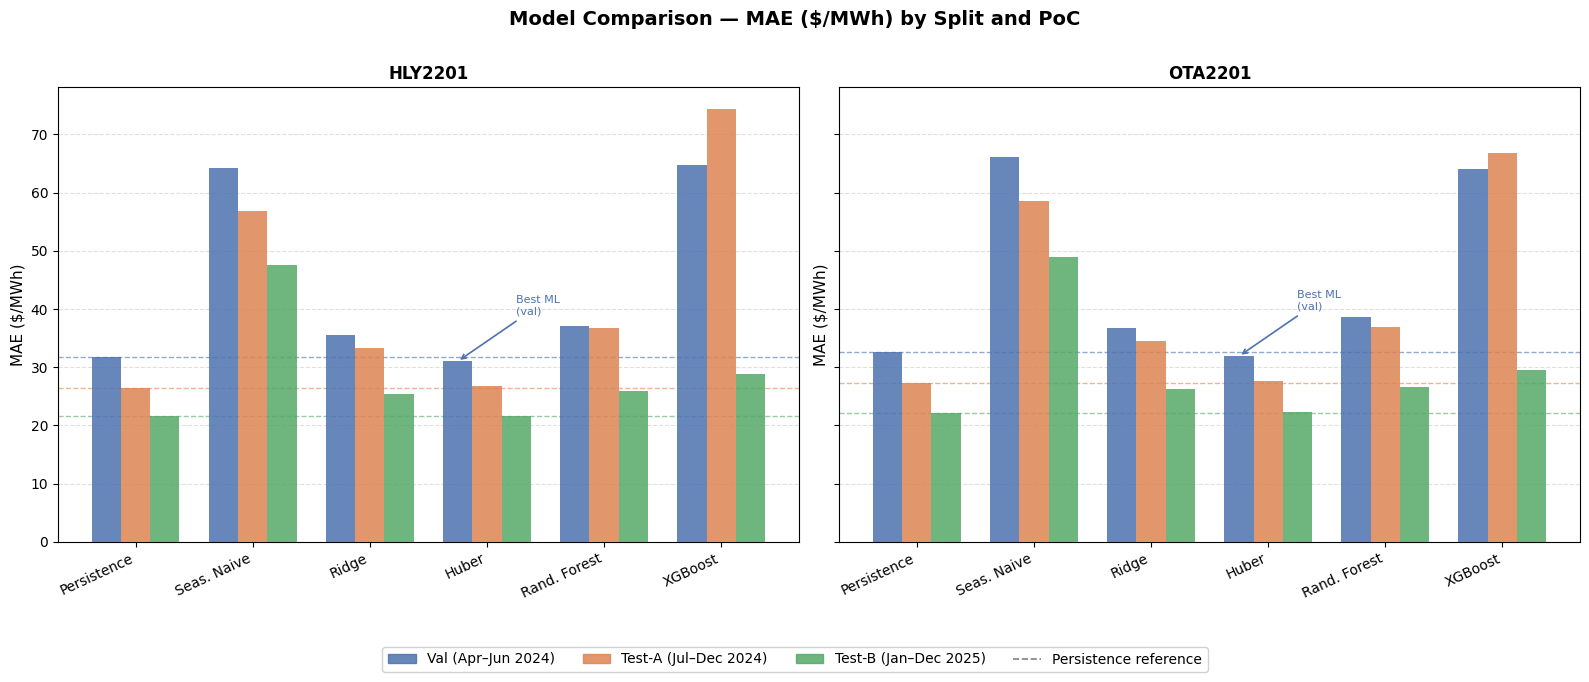

Saved: plot1_model_comparison_mae.png


In [ ]:
# Plot 1 — Model Comparison Bar Chart (MAE across splits)

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

MODEL_LABELS = {
    'Persistence':   'Persistence',
    'Seasonal Naive':'Seas. Naive',
    'Ridge':         'Ridge',
    'Huber':         'Huber',
    'RandomForest':  'Rand. Forest',
    'XGBoost':       'XGBoost',
}
PLOT_MODELS  = list(MODEL_LABELS.keys())
PLOT_SPLITS  = ['val', 'test_a', 'test_b']
SPLIT_LABELS = {'val': 'Val (Apr–Jun 2024)', 'test_a': 'Test-A (Jul–Dec 2024)', 'test_b': 'Test-B (Jan–Dec 2025)'}
COLORS       = {'val': '#4C72B0', 'test_a': '#DD8452', 'test_b': '#55A868'}

x      = np.arange(len(PLOT_MODELS))
width  = 0.25
offsets = [-width, 0, width]

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
fig.suptitle('Model Comparison — MAE ($/MWh) by Split and PoC', fontsize=14, fontweight='bold', y=1.01)

for ax, poc in zip(axes, TARGET_POCS):
    for i, (split, offset) in enumerate(zip(PLOT_SPLITS, offsets)):
        maes = [results[poc][m][split]['MAE'] for m in PLOT_MODELS]
        bars = ax.bar(x + offset, maes, width=width,
                      color=COLORS[split], alpha=0.85,
                      label=SPLIT_LABELS[split], zorder=3)

    # Dashed reference lines at Persistence MAE per split
    for split, color in COLORS.items():
        pers_mae = results[poc]['Persistence'][split]['MAE']
        ax.axhline(pers_mae, color=color, linestyle='--',
                   linewidth=1.0, alpha=0.6, zorder=2)

    ax.set_title(poc, fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([MODEL_LABELS[m] for m in PLOT_MODELS],
                       rotation=25, ha='right', fontsize=10)
    ax.set_ylabel('MAE ($/MWh)', fontsize=11)
    ax.set_ylim(0, None)
    ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
    ax.set_axisbelow(True)

    # Annotate Huber bar (best ML model) on val split
    huber_idx = PLOT_MODELS.index('Huber')
    huber_val_mae = results[poc]['Huber']['val']['MAE']
    ax.annotate('Best ML\n(val)', xy=(huber_idx - width, huber_val_mae),
                xytext=(huber_idx - width + 0.5, huber_val_mae + 8),
                fontsize=8, color='#4C72B0',
                arrowprops=dict(arrowstyle='->', color='#4C72B0', lw=1.2))

# Shared legend
handles = [mpatches.Patch(color=COLORS[s], alpha=0.85, label=SPLIT_LABELS[s])
           for s in PLOT_SPLITS]
handles.append(plt.Line2D([0],[0], color='gray', linestyle='--',
                           linewidth=1.2, label='Persistence reference'))
fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, -0.04),
           ncol=4, fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.savefig('./data/plot1_model_comparison_mae.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plot1_model_comparison_mae.png")


### Plot 2 — Hyperparameter Tuning Curves

Shows how validation MAE responds to the key hyperparameter for each model family. The selected value (from the primary experiment) is marked with a vertical dashed line. Both PoCs are overlaid — near-identical lines confirm the nodes behave consistently.

- **Ridge**: val MAE vs regularisation strength (alpha), log scale
- **Huber**: val MAE vs transition point (epsilon), fixed alpha = 0.0001
- **Random Forest**: val MAE vs number of trees (n_estimators), other params fixed at best
- **XGBoost**: val MAE vs number of trees (n_estimators), other params fixed at best


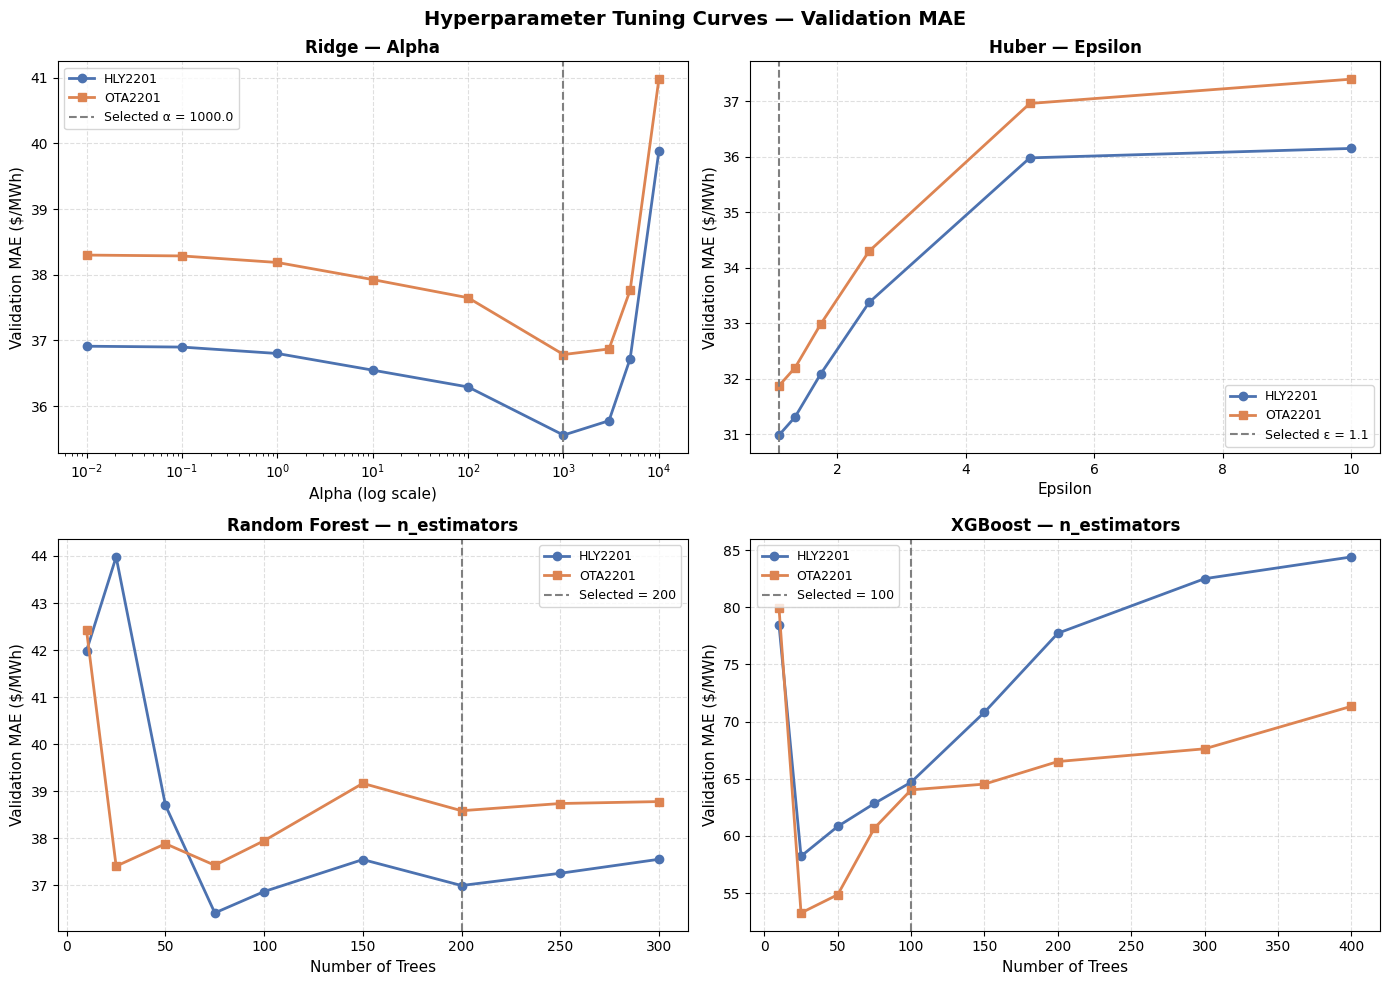

Saved: plot2_tuning_curves.png


In [ ]:
# Plot 2 — Hyperparameter Tuning Curves
# Re-evaluates each model over its key hyperparameter range.
# Other hyperparameters fixed at the best found in primary
# experiment. Both PoCs overlaid per subplot.

import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import Ridge, HuberRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

POC_COLORS  = {'HLY2201': '#4C72B0', 'OTA2201': '#DD8452'}
POC_MARKERS = {'HLY2201': 'o', 'OTA2201': 's'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Hyperparameter Tuning Curves — Validation MAE', fontsize=14, fontweight='bold')

# Ridge: alpha vs val MAE 
ax = axes[0, 0]
alphas = [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0, 3000.0, 5000.0, 10000.0]
for poc in TARGET_POCS:
    sc = ridge_scalers[poc]
    Xtr = sc.transform(splits[poc]['train'][FEATURE_COLS].values)
    ytr = splits[poc]['train']['y'].values
    Xv  = sc.transform(splits[poc]['val'][FEATURE_COLS].values)
    yv  = splits[poc]['val']['y'].values
    maes = [mean_absolute_error(yv, Ridge(alpha=a).fit(Xtr, ytr).predict(Xv))
            for a in alphas]
    ax.plot(alphas, maes, marker=POC_MARKERS[poc], color=POC_COLORS[poc],
            label=poc, linewidth=2, markersize=6)

best_alpha = ridge_models[TARGET_POCS[0]].alpha
ax.axvline(best_alpha, color='gray', linestyle='--', linewidth=1.5,
           label=f'Selected α = {best_alpha}')
ax.set_xscale('log')
ax.set_xlabel('Alpha (log scale)', fontsize=11)
ax.set_ylabel('Validation MAE ($/MWh)', fontsize=11)
ax.set_title('Ridge — Alpha', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)

# Huber: epsilon vs val MAE 
ax = axes[0, 1]
epsilons = [1.1, 1.35, 1.75, 2.5, 5.0, 10.0]
for poc in TARGET_POCS:
    sc = ridge_scalers[poc]
    Xtr = sc.transform(splits[poc]['train'][FEATURE_COLS].values)
    ytr = splits[poc]['train']['y'].values
    Xv  = sc.transform(splits[poc]['val'][FEATURE_COLS].values)
    yv  = splits[poc]['val']['y'].values
    maes = [mean_absolute_error(yv,
            HuberRegressor(epsilon=e, alpha=0.0001, max_iter=300)
            .fit(Xtr, ytr).predict(Xv))
            for e in epsilons]
    ax.plot(epsilons, maes, marker=POC_MARKERS[poc], color=POC_COLORS[poc],
            label=poc, linewidth=2, markersize=6)

best_eps = huber_models[TARGET_POCS[0]].epsilon
ax.axvline(best_eps, color='gray', linestyle='--', linewidth=1.5,
           label=f'Selected ε = {best_eps}')
ax.set_xlabel('Epsilon', fontsize=11)
ax.set_ylabel('Validation MAE ($/MWh)', fontsize=11)
ax.set_title('Huber — Epsilon', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)

# Random Forest: n_estimators vs val MAE 
ax = axes[1, 0]
n_trees = [10, 25, 50, 75, 100, 150, 200, 250, 300]
for poc in TARGET_POCS:
    p    = rf_models[poc].get_params()
    best = {k: p[k] for k in ['max_depth','min_samples_leaf','max_features',
                                'n_jobs','random_state']}
    Xtr  = splits[poc]['train'][FEATURE_COLS].values
    ytr  = splits[poc]['train']['y'].values
    Xv   = splits[poc]['val'][FEATURE_COLS].values
    yv   = splits[poc]['val']['y'].values
    maes = [mean_absolute_error(yv,
            RandomForestRegressor(n_estimators=n, **best)
            .fit(Xtr, ytr).predict(Xv))
            for n in n_trees]
    ax.plot(n_trees, maes, marker=POC_MARKERS[poc], color=POC_COLORS[poc],
            label=poc, linewidth=2, markersize=6)

ax.axvline(200, color='gray', linestyle='--', linewidth=1.5, label='Selected = 200')
ax.set_xlabel('Number of Trees', fontsize=11)
ax.set_ylabel('Validation MAE ($/MWh)', fontsize=11)
ax.set_title('Random Forest — n_estimators', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)

# XGBoost: n_estimators vs val MAE 
ax = axes[1, 1]
n_boost = [10, 25, 50, 75, 100, 150, 200, 300, 400]
for poc in TARGET_POCS:
    p    = xgb_models[poc].get_params()
    best = {k: p[k] for k in ['max_depth','learning_rate','min_child_weight',
                                'subsample','colsample_bytree','random_state','verbosity']}
    Xtr  = splits[poc]['train'][FEATURE_COLS].values
    ytr  = splits[poc]['train']['y'].values
    Xv   = splits[poc]['val'][FEATURE_COLS].values
    yv   = splits[poc]['val']['y'].values
    maes = [mean_absolute_error(yv,
            XGBRegressor(n_estimators=n, device=XGB_DEVICE, **best)
            .fit(Xtr, ytr).predict(Xv))
            for n in n_boost]
    ax.plot(n_boost, maes, marker=POC_MARKERS[poc], color=POC_COLORS[poc],
            label=poc, linewidth=2, markersize=6)

best_n = xgb_models[TARGET_POCS[0]].n_estimators
ax.axvline(best_n, color='gray', linestyle='--', linewidth=1.5,
           label=f'Selected = {best_n}')
ax.set_xlabel('Number of Trees', fontsize=11)
ax.set_ylabel('Validation MAE ($/MWh)', fontsize=11)
ax.set_title('XGBoost — n_estimators', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('./data/plot2_tuning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plot2_tuning_curves.png")


### Plot 3 — Best Model: Predicted vs Actual (Huber Regression)

Two representative 3-week windows for each test split and PoC:
- **Test-A window**: September 2024 — chosen because it contains the largest spike event in the test period (Sep 17, ~$6,500/MWh)
- **Test-B window**: April 2025 — representative of the calmer hydro-recovery regime

The red shaded region marks prices ≥ $300/MWh. The dashed line is the spike threshold.


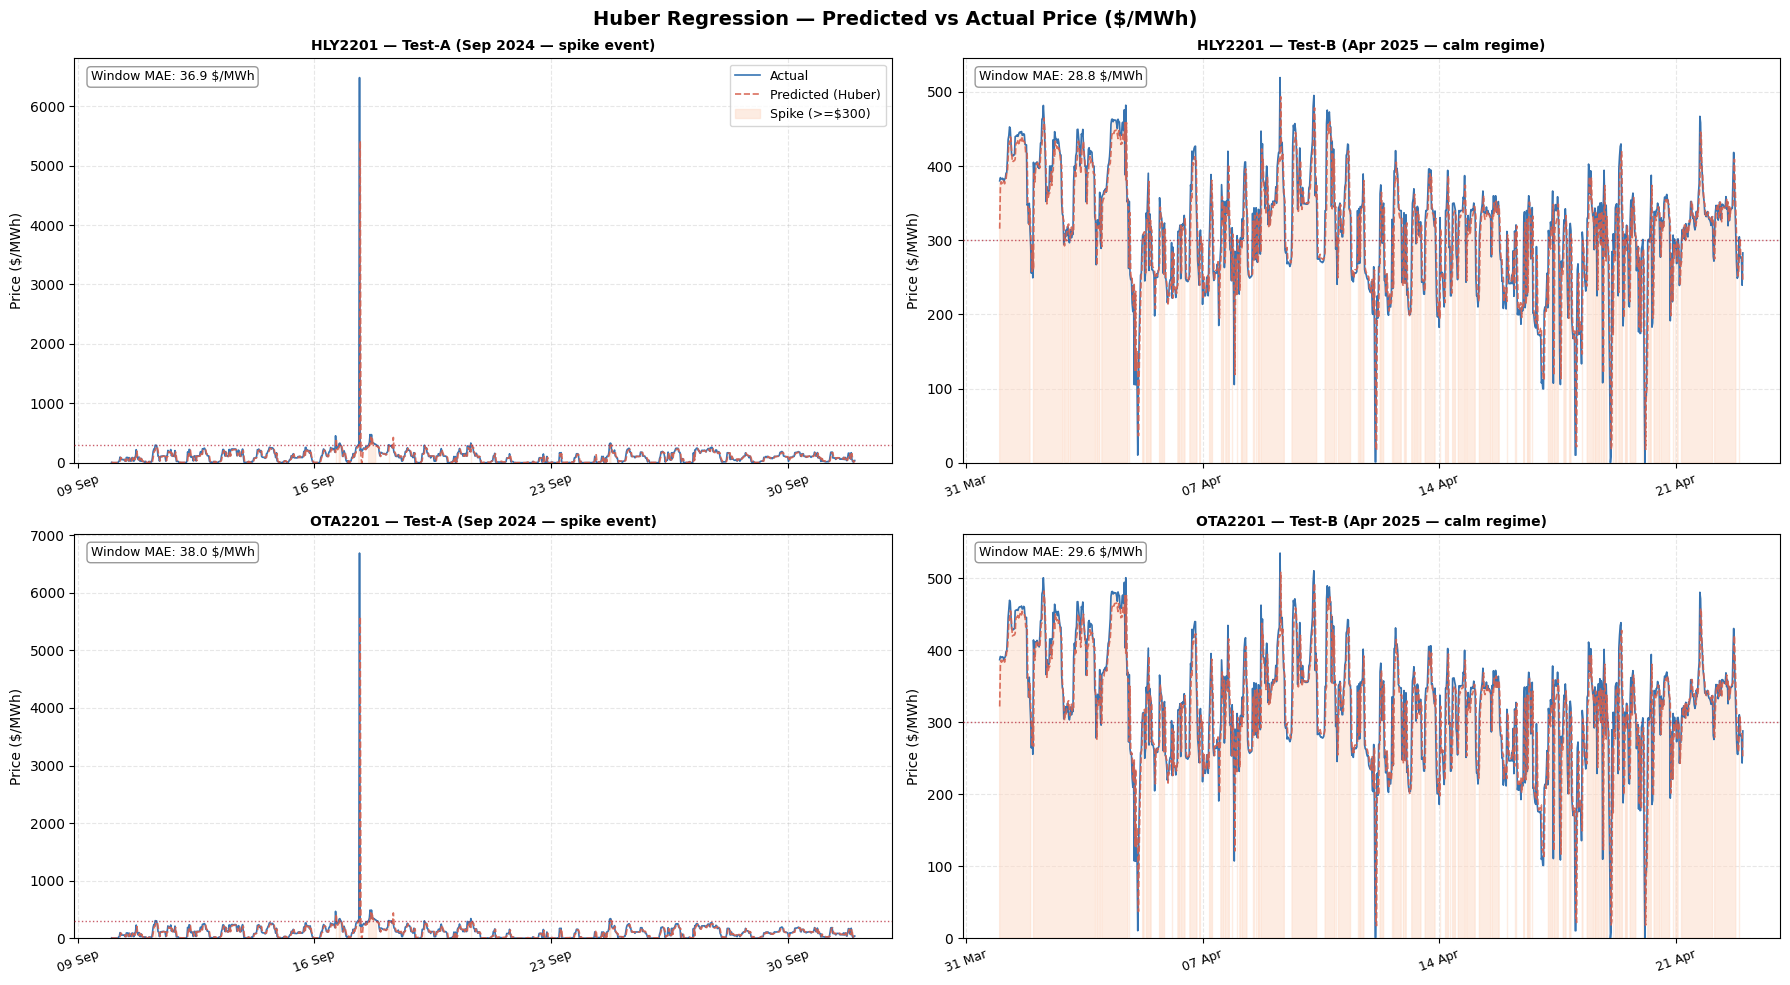

Saved: plot3_predicted_vs_actual.png


In [ ]:
# ============================================================
# Plot 3 — Huber: Predicted vs Actual Time Series
# Two representative 3-week windows per PoC:
#   Test-A: Sep 2024 (major spike event)
#   Test-B: Apr 2025 (calm hydro-recovery regime)

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

WINDOWS = {
    'Test-A (Sep 2024 — spike event)': ('2024-09-10', '2024-10-01'),
    'Test-B (Apr 2025 — calm regime)': ('2025-04-01', '2025-04-22'),
}
SPIKE_THRESH = 300

fig, axes = plt.subplots(2, 2, figsize=(18, 10), sharey=False)
fig.suptitle('Huber Regression — Predicted vs Actual Price ($/MWh)',
             fontsize=14, fontweight='bold')

for row, poc in enumerate(TARGET_POCS):
    sc = ridge_scalers[poc]

    for col, (win_label, (win_start, win_end)) in enumerate(WINDOWS.items()):
        ax = axes[row, col]

        split_df = (splits[poc]['test_a']
                    if '2024' in win_start else splits[poc]['test_b'])

        window = split_df.loc[win_start:win_end]
        y_true = window['y'].values
        y_pred = huber_models[poc].predict(
            sc.transform(window[FEATURE_COLS].values))

        idx   = window.index
        mae_w = mean_absolute_error(y_true, y_pred)

        ax.plot(idx, y_true, color='#2166AC', linewidth=1.2,
                label='Actual', alpha=0.9, zorder=3)
        ax.plot(idx, y_pred, color='#D6604D', linewidth=1.2,
                linestyle='--', label='Predicted (Huber)', alpha=0.9, zorder=3)

        spike_mask = y_true >= SPIKE_THRESH
        if spike_mask.any():
            ax.fill_between(idx, 0, y_true,
                            where=spike_mask,
                            color='#FDDBC7', alpha=0.5,
                            label='Spike (>=$300)', zorder=2)

        ax.axhline(SPIKE_THRESH, color='#B2182B', linestyle=':',
                   linewidth=1.0, alpha=0.7, zorder=4)

        ax.set_title(poc + ' — ' + win_label, fontsize=10, fontweight='bold')
        ax.set_ylabel('Price ($/MWh)', fontsize=10)
        ax.text(0.02, 0.97, 'Window MAE: ' + str(round(mae_w, 1)) + ' $/MWh',
                transform=ax.transAxes, fontsize=9,
                verticalalignment='top',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                          alpha=0.8, edgecolor='gray'))

        ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
        ax.tick_params(axis='x', rotation=20, labelsize=9)
        ax.grid(True, linestyle='--', alpha=0.3)
        ax.set_ylim(bottom=0)

        if row == 0 and col == 0:
            ax.legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig('./data/plot3_predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plot3_predicted_vs_actual.png")


In [ ]:
# ============================================================
# Plot 3a — Huber: Full Test-A and Test-B Time Series
# ------------------------------------------------------------
# Test-A : Jul 2024 – Dec 2024  (gas-crisis / spike regime)
# Test-B : Jan 2025 – Dec 2025  (hydro-recovery / calmer)
# 2×2 grid: rows = PoC, cols = split
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import numpy as np
from sklearn.metrics import mean_absolute_error

SPIKE_THRESH = 300

SPLITS_INFO = [
    ('test_a', 'Test-A  Jul – Dec 2024  (spike regime)'),
    ('test_b', 'Test-B  Jan – Dec 2025  (hydro-recovery)'),
]

fig, axes = plt.subplots(2, 2, figsize=(22, 10), sharey=False)
fig.suptitle(
    'Huber Regression — Predicted vs Actual: Full Test Periods',
    fontsize=14, fontweight='bold')

for row, poc in enumerate(TARGET_POCS):
    sc = ridge_scalers[poc]

    for col, (split_key, split_title) in enumerate(SPLITS_INFO):
        ax  = axes[row, col]
        df  = splits[poc][split_key]
        idx = df.index

        y_true = df['y'].values
        y_pred = huber_models[poc].predict(
            sc.transform(df[FEATURE_COLS].values))

        mae_full = mean_absolute_error(y_true, y_pred)

        # Actual and predicted lines
        ax.plot(idx, y_true, color='#2166AC', linewidth=0.7,
                label='Actual', alpha=0.85, zorder=3)
        ax.plot(idx, y_pred, color='#D6604D', linewidth=0.7,
                linestyle='--', label='Predicted (Huber)', alpha=0.85, zorder=3)

        # Spike shading
        spike_mask = y_true >= SPIKE_THRESH
        if spike_mask.any():
            ax.fill_between(idx, 0, y_true,
                            where=spike_mask,
                            color='#FDDBC7', alpha=0.45,
                            label='Spike region (≥$300)', zorder=2)

        ax.axhline(SPIKE_THRESH, color='#B2182B', linestyle=':',
                   linewidth=0.9, alpha=0.6, zorder=4)

        # Titles and labels
        ax.set_title(poc + '  —  ' + split_title, fontsize=10, fontweight='bold')
        ax.set_ylabel('Price ($/MWh)', fontsize=9)

        ax.text(0.01, 0.98,
                'MAE: $' + str(round(mae_full, 1)) + '/MWh',
                transform=ax.transAxes, fontsize=9,
                va='top', ha='left',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                          alpha=0.85, edgecolor='gray'))

        # X-axis: monthly ticks
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
        ax.tick_params(axis='x', rotation=30, labelsize=8)
        ax.set_ylim(bottom=0)
        ax.grid(True, linestyle='--', alpha=0.25)

        if row == 0 and col == 0:
            ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig('./data/plot3a_full_test_series.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot3a_full_test_series.png')


In [ ]:
# ============================================================
# Plot 3b — Persistence: Full Test-A and Test-B Time Series
# ------------------------------------------------------------
# Persistence baseline: ŷ = price from 30 min ago (lag_1)
# Test-A : Jul 2024 – Dec 2024  (gas-crisis / spike regime)
# Test-B : Jan 2025 – Dec 2025  (hydro-recovery / calmer)
# 2x2 grid: rows = PoC, cols = split
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from sklearn.metrics import mean_absolute_error

SPIKE_THRESH = 300

SPLITS_INFO = [
    ('test_a', 'Test-A  Jul – Dec 2024  (spike regime)'),
    ('test_b', 'Test-B  Jan – Dec 2025  (hydro-recovery)'),
]

fig, axes = plt.subplots(2, 2, figsize=(22, 10), sharey=False)
fig.suptitle(
    'Persistence Baseline — Predicted vs Actual: Full Test Periods',
    fontsize=14, fontweight='bold')

for row, poc in enumerate(TARGET_POCS):
    for col, (split_key, split_title) in enumerate(SPLITS_INFO):
        ax  = axes[row, col]
        df  = splits[poc][split_key]
        idx = df.index

        y_true = df['y'].values
        y_pred = df['lag_1'].values

        mae_full = mean_absolute_error(y_true, y_pred)

        ax.plot(idx, y_true, color='#2166AC', linewidth=0.7,
                label='Actual', alpha=0.85, zorder=3)
        ax.plot(idx, y_pred, color='#F4A582', linewidth=0.7,
                linestyle='--', label='Predicted (Persistence)', alpha=0.85, zorder=3)

        spike_mask = y_true >= SPIKE_THRESH
        if spike_mask.any():
            ax.fill_between(idx, 0, y_true,
                            where=spike_mask,
                            color='#FDDBC7', alpha=0.45,
                            label='Spike region (>=$300)', zorder=2)

        ax.axhline(SPIKE_THRESH, color='#B2182B', linestyle=':',
                   linewidth=0.9, alpha=0.6, zorder=4)

        ax.set_title(poc + '  —  ' + split_title, fontsize=10, fontweight='bold')
        ax.set_ylabel('Price ($/MWh)', fontsize=9)

        ax.text(0.01, 0.98,
                'MAE: $' + str(round(mae_full, 1)) + '/MWh',
                transform=ax.transAxes, fontsize=9,
                va='top', ha='left',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                          alpha=0.85, edgecolor='gray'))

        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
        ax.tick_params(axis='x', rotation=30, labelsize=8)
        ax.set_ylim(bottom=0)
        ax.grid(True, linestyle='--', alpha=0.25)

        if row == 0 and col == 0:
            ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig('./data/plot3b_persistence_full_test.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot3b_persistence_full_test.png')


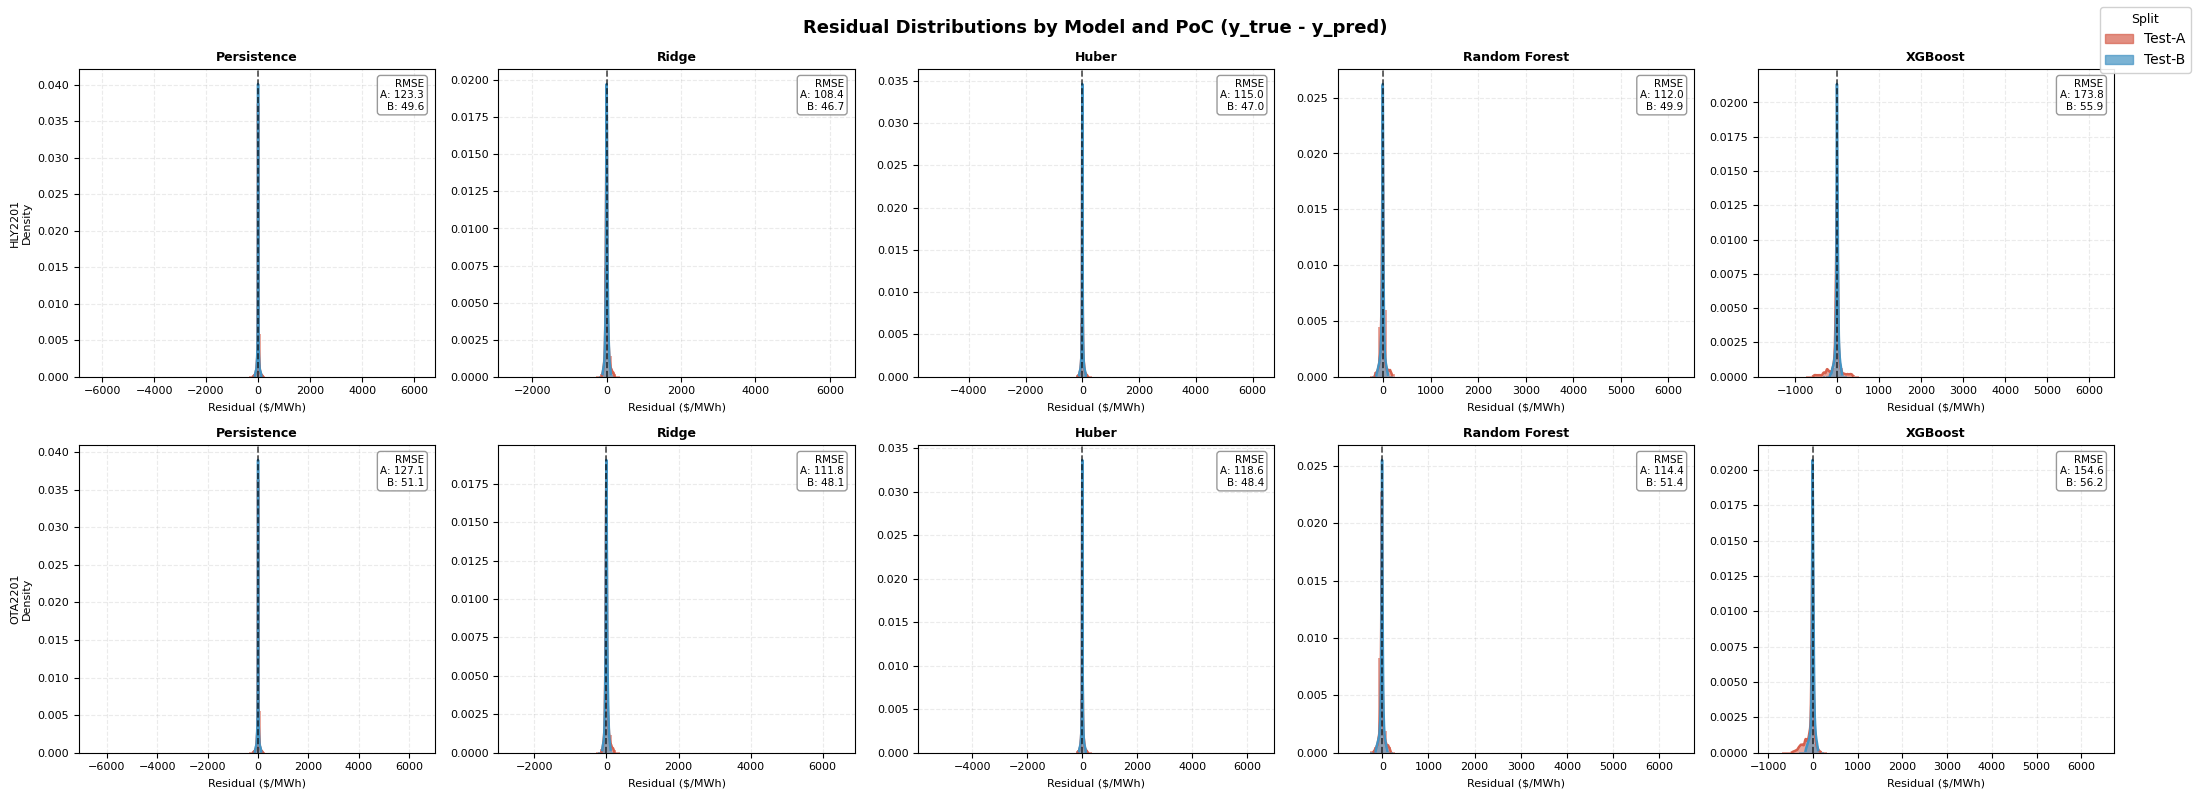

Saved: plot4_residual_distributions.png


In [ ]:

# Plot 4 — Residual Distributions for All Models

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from scipy.stats import gaussian_kde

MODELS = ['Persistence', 'Ridge', 'Huber', 'Random Forest', 'XGBoost']
COLORS = {'Test-A': '#D6604D', 'Test-B': '#4393C3'}

def get_residuals(poc, split_df):
    y_true = split_df['y'].values
    sc     = ridge_scalers[poc]
    Xs     = sc.transform(split_df[FEATURE_COLS].values)
    Xr     = split_df[FEATURE_COLS].values

    return {
        'Persistence':    y_true - split_df['lag_1'].values,
        'Ridge':          y_true - ridge_models[poc].predict(Xs),
        'Huber':          y_true - huber_models[poc].predict(Xs),
        'Random Forest':  y_true - rf_models[poc].predict(Xr),
        'XGBoost':        y_true - xgb_models[poc].predict(Xr),
    }

fig, axes = plt.subplots(2, 5, figsize=(22, 8), sharey=False)
fig.suptitle('Residual Distributions by Model and PoC (y_true - y_pred)',
             fontsize=13, fontweight='bold')

for row, poc in enumerate(TARGET_POCS):
    resid_a = get_residuals(poc, splits[poc]['test_a'])
    resid_b = get_residuals(poc, splits[poc]['test_b'])

    for col, model in enumerate(MODELS):
        ax = axes[row, col]

        for split_name, resid_dict, alpha in [
            ('Test-A', resid_a, 0.55),
            ('Test-B', resid_b, 0.55),
        ]:
            r = resid_dict[model]
            color = COLORS[split_name]

            ax.hist(r, bins=80, density=True, color=color,
                    alpha=alpha, edgecolor='none')

            # KDE overlay
            clip = np.percentile(r, [1, 99])
            r_clip = r[(r >= clip[0]) & (r <= clip[1])]
            if len(r_clip) > 10:
                kde_x = np.linspace(r_clip.min(), r_clip.max(), 400)
                kde   = gaussian_kde(r_clip, bw_method=0.15)
                ax.plot(kde_x, kde(kde_x), color=color, linewidth=1.8)

        ax.axvline(0, color='black', linewidth=1.2, linestyle='--', alpha=0.7)

        rmse_a = round(float(np.sqrt(np.mean(resid_a[model]**2))), 1)
        rmse_b = round(float(np.sqrt(np.mean(resid_b[model]**2))), 1)
        ax.set_title(model, fontsize=9, fontweight='bold')
        ax.set_xlabel('Residual ($/MWh)', fontsize=8)
        if col == 0:
            ax.set_ylabel(poc + '\nDensity', fontsize=8)
        ax.text(0.97, 0.97,
                'RMSE\nA: ' + str(rmse_a) + '\nB: ' + str(rmse_b),
                transform=ax.transAxes, fontsize=7.5,
                ha='right', va='top',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                          alpha=0.8, edgecolor='gray'))
        ax.tick_params(labelsize=8)
        ax.grid(True, linestyle='--', alpha=0.25)

# Legend
patches = [mpatches.Patch(color=COLORS[s], alpha=0.7, label=s)
           for s in ['Test-A', 'Test-B']]
fig.legend(handles=patches, loc='upper right', fontsize=10,
           title='Split', title_fontsize=9, framealpha=0.9)

plt.tight_layout(rect=[0, 0, 0.97, 1])
plt.savefig('./data/plot4_residual_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plot4_residual_distributions.png")


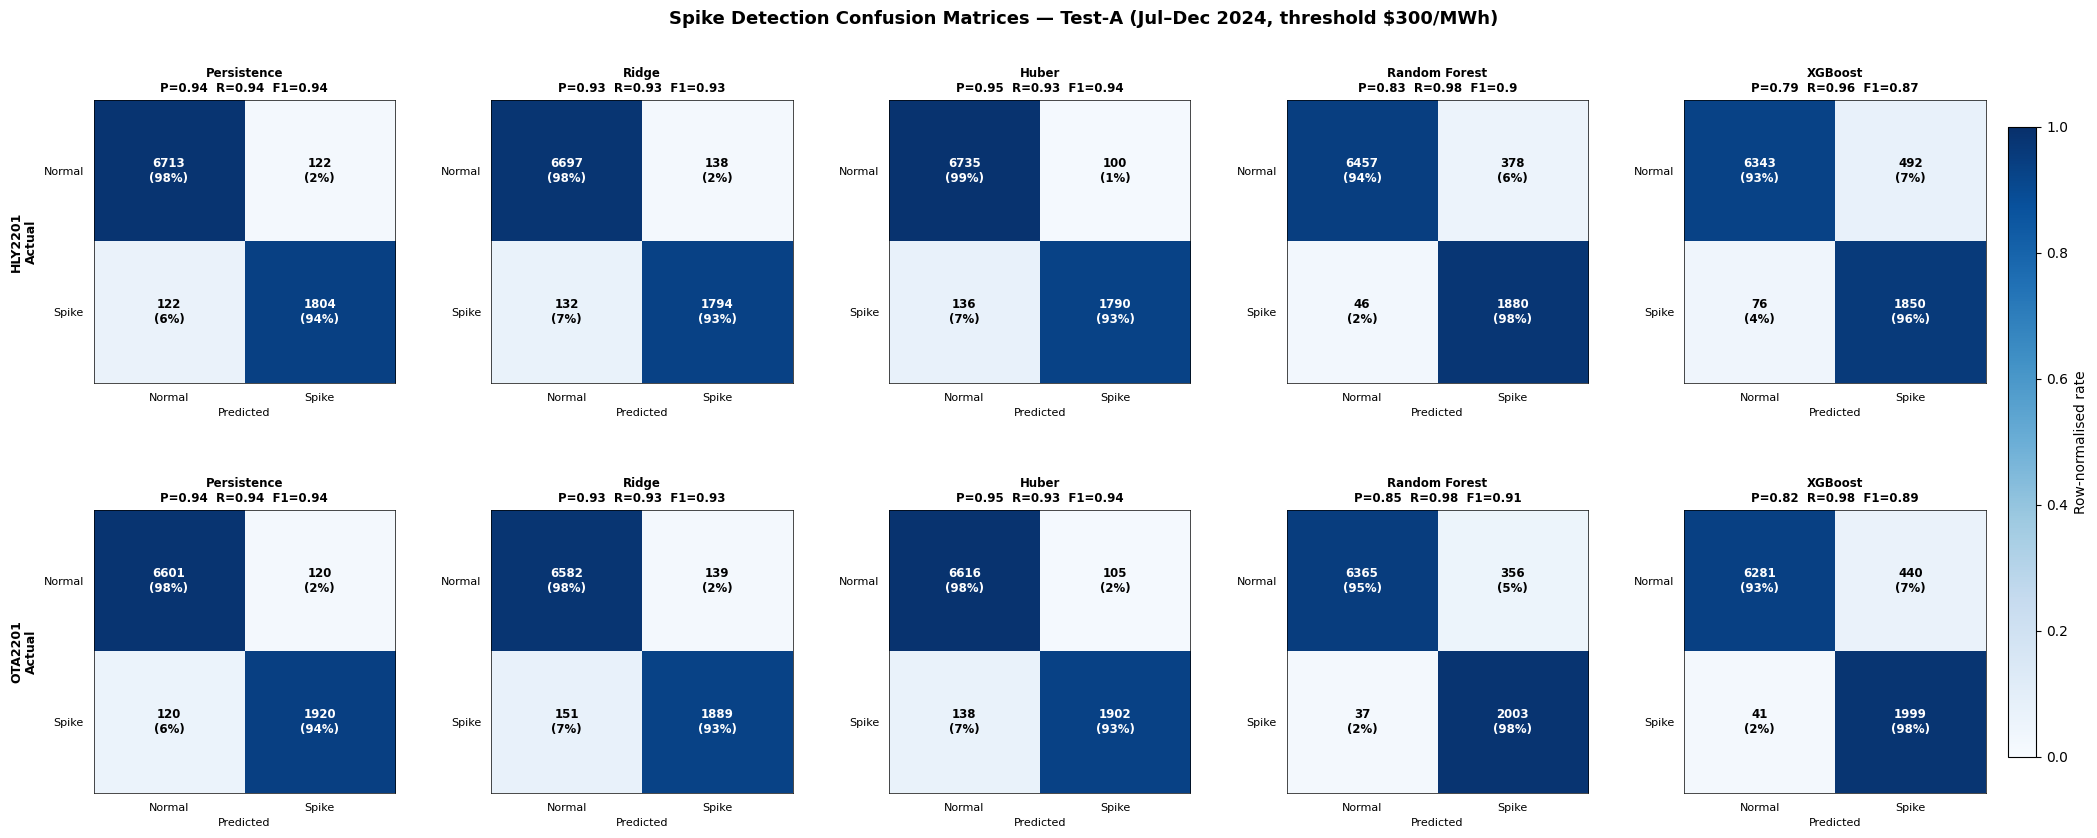

Saved: plot5_confusion_matrices.png

Spike class balance (Test-A):
  HLY2201: 1926 spike periods / 8761 total (22.0%)
  OTA2201: 2040 spike periods / 8761 total (23.3%)


In [ ]:

# Plot 5 — Spike Detection Confusion Matrices
# Treat predicted price >= $300/MWh as a "spike forecast"
# Evaluate on Test-A (Jul–Dec 2024, high-spike period) only.

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from sklearn.metrics import (confusion_matrix,
                              precision_score, recall_score, f1_score)

SPIKE_THRESH = 300
MODELS = ['Persistence', 'Ridge', 'Huber', 'Random Forest', 'XGBoost']

def get_preds_testa(poc):
    df = splits[poc]['test_a']
    sc = ridge_scalers[poc]
    Xs = sc.transform(df[FEATURE_COLS].values)
    Xr = df[FEATURE_COLS].values
    return df['y'].values, {
        'Persistence':   df['lag_1'].values,
        'Ridge':         ridge_models[poc].predict(Xs),
        'Huber':         huber_models[poc].predict(Xs),
        'Random Forest': rf_models[poc].predict(Xr),
        'XGBoost':       xgb_models[poc].predict(Xr),
    }

fig, axes = plt.subplots(2, 5, figsize=(22, 9))
fig.suptitle(
    'Spike Detection Confusion Matrices — Test-A (Jul–Dec 2024, threshold \$300/MWh)',
    fontsize=13, fontweight='bold')

CMAP = plt.cm.Blues

for row, poc in enumerate(TARGET_POCS):
    y_true, preds = get_preds_testa(poc)
    true_lbl = (y_true >= SPIKE_THRESH).astype(int)
    n_spikes  = true_lbl.sum()
    n_normal  = len(true_lbl) - n_spikes

    for col, model in enumerate(MODELS):
        ax = axes[row, col]
        pred_lbl = (preds[model] >= SPIKE_THRESH).astype(int)

        cm      = confusion_matrix(true_lbl, pred_lbl, labels=[0, 1])
        row_sum = cm.sum(axis=1, keepdims=True).clip(min=1)
        cm_norm = cm / row_sum          # row-normalised recall view

        im = ax.imshow(cm_norm, cmap=CMAP, vmin=0, vmax=1,
                       aspect='auto')

        tick_labels = ['Normal', 'Spike']
        for i in range(2):
            for j in range(2):
                val   = cm[i, j]
                pct   = cm_norm[i, j]
                color = 'white' if pct > 0.6 else 'black'
                ax.text(j, i,
                        str(val) + '\n(' + str(round(pct * 100)) + '%)',
                        ha='center', va='center',
                        fontsize=8.5, color=color, fontweight='bold')

        prec = precision_score(true_lbl, pred_lbl, zero_division=0)
        rec  = recall_score(true_lbl, pred_lbl, zero_division=0)
        f1   = f1_score(true_lbl, pred_lbl, zero_division=0)

        ax.set_xticks([0, 1]); ax.set_xticklabels(tick_labels, fontsize=8)
        ax.set_yticks([0, 1]); ax.set_yticklabels(tick_labels, fontsize=8)
        ax.set_xlabel('Predicted', fontsize=8)
        if col == 0:
            ax.set_ylabel(poc + '\nActual', fontsize=9, fontweight='bold')

        title_line = (model + '\nP=' + str(round(prec, 2)) +
                      '  R=' + str(round(rec, 2)) +
                      '  F1=' + str(round(f1, 2)))
        ax.set_title(title_line, fontsize=8.5, fontweight='bold')

        ax.tick_params(left=False, bottom=False)
        for spine in ax.spines.values():
            spine.set_linewidth(0.5)

# Shared colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.013, 0.7])
sm = plt.cm.ScalarMappable(cmap=CMAP, norm=mcolors.Normalize(0, 1))
sm.set_array([])
fig.colorbar(sm, cax=cbar_ax, label='Row-normalised rate')

plt.subplots_adjust(left=0.05, right=0.91, hspace=0.45, wspace=0.32)
plt.savefig('./data/plot5_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot5_confusion_matrices.png')
print()
print('Spike class balance (Test-A):')
for poc in TARGET_POCS:
    y = splits[poc]['test_a']['y'].values
    n = (y >= SPIKE_THRESH).sum()
    print('  ' + poc + ': ' + str(n) + ' spike periods / ' + str(len(y)) +
          ' total (' + str(round(100*n/len(y), 1)) + '%)')


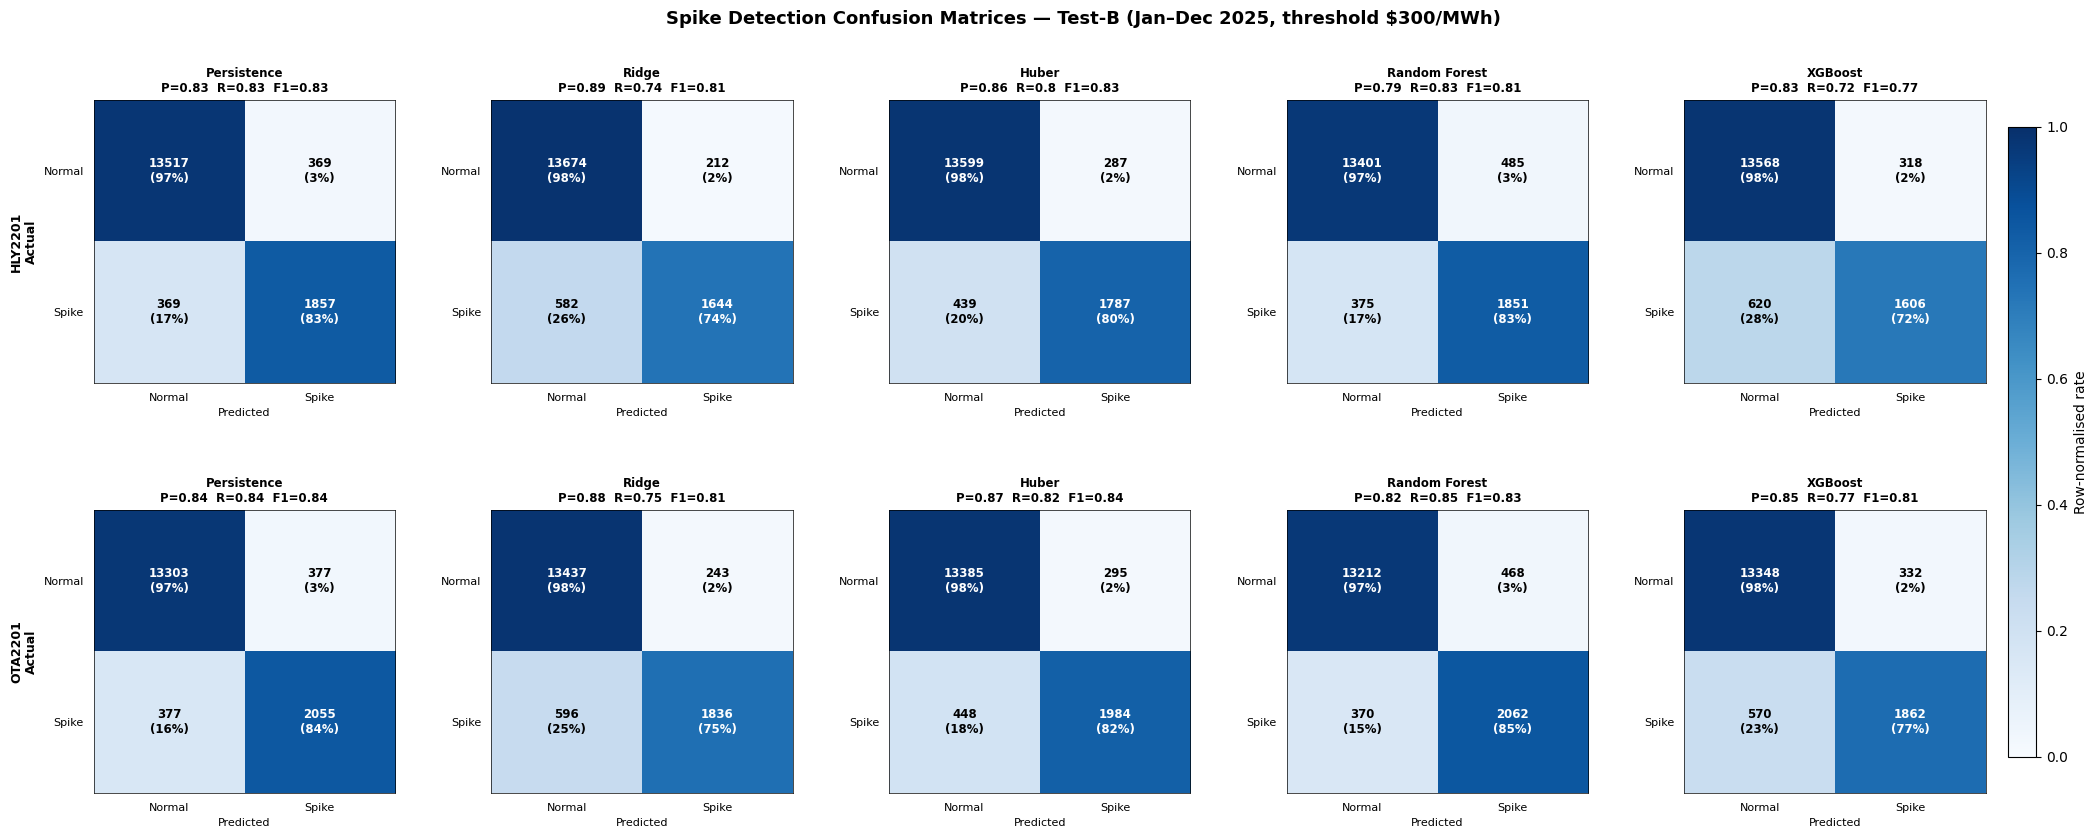

Saved: plot5b_confusion_matrices_testb.png

Spike class balance (Test-B):
  HLY2201: 2226 spike periods / 16112 total (13.8%)
  OTA2201: 2432 spike periods / 16112 total (15.1%)


In [ ]:
# Plot 5b — Spike Detection Confusion Matrices (Test-B) which is out of regime

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from sklearn.metrics import (confusion_matrix,
                              precision_score, recall_score, f1_score)

SPIKE_THRESH = 300
MODELS = ['Persistence', 'Ridge', 'Huber', 'Random Forest', 'XGBoost']

def get_preds_testb(poc):
    df = splits[poc]['test_b']
    sc = ridge_scalers[poc]
    Xs = sc.transform(df[FEATURE_COLS].values)
    Xr = df[FEATURE_COLS].values
    return df['y'].values, {
        'Persistence':   df['lag_1'].values,
        'Ridge':         ridge_models[poc].predict(Xs),
        'Huber':         huber_models[poc].predict(Xs),
        'Random Forest': rf_models[poc].predict(Xr),
        'XGBoost':       xgb_models[poc].predict(Xr),
    }

fig, axes = plt.subplots(2, 5, figsize=(22, 9))
fig.suptitle(
    'Spike Detection Confusion Matrices — Test-B (Jan–Dec 2025, threshold $300/MWh)',
    fontsize=13, fontweight='bold')

CMAP = plt.cm.Blues

for row, poc in enumerate(TARGET_POCS):
    y_true, preds = get_preds_testb(poc)
    true_lbl = (y_true >= SPIKE_THRESH).astype(int)
    n_spikes = true_lbl.sum()

    for col, model in enumerate(MODELS):
        ax = axes[row, col]
        pred_lbl = (preds[model] >= SPIKE_THRESH).astype(int)

        cm      = confusion_matrix(true_lbl, pred_lbl, labels=[0, 1])
        row_sum = cm.sum(axis=1, keepdims=True).clip(min=1)
        cm_norm = cm / row_sum

        im = ax.imshow(cm_norm, cmap=CMAP, vmin=0, vmax=1, aspect='auto')

        tick_labels = ['Normal', 'Spike']
        for i in range(2):
            for j in range(2):
                val   = cm[i, j]
                pct   = cm_norm[i, j]
                color = 'white' if pct > 0.6 else 'black'
                ax.text(j, i,
                        str(val) + '\n(' + str(round(pct * 100)) + '%)',
                        ha='center', va='center',
                        fontsize=8.5, color=color, fontweight='bold')

        prec = precision_score(true_lbl, pred_lbl, zero_division=0)
        rec  = recall_score(true_lbl, pred_lbl, zero_division=0)
        f1   = f1_score(true_lbl, pred_lbl, zero_division=0)

        ax.set_xticks([0, 1]); ax.set_xticklabels(tick_labels, fontsize=8)
        ax.set_yticks([0, 1]); ax.set_yticklabels(tick_labels, fontsize=8)
        ax.set_xlabel('Predicted', fontsize=8)
        if col == 0:
            ax.set_ylabel(poc + '\nActual', fontsize=9, fontweight='bold')

        title_line = (model + '\nP=' + str(round(prec, 2)) +
                      '  R=' + str(round(rec, 2)) +
                      '  F1=' + str(round(f1, 2)))
        ax.set_title(title_line, fontsize=8.5, fontweight='bold')
        ax.tick_params(left=False, bottom=False)
        for spine in ax.spines.values():
            spine.set_linewidth(0.5)

cbar_ax = fig.add_axes([0.92, 0.15, 0.013, 0.7])
sm = plt.cm.ScalarMappable(cmap=CMAP, norm=mcolors.Normalize(0, 1))
sm.set_array([])
fig.colorbar(sm, cax=cbar_ax, label='Row-normalised rate')

plt.subplots_adjust(left=0.05, right=0.91, hspace=0.45, wspace=0.32)
plt.savefig('./data/plot5b_confusion_matrices_testb.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot5b_confusion_matrices_testb.png')
print()
print('Spike class balance (Test-B):')
for poc in TARGET_POCS:
    y = splits[poc]['test_b']['y'].values
    n = (y >= SPIKE_THRESH).sum()
    print('  ' + poc + ': ' + str(n) + ' spike periods / ' + str(len(y)) +
          ' total (' + str(round(100 * n / len(y), 1)) + '%)')


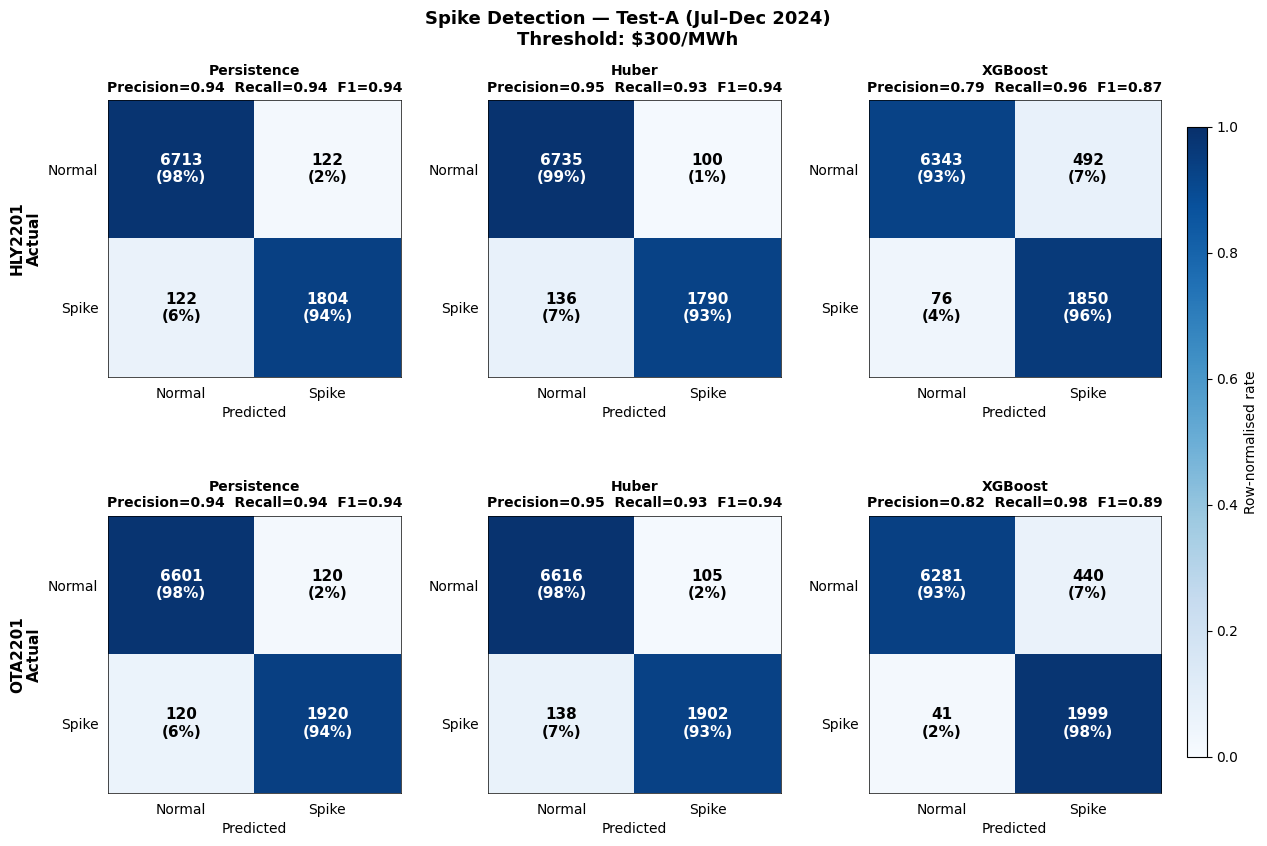

Spike class balance — Test-A:
  HLY2201: 1926 spikes / 8761 total (22.0%)
  OTA2201: 2040 spikes / 8761 total (23.3%)


In [ ]:

# Plot 5c — Spike Confusion Matrices (3 models p[lot for report)

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from sklearn.metrics import (confusion_matrix,
                              precision_score, recall_score, f1_score)

SPIKE_THRESH = 300
MODELS_FOCUS = ['Persistence', 'Huber', 'XGBoost']

fig, axes = plt.subplots(2, 3, figsize=(13, 9))
fig.suptitle(
    'Spike Detection — Test-A (Jul–Dec 2024)\nThreshold: $300/MWh',
    fontsize=13, fontweight='bold')

CMAP = plt.cm.Blues

for row, poc in enumerate(TARGET_POCS):
    df  = splits[poc]['test_a']
    sc  = ridge_scalers[poc]
    Xs  = sc.transform(df[FEATURE_COLS].values)
    Xr  = df[FEATURE_COLS].values
    y_t = (df['y'].values >= SPIKE_THRESH).astype(int)

    preds = {
        'Persistence': df['lag_1'].values,
        'Huber':       huber_models[poc].predict(Xs),
        'XGBoost':     xgb_models[poc].predict(Xr),
    }

    for col, model in enumerate(MODELS_FOCUS):
        ax = axes[row, col]
        pred_lbl = (preds[model] >= SPIKE_THRESH).astype(int)

        cm      = confusion_matrix(y_t, pred_lbl, labels=[0, 1])
        row_sum = cm.sum(axis=1, keepdims=True).clip(min=1)
        cm_norm = cm / row_sum

        ax.imshow(cm_norm, cmap=CMAP, vmin=0, vmax=1, aspect='auto')

        labels = ['Normal', 'Spike']
        for i in range(2):
            for j in range(2):
                val   = cm[i, j]
                pct   = cm_norm[i, j]
                color = 'white' if pct > 0.6 else 'black'
                ax.text(j, i,
                        str(val) + '\n(' + str(round(pct * 100)) + '%)',
                        ha='center', va='center',
                        fontsize=11, color=color, fontweight='bold')

        prec = precision_score(y_t, pred_lbl, zero_division=0)
        rec  = recall_score(y_t, pred_lbl, zero_division=0)
        f1   = f1_score(y_t, pred_lbl, zero_division=0)

        ax.set_xticks([0, 1]); ax.set_xticklabels(labels, fontsize=10)
        ax.set_yticks([0, 1]); ax.set_yticklabels(labels, fontsize=10)
        ax.set_xlabel('Predicted', fontsize=10)
        if col == 0:
            ax.set_ylabel(poc + '\nActual', fontsize=11, fontweight='bold')

        ax.set_title(
            model + '\nPrecision=' + str(round(prec, 2)) +
            '  Recall=' + str(round(rec, 2)) +
            '  F1=' + str(round(f1, 2)),
            fontsize=10, fontweight='bold')

        ax.tick_params(left=False, bottom=False)
        for spine in ax.spines.values():
            spine.set_linewidth(0.5)

# Shared colorbar
cbar_ax = fig.add_axes([0.93, 0.15, 0.015, 0.7])
sm = plt.cm.ScalarMappable(cmap=CMAP, norm=mcolors.Normalize(0, 1))
sm.set_array([])
fig.colorbar(sm, cax=cbar_ax, label='Row-normalised rate')

plt.subplots_adjust(left=0.1, right=0.91, hspace=0.5, wspace=0.3)
plt.savefig('./data/plot5c_confusion_3models_testa.png', dpi=150, bbox_inches='tight')
plt.show()

print('Spike class balance — Test-A:')
for poc in TARGET_POCS:
    y = splits[poc]['test_a']['y'].values
    n = (y >= SPIKE_THRESH).sum()
    print('  ' + poc + ': ' + str(n) + ' spikes / ' + str(len(y)) +
          ' total (' + str(round(100 * n / len(y), 1)) + '%)')


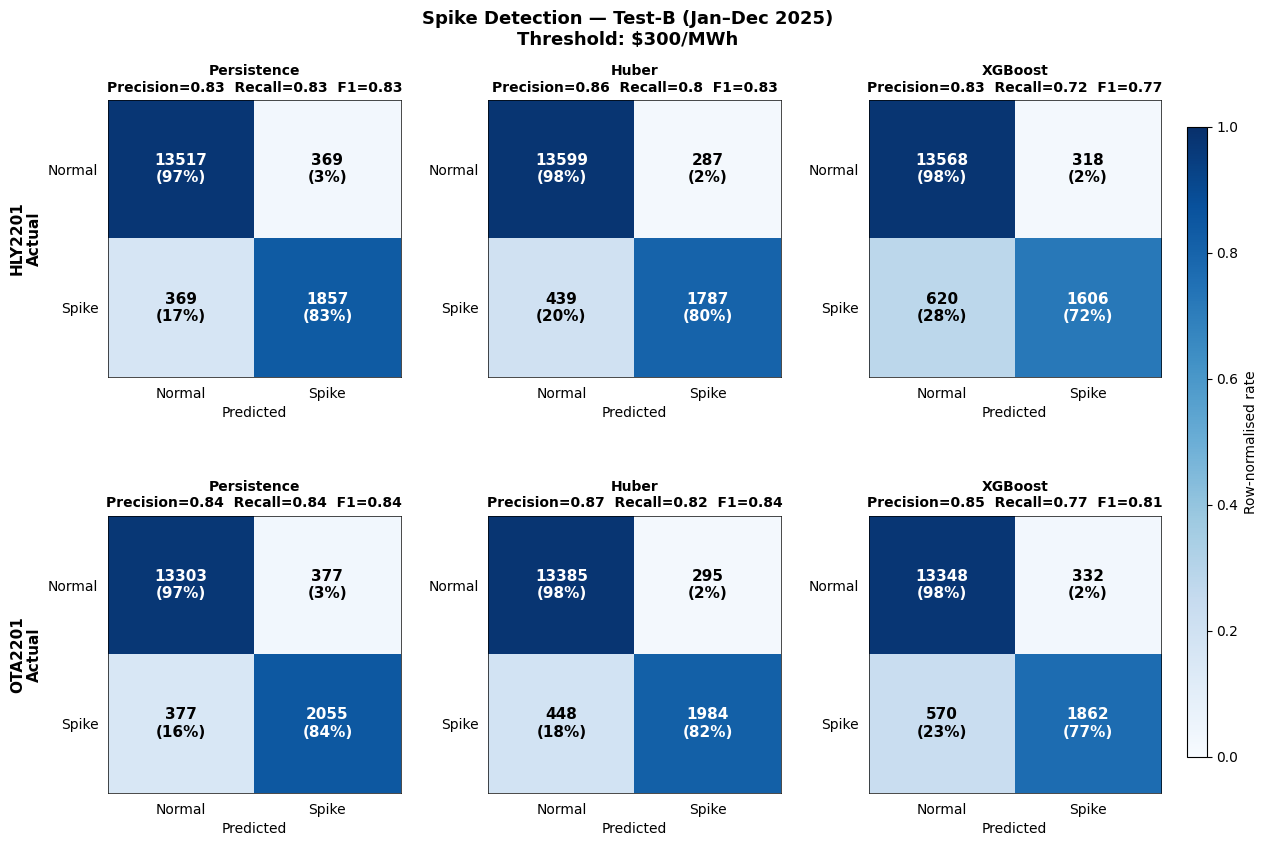

Spike class balance — Test-B:
  HLY2201: 2226 spikes / 16112 total (13.8%)
  OTA2201: 2432 spikes / 16112 total (15.1%)


In [ ]:
# Plot 5d — Spike Confusion Matrices (3 models, Test-B for reort)

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from sklearn.metrics import (confusion_matrix,
                              precision_score, recall_score, f1_score)

SPIKE_THRESH = 300
MODELS_FOCUS = ['Persistence', 'Huber', 'XGBoost']

fig, axes = plt.subplots(2, 3, figsize=(13, 9))
fig.suptitle(
    'Spike Detection — Test-B (Jan–Dec 2025)\nThreshold: $300/MWh',
    fontsize=13, fontweight='bold')

CMAP = plt.cm.Blues

for row, poc in enumerate(TARGET_POCS):
    df  = splits[poc]['test_b']
    sc  = ridge_scalers[poc]
    Xs  = sc.transform(df[FEATURE_COLS].values)
    Xr  = df[FEATURE_COLS].values
    y_t = (df['y'].values >= SPIKE_THRESH).astype(int)

    preds = {
        'Persistence': df['lag_1'].values,
        'Huber':       huber_models[poc].predict(Xs),
        'XGBoost':     xgb_models[poc].predict(Xr),
    }

    for col, model in enumerate(MODELS_FOCUS):
        ax = axes[row, col]
        pred_lbl = (preds[model] >= SPIKE_THRESH).astype(int)

        cm      = confusion_matrix(y_t, pred_lbl, labels=[0, 1])
        row_sum = cm.sum(axis=1, keepdims=True).clip(min=1)
        cm_norm = cm / row_sum

        ax.imshow(cm_norm, cmap=CMAP, vmin=0, vmax=1, aspect='auto')

        labels = ['Normal', 'Spike']
        for i in range(2):
            for j in range(2):
                val   = cm[i, j]
                pct   = cm_norm[i, j]
                color = 'white' if pct > 0.6 else 'black'
                ax.text(j, i,
                        str(val) + '\n(' + str(round(pct * 100)) + '%)',
                        ha='center', va='center',
                        fontsize=11, color=color, fontweight='bold')

        prec = precision_score(y_t, pred_lbl, zero_division=0)
        rec  = recall_score(y_t, pred_lbl, zero_division=0)
        f1   = f1_score(y_t, pred_lbl, zero_division=0)

        ax.set_xticks([0, 1]); ax.set_xticklabels(labels, fontsize=10)
        ax.set_yticks([0, 1]); ax.set_yticklabels(labels, fontsize=10)
        ax.set_xlabel('Predicted', fontsize=10)
        if col == 0:
            ax.set_ylabel(poc + '\nActual', fontsize=11, fontweight='bold')

        ax.set_title(
            model + '\nPrecision=' + str(round(prec, 2)) +
            '  Recall=' + str(round(rec, 2)) +
            '  F1=' + str(round(f1, 2)),
            fontsize=10, fontweight='bold')

        ax.tick_params(left=False, bottom=False)
        for spine in ax.spines.values():
            spine.set_linewidth(0.5)

cbar_ax = fig.add_axes([0.93, 0.15, 0.015, 0.7])
sm = plt.cm.ScalarMappable(cmap=CMAP, norm=mcolors.Normalize(0, 1))
sm.set_array([])
fig.colorbar(sm, cax=cbar_ax, label='Row-normalised rate')

plt.subplots_adjust(left=0.1, right=0.91, hspace=0.5, wspace=0.3)
plt.savefig('./data/plot5d_confusion_3models_testb.png', dpi=150, bbox_inches='tight')
plt.show()

print('Spike class balance — Test-B:')
for poc in TARGET_POCS:
    y = splits[poc]['test_b']['y'].values
    n = (y >= SPIKE_THRESH).sum()
    print('  ' + poc + ': ' + str(n) + ' spikes / ' + str(len(y)) +
          ' total (' + str(round(100 * n / len(y), 1)) + '%)')


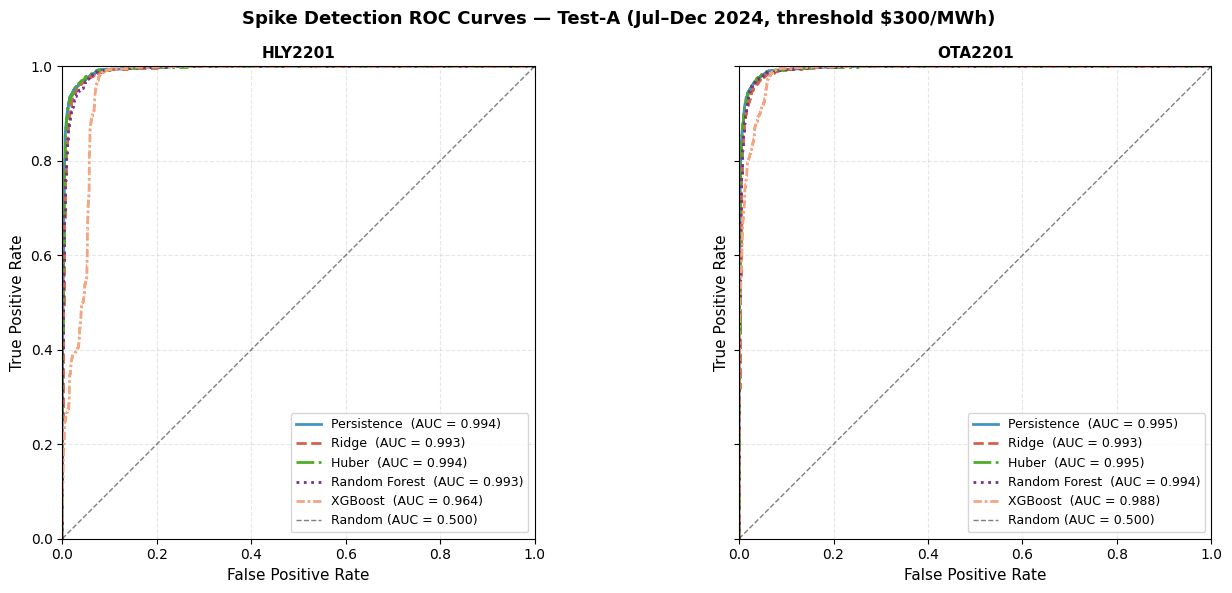

Saved: plot6_roc_curves.png


In [ ]:

# Plot 6 — Spike Detection ROC Curves
# Sweep the decision threshold on raw regression output to produce TPR/FPR at each cut-off.  True label = price >= $300. Evaluated on Test-A (spike-rich) for both PoCs.


import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc

SPIKE_THRESH = 300
MODELS = ['Persistence', 'Ridge', 'Huber', 'Random Forest', 'XGBoost']
LINE_STYLES = ['-', '--', '-.', ':', (0,(3,1,1,1))]
PALETTE = ['#4393C3','#D6604D','#4DAC26','#7B2D8B','#F4A582']

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
fig.suptitle(
    'Spike Detection ROC Curves — Test-A (Jul–Dec 2024, threshold \$300/MWh)',
    fontsize=13, fontweight='bold')

for col, poc in enumerate(TARGET_POCS):
    ax  = axes[col]
    df  = splits[poc]['test_a']
    sc  = ridge_scalers[poc]
    Xs  = sc.transform(df[FEATURE_COLS].values)
    Xr  = df[FEATURE_COLS].values
    y_t = (df['y'].values >= SPIKE_THRESH).astype(int)

    raw_preds = {
        'Persistence':   df['lag_1'].values,
        'Ridge':         ridge_models[poc].predict(Xs),
        'Huber':         huber_models[poc].predict(Xs),
        'Random Forest': rf_models[poc].predict(Xr),
        'XGBoost':       xgb_models[poc].predict(Xr),
    }

    for i, model in enumerate(MODELS):
        fpr, tpr, _ = roc_curve(y_t, raw_preds[model])
        roc_auc     = auc(fpr, tpr)
        label = model + '  (AUC = ' + str(round(roc_auc, 3)) + ')'
        ax.plot(fpr, tpr,
                color=PALETTE[i],
                linestyle=LINE_STYLES[i],
                linewidth=2.0,
                label=label)

    ax.plot([0, 1], [0, 1], 'k--', linewidth=1.0, alpha=0.5, label='Random (AUC = 0.500)')
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1])
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title(poc, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9, loc='lower right')
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('./data/plot6_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot6_roc_curves.png')


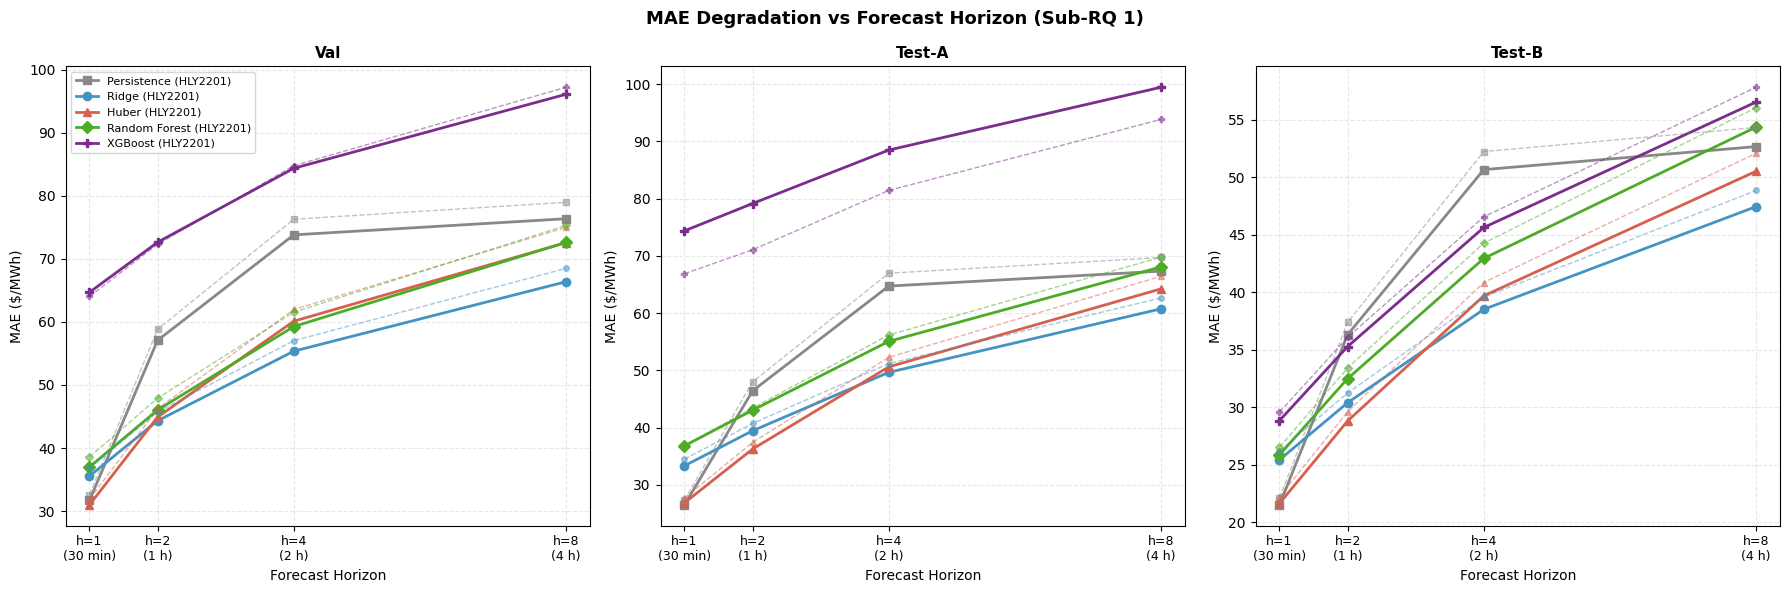

Saved: plot7_horizon_degradation.png


In [ ]:
# Plot 7 — Forecast Horizon Degradation (Sub-RQ 1)

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error

HORIZONS    = [1, 2, 4, 8]
H_LABELS    = ['h=1\n(30 min)', 'h=2\n(1 h)', 'h=4\n(2 h)', 'h=8\n(4 h)']
SPLITS_EVAL = ['val', 'test_a', 'test_b']
SPLIT_NAMES = {'val': 'Val', 'test_a': 'Test-A', 'test_b': 'Test-B'}

PALETTE_H = {
    'Persistence':   '#888888',
    'Ridge':         '#4393C3',
    'Huber':         '#D6604D',
    'Random Forest': '#4DAC26',
    'XGBoost':       '#7B2D8B',
}
MARKERS = {'Persistence':'s','Ridge':'o','Huber':'^','Random Forest':'D','XGBoost':'P'}

def direct_mae(poc, split_name, h):
    df = splits[poc][split_name].copy()
    y_true = df['y'].shift(-h + 1).dropna().values
    n      = len(y_true)
    if n == 0:
        return np.nan

    df2   = df.iloc[:n]
    sc    = ridge_scalers[poc]
    Xs    = sc.transform(df2[FEATURE_COLS].values)
    Xr    = df2[FEATURE_COLS].values

    lag_col = 'lag_' + str(h) if 'lag_' + str(h) in df2.columns else 'lag_1'
    return {
        'Persistence':   mean_absolute_error(y_true, df2[lag_col].values),
        'Ridge':         mean_absolute_error(y_true, ridge_models[poc].predict(Xs)),
        'Huber':         mean_absolute_error(y_true, huber_models[poc].predict(Xs)),
        'Random Forest': mean_absolute_error(y_true, rf_models[poc].predict(Xr)),
        'XGBoost':       mean_absolute_error(y_true, xgb_models[poc].predict(Xr)),
    }

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)
fig.suptitle('MAE Degradation vs Forecast Horizon (Sub-RQ 1)',
             fontsize=13, fontweight='bold')

for col, split_name in enumerate(SPLITS_EVAL):
    ax = axes[col]
    ax.set_title(SPLIT_NAMES[split_name], fontsize=11, fontweight='bold')

    poc = TARGET_POCS[0]   # show HLY2201; overlay OTA as thin lines

    for poc_i, poc in enumerate(TARGET_POCS):
        lw     = 2.0 if poc_i == 0 else 1.0
        ls_mod = '-' if poc_i == 0 else '--'

        for model in ['Persistence', 'Ridge', 'Huber', 'Random Forest', 'XGBoost']:
            maes = []
            for h in HORIZONS:
                res = direct_mae(poc, split_name, h)
                maes.append(res[model])

            label = model + ' (' + poc + ')' if poc_i == 0 else None
            ax.plot(HORIZONS, maes,
                    color=PALETTE_H[model],
                    linestyle=ls_mod,
                    linewidth=lw,
                    marker=MARKERS[model],
                    markersize=6 if poc_i == 0 else 4,
                    label=label,
                    alpha=1.0 if poc_i == 0 else 0.5)

    ax.set_xticks(HORIZONS)
    ax.set_xticklabels(H_LABELS, fontsize=9)
    ax.set_xlabel('Forecast Horizon', fontsize=10)
    ax.set_ylabel('MAE ($/MWh)', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.3)
    if col == 0:
        ax.legend(fontsize=8, loc='upper left', ncol=1)

plt.tight_layout()
plt.savefig('./data/plot7_horizon_degradation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot7_horizon_degradation.png')


In [ ]:
# Diebold-Mariano Test — Statistical Significance of Forecast Comparisons
# ------------------------------------------------------------

import numpy as np
import pandas as pd
from scipy import stats


def diebold_mariano(y_true, y_pred_1, y_pred_2, h=1, loss='mae'):
    """
    Diebold-Mariano test comparing two forecast series.

    Parameters
    ----------
    y_true   : array-like, actual values
    y_pred_1 : array-like, forecasts from model 1 (typically the baseline)
    y_pred_2 : array-like, forecasts from model 2 (typically the candidate)
    h        : int, forecast horizon (controls HAC lag truncation)
    loss     : 'mae' or 'mse', per-period loss function

    Returns
    -------
    dict with keys: dm_stat, p_value, mean_diff, n, better_model

    Interpretation
    --------------
    H0: both forecasts have equal expected loss
    H1: forecasts have different expected loss (two-sided)

    Negative dm_stat => model 1 has lower loss (model 1 is better)
    Positive dm_stat => model 2 has lower loss (model 2 is better)
    p < 0.05         => reject H0 at the 5% level
    """
    y_true   = np.asarray(y_true,   dtype=float)
    y_pred_1 = np.asarray(y_pred_1, dtype=float)
    y_pred_2 = np.asarray(y_pred_2, dtype=float)

    # Per-period loss
    if loss == 'mae':
        L1 = np.abs(y_true - y_pred_1)
        L2 = np.abs(y_true - y_pred_2)
    elif loss == 'mse':
        L1 = (y_true - y_pred_1) ** 2
        L2 = (y_true - y_pred_2) ** 2
    else:
        raise ValueError("loss must be 'mae' or 'mse'")

    # Loss differential
    d = L1 - L2
    T = len(d)
    mean_d = d.mean()

    # HAC variance estimator (Newey-West style)
    # Lag truncation: h-1 for h-step-ahead forecasts. For h=1, this is 0,
    # which reduces to the standard sample variance.
    gamma_0 = np.var(d, ddof=0)
    var_d   = gamma_0
    for k in range(1, h):
        gamma_k = np.mean((d[k:] - mean_d) * (d[:-k] - mean_d))
        var_d  += 2.0 * gamma_k

    # Guard against negative variance from finite-sample noise
    var_d = max(var_d, 1e-12)

    dm_stat = mean_d / np.sqrt(var_d / T)
    p_value = 2.0 * (1.0 - stats.norm.cdf(abs(dm_stat)))

    if p_value < 0.05:
        better = 'Model 1' if dm_stat < 0 else 'Model 2'
    else:
        better = 'Tie (not significant)'

    return {
        'dm_stat':      round(dm_stat, 3),
        'p_value':      round(p_value, 4),
        'mean_diff':    round(mean_d, 4),
        'n':            T,
        'better_model': better,
    }



# For the Main RQ comparisons
# Compare each candidate (Huber, Ridge, RF, XGBoost) against both baselines (Persistence, Seasonal Naive) on Test-A and Test-B.

def get_predictions(poc, model_name, split_name):
    """Reconstruct prediction array for any model on any split."""
    df = splits[poc][split_name]
    y_true = df['y'].values

    if model_name == 'Persistence':
        y_pred = df['lag_1'].values
    elif model_name == 'Seasonal Naive':
        y_pred = df['lag_48'].values
    elif model_name == 'Ridge':
        X = ridge_scalers[poc].transform(df[FEATURE_COLS].values)
        y_pred = ridge_models[poc].predict(X)
    elif model_name == 'Huber':
        X = ridge_scalers[poc].transform(df[FEATURE_COLS].values)
        y_pred = huber_models[poc].predict(X)
    elif model_name == 'Random Forest':
        y_pred = rf_models[poc].predict(df[FEATURE_COLS].values)
    elif model_name == 'XGBoost':
        y_pred = xgb_models[poc].predict(df[FEATURE_COLS].values)
    else:
        raise ValueError(f"Unknown model: {model_name}")

    return y_true, y_pred


COMPARISONS = [
    ('Persistence',    'Ridge'),
    ('Persistence',    'Huber'),
    ('Persistence',    'Random Forest'),
    ('Persistence',    'XGBoost'),
    ('Seasonal Naive', 'Huber'),
]

SPLITS_TO_TEST = ['test_a', 'test_b']

# Collect results
dm_rows = []
for poc in TARGET_POCS:
    for split_name in SPLITS_TO_TEST:
        for baseline, candidate in COMPARISONS:
            y_true, y_base = get_predictions(poc, baseline,  split_name)
            _,      y_cand = get_predictions(poc, candidate, split_name)

            result = diebold_mariano(y_true, y_base, y_cand, h=1, loss='mae')

            dm_rows.append({
                'PoC':          poc,
                'Split':        split_name,
                'Baseline':     baseline,
                'Candidate':    candidate,
                'DM stat':      result['dm_stat'],
                'p-value':      result['p_value'],
                'Mean Δ-loss':  result['mean_diff'],
                'n':            result['n'],
                'Winner':       (candidate if result['dm_stat'] > 0 and result['p_value'] < 0.05
                                 else baseline if result['dm_stat'] < 0 and result['p_value'] < 0.05
                                 else 'Tie'),
            })

dm_df = pd.DataFrame(dm_rows)

# Display
print("=" * 90)
print("Diebold-Mariano Test Results (MAE loss, h=1, two-sided, α = 0.05)")
print("=" * 90)
print("\nInterpretation:")
print("  DM stat > 0 and p < 0.05 => Candidate beats Baseline")
print("  DM stat < 0 and p < 0.05 => Baseline beats Candidate")
print("  p >= 0.05                => No statistically significant difference")
print()

for poc in TARGET_POCS:
    print(f"\n--- {poc} ---")
    sub = dm_df[dm_df['PoC'] == poc].drop(columns=['PoC'])
    print(sub.to_string(index=False))

# Saving for report
dm_df.to_csv('./data/diebold_mariano_results.csv', index=False)
print("\n\nSaved: ./data/diebold_mariano_results.csv")

Diebold-Mariano Test Results (MAE loss, h=1, two-sided, α = 0.05)

Interpretation:
  DM stat > 0 and p < 0.05 => Candidate beats Baseline
  DM stat < 0 and p < 0.05 => Baseline beats Candidate
  p >= 0.05                => No statistically significant difference


--- HLY2201 ---
 Split       Baseline     Candidate  DM stat  p-value  Mean Δ-loss     n      Winner
test_a    Persistence         Ridge   -9.560   0.0000      -6.8275  8761 Persistence
test_a    Persistence         Huber   -1.702   0.0888      -0.3538  8761         Tie
test_a    Persistence Random Forest  -10.068   0.0000     -10.3126  8761 Persistence
test_a    Persistence       XGBoost  -29.578   0.0000     -47.8818  8761 Persistence
test_a Seasonal Naive         Huber   19.155   0.0000      29.9570  8761       Huber
test_b    Persistence         Ridge  -17.576   0.0000      -3.9137 16112 Persistence
test_b    Persistence         Huber   -1.829   0.0674      -0.1200 16112         Tie
test_b    Persistence Random Forest  -1

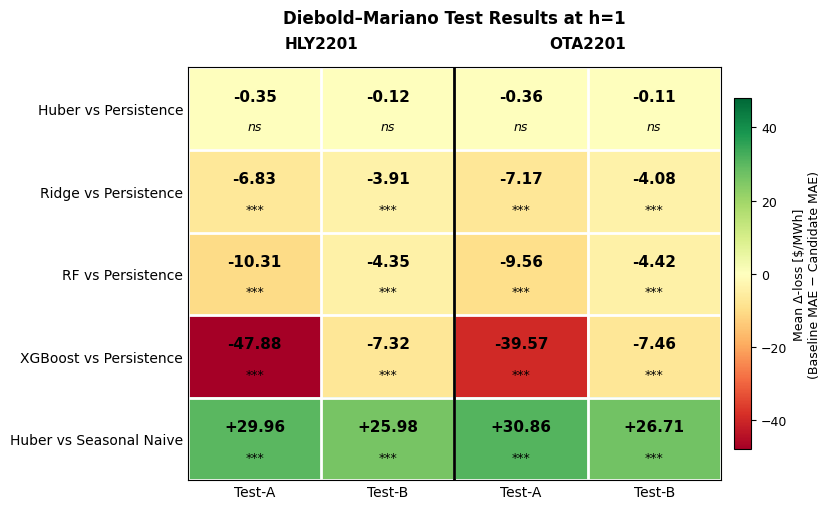

Saved: ./data/plot_dm_heatmap.png


In [ ]:
# Plot — Diebold-Mariano Heatmap

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np


COMPARISON_ORDER = [
    ('Persistence',    'Huber',         'Huber vs Persistence'),
    ('Persistence',    'Ridge',         'Ridge vs Persistence'),
    ('Persistence',    'Random Forest', 'RF vs Persistence'),
    ('Persistence',    'XGBoost',       'XGBoost vs Persistence'),
    ('Seasonal Naive', 'Huber',         'Huber vs Seasonal Naive'),
]

COL_ORDER = [
    ('HLY2201', 'test_a', 'Test-A'),
    ('HLY2201', 'test_b', 'Test-B'),
    ('OTA2201', 'test_a', 'Test-A'),
    ('OTA2201', 'test_b', 'Test-B'),
]

n_r, n_c = len(COMPARISON_ORDER), len(COL_ORDER)
delta = np.zeros((n_r, n_c))
pvals = np.zeros((n_r, n_c))

for i, (base, cand, _) in enumerate(COMPARISON_ORDER):
    for j, (poc, split, _) in enumerate(COL_ORDER):
        row = dm_df[(dm_df['PoC']       == poc)   &
                    (dm_df['Split']     == split) &
                    (dm_df['Baseline']  == base)  &
                    (dm_df['Candidate'] == cand)]
        if len(row):
            delta[i, j] = row.iloc[0]['Mean Δ-loss']
            pvals[i, j] = row.iloc[0]['p-value']


def sig_stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'


# ── Figure 
fig, ax = plt.subplots(figsize=(8.5, 5.2))

vmax = float(np.max(np.abs(delta)))
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)
cmap = plt.cm.RdYlGn

im = ax.imshow(delta, cmap=cmap, norm=norm, aspect='auto')

# Cell annotations
for i in range(n_r):
    for j in range(n_c):
        val = delta[i, j]
        p   = pvals[i, j]
        ax.text(j, i - 0.15, f'{val:+.2f}',
                ha='center', va='center',
                color='black', fontsize=11, fontweight='bold')
        ax.text(j, i + 0.22, sig_stars(p),
                ha='center', va='center',
                color='black', fontsize=9, style='italic')

# Row + column labels
ax.set_xticks(range(n_c))
ax.set_xticklabels([c[2] for c in COL_ORDER], fontsize=10)
ax.set_yticks(range(n_r))
ax.set_yticklabels([c[2] for c in COMPARISON_ORDER], fontsize=10)
ax.tick_params(axis='both', which='both', length=0)

# Bold separator between HLY and OTA columns
ax.axvline(1.5, color='black', linewidth=2)

# PoC group labels in AXES coordinates — just above the heatmap, below the title
ax.text(0.25, 1.04, 'HLY2201', transform=ax.transAxes,
        ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.text(0.75, 1.04, 'OTA2201', transform=ax.transAxes,
        ha='center', va='bottom', fontsize=11, fontweight='bold')

# Title — generous pad so it clears the PoC group labels
ax.set_title('Diebold–Mariano Test Results at h=1',
             fontsize=12, fontweight='bold', pad=32)

# Colorbar
cbar = plt.colorbar(im, ax=ax, shrink=0.85, pad=0.02)
cbar.set_label('Mean Δ-loss [$/MWh]\n(Baseline MAE − Candidate MAE)', fontsize=9)
cbar.ax.tick_params(labelsize=9)

# White gridlines between cells
ax.set_xticks(np.arange(-0.5, n_c, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n_r, 1), minor=True)
ax.grid(which='minor', color='white', linewidth=2)
ax.tick_params(which='minor', length=0)

plt.tight_layout()
plt.savefig('./data/plot_dm_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ./data/plot_dm_heatmap.png')

* Concept Drift Experimentation

  HLY2201  refit 2025-01-01  train 2023-07-01→2024-12-31 (n=26,157)  apply 2025-01-01→2025-03-31 (n=4,317)
  HLY2201  refit 2025-04-01  train 2023-10-01→2025-03-31 (n=26,063)  apply 2025-04-01→2025-06-30 (n=4,364)
  HLY2201  refit 2025-07-01  train 2024-01-01→2025-06-30 (n=26,161)  apply 2025-07-01→2025-09-30 (n=3,452)
  HLY2201  refit 2025-10-01  train 2024-04-01→2025-09-30 (n=25,258)  apply 2025-10-01→2025-12-31 (n=3,979)
  OTA2201  refit 2025-01-01  train 2023-07-01→2024-12-31 (n=26,157)  apply 2025-01-01→2025-03-31 (n=4,317)
  OTA2201  refit 2025-04-01  train 2023-10-01→2025-03-31 (n=26,063)  apply 2025-04-01→2025-06-30 (n=4,364)
  OTA2201  refit 2025-07-01  train 2024-01-01→2025-06-30 (n=26,161)  apply 2025-07-01→2025-09-30 (n=3,452)
  OTA2201  refit 2025-10-01  train 2024-04-01→2025-09-30 (n=25,258)  apply 2025-10-01→2025-12-31 (n=3,979)


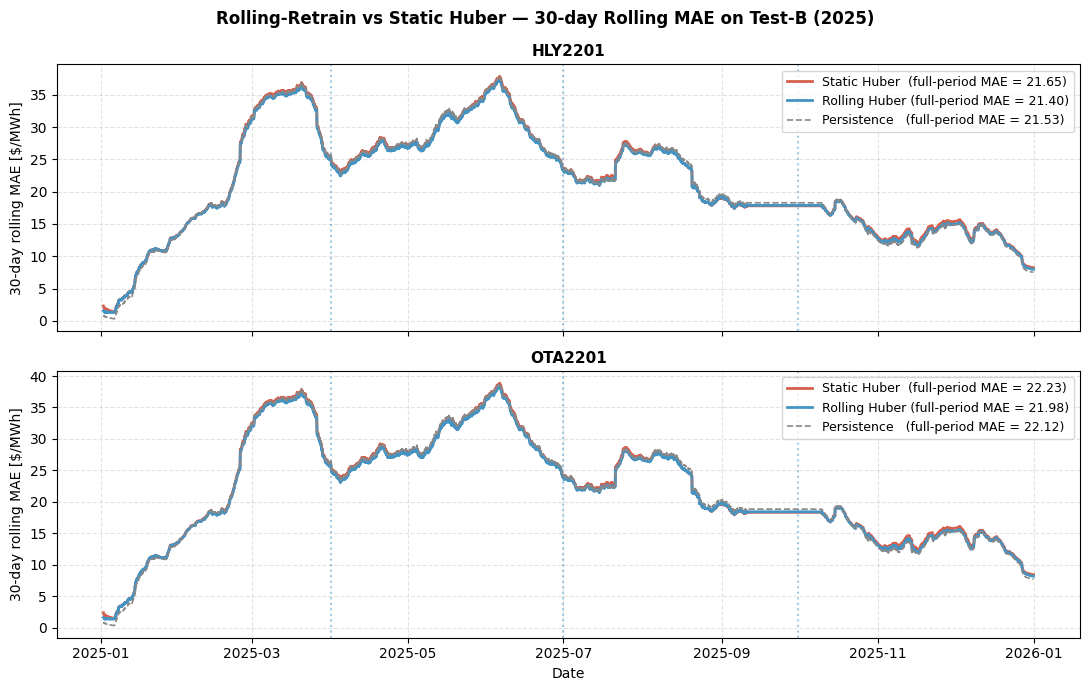

Saved: ./data/plot_rolling_retrain.png


In [ ]:
# Rolling Retrain Experiment — Sub-RQ on Concept Drift
# ------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import HuberRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error


# Refit anchor dates and the window used for each refit
ROLLING_REFITS = [
    ('2025-01-01', '2023-07-01', '2024-12-31', '2025-01-01', '2025-03-31'),
    ('2025-04-01', '2023-10-01', '2025-03-31', '2025-04-01', '2025-06-30'),
    ('2025-07-01', '2024-01-01', '2025-06-30', '2025-07-01', '2025-09-30'),
    ('2025-10-01', '2024-04-01', '2025-09-30', '2025-10-01', '2025-12-31'),
]

# Reuse the best (epsilon, alpha) found on validation
HUBER_EPS = huber_models[TARGET_POCS[0]].epsilon
HUBER_ALP = huber_models[TARGET_POCS[0]].alpha

rolling_predictions = {poc: pd.Series(index=splits[poc]['test_b'].index,
                                       dtype=float) for poc in TARGET_POCS}

for poc in TARGET_POCS:
    # Build the full feature matrix once — same features used everywhere
    full = features[poc]

    for refit_date, win_start, win_end, apply_start, apply_end in ROLLING_REFITS:
        train_win = full.loc[win_start:win_end]
        apply_win = full.loc[apply_start:apply_end]

        scaler = StandardScaler()
        X_tr   = scaler.fit_transform(train_win[FEATURE_COLS].values)
        y_tr   = train_win['y'].values

        model = HuberRegressor(epsilon=HUBER_EPS, alpha=HUBER_ALP, max_iter=300)
        model.fit(X_tr, y_tr)

        X_ap = scaler.transform(apply_win[FEATURE_COLS].values)
        rolling_predictions[poc].loc[apply_win.index] = model.predict(X_ap)

        n_train = len(train_win)
        n_apply = len(apply_win)
        print(f'  {poc}  refit {refit_date}  '
              f'train {win_start}→{win_end} (n={n_train:,})  '
              f'apply {apply_start}→{apply_end} (n={n_apply:,})')

# ── Compute 30-day rolling MAE for static vs rolling 
def rolling_mae(y_true, y_pred, window_days=30, freq_per_day=48):
    abs_err = (y_true - y_pred).abs()
    return abs_err.rolling(window=window_days * freq_per_day, min_periods=48).mean()


fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
fig.suptitle('Rolling-Retrain vs Static Huber — 30-day Rolling MAE on Test-B (2025)',
             fontsize=12, fontweight='bold')

for ax, poc in zip(axes, TARGET_POCS):
    df = splits[poc]['test_b']
    y_true = df['y']

    # Static Huber prediction (your existing model)
    sc = ridge_scalers[poc]
    y_static = pd.Series(huber_models[poc].predict(sc.transform(df[FEATURE_COLS].values)),
                         index=df.index)

    # Rolling Huber prediction
    y_roll = rolling_predictions[poc].loc[df.index]

    # Persistence as a reference line
    y_pers = df['lag_1']

    mae_static = rolling_mae(y_true, y_static)
    mae_roll   = rolling_mae(y_true, y_roll)
    mae_pers   = rolling_mae(y_true, y_pers)

    ax.plot(mae_static.index, mae_static.values, color='#D6604D',
            linewidth=2, label=f'Static Huber  (full-period MAE = '
                               f'{mean_absolute_error(y_true.dropna(), y_static.loc[y_true.dropna().index]):.2f})')
    ax.plot(mae_roll.index, mae_roll.values, color='#4393C3',
            linewidth=2, label=f'Rolling Huber (full-period MAE = '
                               f'{mean_absolute_error(y_true.dropna(), y_roll.loc[y_true.dropna().index]):.2f})')
    ax.plot(mae_pers.index, mae_pers.values, color='#888888',
            linewidth=1.2, linestyle='--',
            label=f'Persistence   (full-period MAE = '
                  f'{mean_absolute_error(y_true.dropna(), y_pers.loc[y_true.dropna().index]):.2f})')

    # Mark refit dates with vertical lines
    for refit_date, *_ in ROLLING_REFITS[1:]:
        ax.axvline(pd.Timestamp(refit_date), color='#4393C3',
                   linestyle=':', alpha=0.5)

    ax.set_title(poc, fontsize=11, fontweight='bold')
    ax.set_ylabel('30-day rolling MAE [$/MWh]', fontsize=10)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.35)

axes[-1].set_xlabel('Date', fontsize=10)
plt.tight_layout()
plt.savefig('./data/plot_rolling_retrain.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ./data/plot_rolling_retrain.png')

In [ ]:
# Rolling-Retrain Sensitivity — Window-Length Sweep 

WINDOW_CONFIGS = [
    ('Static (no refit)', None),
    ('Rolling 6 months',  6),
    ('Rolling 12 months', 12),
    ('Rolling 18 months', 18),
    ('Rolling 24 months', 24),
]

REFIT_DATES  = ['2025-01-01', '2025-04-01', '2025-07-01', '2025-10-01']
APPLY_RANGES = [
    ('2025-01-01', '2025-03-31'),
    ('2025-04-01', '2025-06-30'),
    ('2025-07-01', '2025-09-30'),
    ('2025-10-01', '2025-12-31'),
]


def fit_rolling_huber(poc, window_months):
    """Fit Huber with rolling window of N months.
       window_months=None => use the static fit."""
    if window_months is None:
        df = splits[poc]['test_b']
        sc = ridge_scalers[poc]
        return pd.Series(
            huber_models[poc].predict(sc.transform(df[FEATURE_COLS].values)),
            index=df.index)

    offset = pd.DateOffset(months=window_months)
    preds  = pd.Series(index=splits[poc]['test_b'].index, dtype=float)
    full   = features[poc]

    for refit_date, (apply_start, apply_end) in zip(REFIT_DATES, APPLY_RANGES):
        refit_ts  = pd.Timestamp(refit_date)
        win_start = refit_ts - offset
        win_end   = refit_ts - pd.Timedelta(seconds=1)

        train_win = full.loc[win_start:win_end]
        apply_win = full.loc[apply_start:apply_end]
        if len(train_win) < 1000:
            continue

        scaler = StandardScaler()
        X_tr   = scaler.fit_transform(train_win[FEATURE_COLS].values)
        y_tr   = train_win['y'].values

        model = HuberRegressor(epsilon=HUBER_EPS, alpha=HUBER_ALP, max_iter=300)
        model.fit(X_tr, y_tr)

        X_ap = scaler.transform(apply_win[FEATURE_COLS].values)
        preds.loc[apply_win.index] = model.predict(X_ap)

    return preds


# ── Run sweep 
sweep_rows        = []
sweep_predictions = {}

for poc in TARGET_POCS:
    df         = splits[poc]['test_b']
    y_true_all = df['y']

    static_preds = fit_rolling_huber(poc, None)
    sweep_predictions[(poc, 'Static (no refit)')] = static_preds

    for label, months in WINDOW_CONFIGS:
        preds = static_preds if months is None else fit_rolling_huber(poc, months)
        sweep_predictions[(poc, label)] = preds

        common = y_true_all.dropna().index.intersection(preds.dropna().index)
        y_true = y_true_all.loc[common].values
        y_pred = preds.loc[common].values

        mae = mean_absolute_error(y_true, y_pred)

        if months is None:
            dm_p, delta_vs_static = np.nan, 0.0
        else:
            dm = diebold_mariano(
                y_true,
                static_preds.loc[common].values,   # baseline = static
                y_pred,                            # candidate = rolling
                h=1, loss='mae')
            dm_p = dm['p_value']
            delta_vs_static = -dm['mean_diff']     # negative => rolling improved

        sweep_rows.append({
            'PoC':           poc,
            'Configuration': label,
            'Window':        '—' if months is None else f'{months} mo',
            'MAE':           round(mae, 3),
            'Δ vs Static':   round(delta_vs_static, 3),
            'DM p-value':    round(dm_p, 4) if not np.isnan(dm_p) else np.nan,
            'Verdict':       ('—'              if months is None
                              else 'Rolling improves' if dm_p < 0.05 and delta_vs_static < 0
                              else 'Static improves'  if dm_p < 0.05 and delta_vs_static > 0
                              else 'No diff.'),
        })

sweep_df = pd.DataFrame(sweep_rows)

# ── Display 
print('=' * 80)
print('Rolling-Retrain Window-Length Sensitivity (Test-B, h=1, DM vs Static)')
print('=' * 80)
for poc in TARGET_POCS:
    print(f'\n--- {poc} ---')
    print(sweep_df[sweep_df['PoC'] == poc]
          .drop(columns=['PoC'])
          .to_string(index=False))

sweep_df.to_csv('./data/rolling_window_sweep.csv', index=False)
print('\nSaved: ./data/rolling_window_sweep.csv')

Rolling-Retrain Window-Length Sensitivity (Test-B, h=1, DM vs Static)

--- HLY2201 ---
    Configuration Window    MAE  Δ vs Static  DM p-value          Verdict
Static (no refit)      — 21.648        0.000         NaN                —
 Rolling 6 months   6 mo 22.079        0.432         0.0  Static improves
Rolling 12 months  12 mo 21.367       -0.281         0.0 Rolling improves
Rolling 18 months  18 mo 21.400       -0.248         0.0 Rolling improves
Rolling 24 months  24 mo 21.429       -0.219         0.0 Rolling improves

--- OTA2201 ---
    Configuration Window    MAE  Δ vs Static  DM p-value          Verdict
Static (no refit)      — 22.234        0.000         NaN                —
 Rolling 6 months   6 mo 22.667        0.434         0.0  Static improves
Rolling 12 months  12 mo 21.945       -0.289         0.0 Rolling improves
Rolling 18 months  18 mo 21.980       -0.254         0.0 Rolling improves
Rolling 24 months  24 mo 22.010       -0.223         0.0 Rolling improves

Saved: 

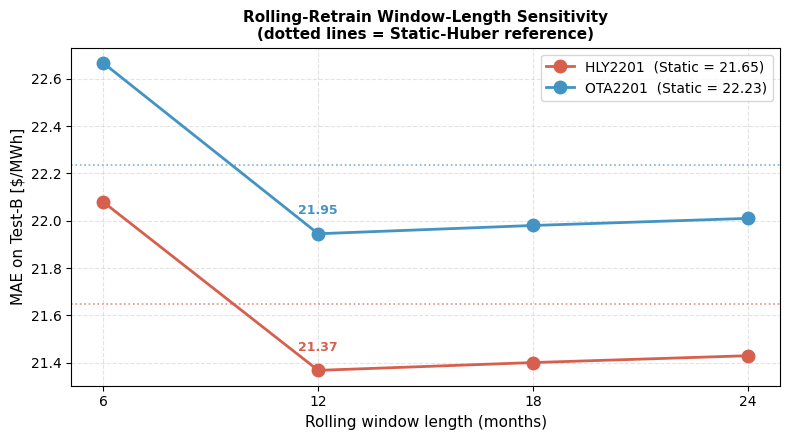

In [48]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4.5))

windows  = [6, 12, 18, 24]
colors   = {'HLY2201': '#D6604D', 'OTA2201': '#4393C3'}

for poc in TARGET_POCS:
    sub      = sweep_df[(sweep_df['PoC'] == poc) & (sweep_df['Window'] != '—')]
    static_mae = sweep_df[(sweep_df['PoC'] == poc) &
                          (sweep_df['Configuration'] == 'Static (no refit)')]['MAE'].iloc[0]

    ax.plot(windows, sub['MAE'], '-o', color=colors[poc], markersize=9,
            linewidth=2, label=f'{poc}  (Static = {static_mae:.2f})')
    ax.axhline(static_mae, color=colors[poc], linestyle=':', linewidth=1.2, alpha=0.7)

# Annotate the best point per PoC
for poc in TARGET_POCS:
    sub = sweep_df[(sweep_df['PoC'] == poc) & (sweep_df['Window'] != '—')]
    best_idx = sub['MAE'].idxmin()
    best_window = int(sub.loc[best_idx, 'Window'].split()[0])
    best_mae    = sub.loc[best_idx, 'MAE']
    ax.annotate(f'{best_mae:.2f}', xy=(best_window, best_mae),
                xytext=(0, +14), textcoords='offset points',
                ha='center', fontsize=9, color=colors[poc], fontweight='bold')

ax.set_xticks(windows)
ax.set_xlabel('Rolling window length (months)', fontsize=11)
ax.set_ylabel('MAE on Test-B [$/MWh]', fontsize=11)
ax.set_title('Rolling-Retrain Window-Length Sensitivity\n'
             '(dotted lines = Static-Huber reference)',
             fontsize=11, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.35)
ax.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.savefig('./data/plot_window_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

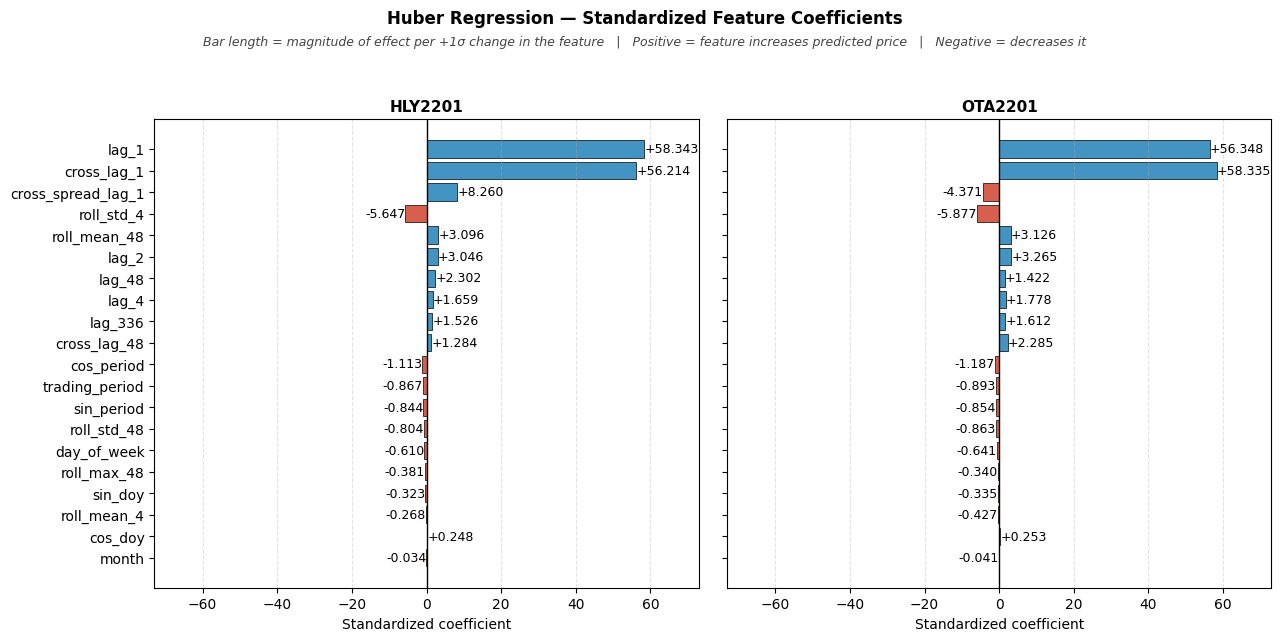


Top 5 Features by |Coefficient| — Huber Regression

--- HLY2201 ---
  lag_1                      +58.3426  ↑
  cross_lag_1                +56.2145  ↑
  cross_spread_lag_1         +8.2600  ↑
  roll_std_4                 -5.6467  ↓
  roll_mean_48               +3.0959  ↑

--- OTA2201 ---
  cross_lag_1                +58.3345  ↑
  lag_1                      +56.3483  ↑
  roll_std_4                 -5.8768  ↓
  cross_spread_lag_1         -4.3708  ↓
  lag_2                      +3.2648  ↑

Saved: ./data/plot_huber_coefficients.png


In [ ]:
# Plot — Standardized Huber Coefficients (Interpretability)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Extract coefficients
coef_data = {}
for poc in TARGET_POCS:
    coefs = huber_models[poc].coef_
    coef_data[poc] = pd.Series(coefs, index=FEATURE_COLS).sort_values(key=abs)

# HLY ordering as the reference; OTA features will follow the same order
ordered_features = coef_data[TARGET_POCS[0]].index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(13, max(6, 0.32 * len(ordered_features))),
                         sharey=True)
fig.suptitle('Huber Regression — Standardized Feature Coefficients',
             fontsize=12, fontweight='bold', y=0.995)
fig.text(0.5, 0.955,
         'Bar length = magnitude of effect per +1σ change in the feature   |   '
         'Positive = feature increases predicted price   |   Negative = decreases it',
         ha='center', va='top', fontsize=9, style='italic', color='#444')

for ax, poc in zip(axes, TARGET_POCS):
    coefs   = coef_data[poc].reindex(ordered_features)
    colors  = ['#4393C3' if c >= 0 else '#D6604D' for c in coefs.values]

    bars = ax.barh(range(len(ordered_features)), coefs.values,
                   color=colors, edgecolor='black', linewidth=0.5)

    # Annotate each bar with its value
    for i, (bar, val) in enumerate(zip(bars, coefs.values)):
        ax.text(val + (0.02 if val >= 0 else -0.02), i,
                f'{val:+.3f}',
                va='center',
                ha='left' if val >= 0 else 'right',
                fontsize=9, color='black')

    # Zero line
    ax.axvline(0, color='black', linewidth=1)

    ax.set_yticks(range(len(ordered_features)))
    ax.set_yticklabels(ordered_features, fontsize=10)
    ax.set_xlabel('Standardized coefficient', fontsize=10)
    ax.set_title(poc, fontsize=11, fontweight='bold')
    ax.grid(True, axis='x', linestyle='--', alpha=0.35)

    # Provide a little headroom on the x-axis for the annotation labels
    xmax = max(abs(coefs.min()), abs(coefs.max())) * 1.25
    ax.set_xlim(-xmax, xmax)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('./data/plot_huber_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n' + '=' * 80)
print('Top 5 Features by |Coefficient| — Huber Regression')
print('=' * 80)
for poc in TARGET_POCS:
    print(f'\n--- {poc} ---')
    top5 = coef_data[poc].reindex(coef_data[poc].abs().sort_values(ascending=False).index).head(5)
    for feat, val in top5.items():
        direction = '↑' if val > 0 else '↓'
        print(f'  {feat:<25s}  {val:+.4f}  {direction}')

print('\nSaved: ./data/plot_huber_coefficients.png')

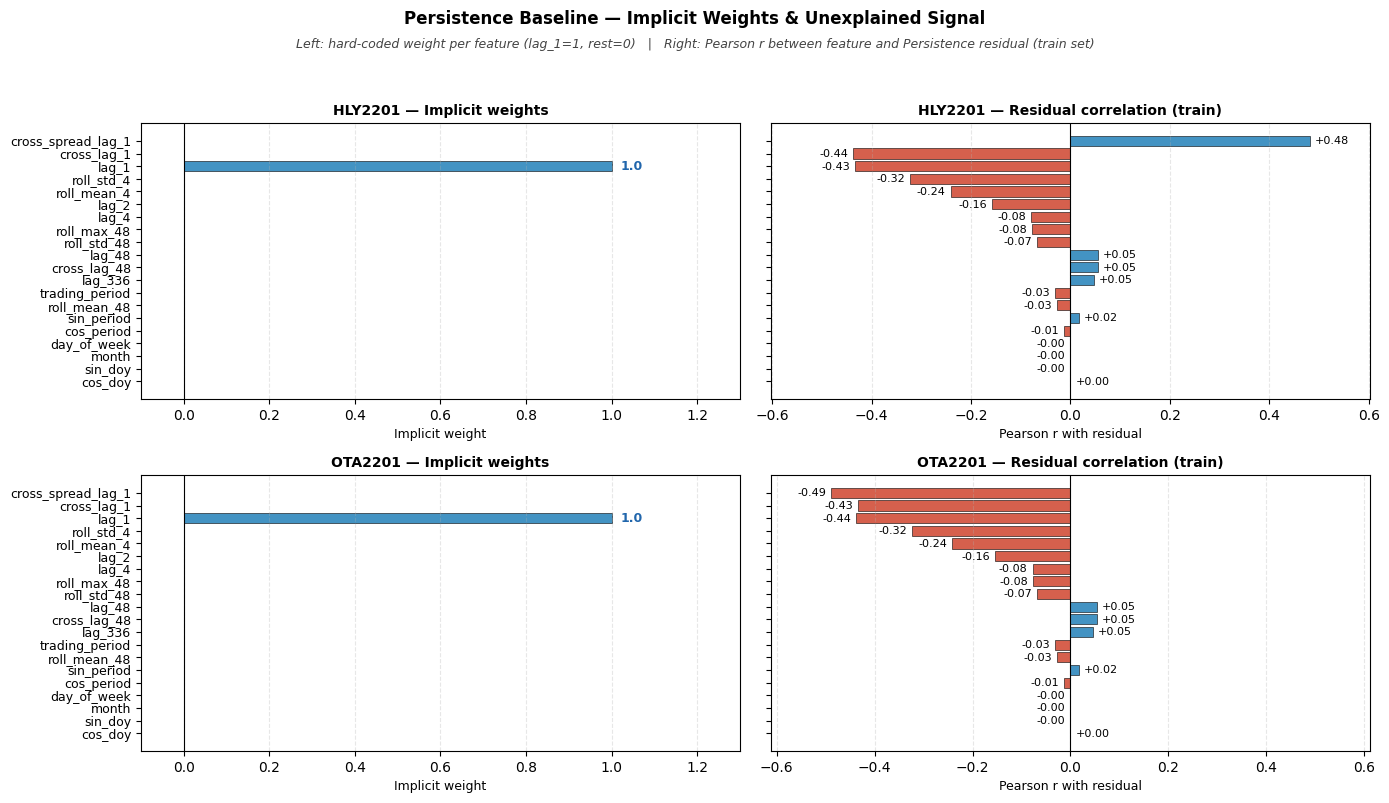


Top 5 features correlated with Persistence residuals (train set)

--- HLY2201 ---
  cross_spread_lag_1      r = +0.482
  cross_lag_1             r = -0.437
  lag_1                   r = -0.433
  roll_std_4              r = -0.323
  roll_mean_4             r = -0.241

--- OTA2201 ---
  cross_spread_lag_1      r = -0.489
  lag_1                   r = -0.437
  cross_lag_1             r = -0.433
  roll_std_4              r = -0.324
  roll_mean_4             r = -0.241


In [ ]:
# Plot — Persistence: Implicit Weights + Residual Correlations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

fig, axes = plt.subplots(2, 2, figsize=(14, max(8, 0.38 * len(FEATURE_COLS))),
                         sharey=True)
fig.suptitle('Persistence Baseline — Implicit Weights & Unexplained Signal',
             fontsize=12, fontweight='bold', y=0.998)
fig.text(0.5, 0.963,
         'Left: hard-coded weight per feature (lag_1=1, rest=0)   |   '
         'Right: Pearson r between feature and Persistence residual (train set)',
         ha='center', va='top', fontsize=9, style='italic', color='#444')

# Feature ordering: sort by |residual correlation| on HLY for consistent ordering
_ref_poc  = TARGET_POCS[0]
_train_df = splits[_ref_poc]['train']
_resid    = _train_df['y'].values - _train_df['lag_1'].values
_corr_ref = pd.Series(
    {f: np.corrcoef(_train_df[f].values, _resid)[0, 1] for f in FEATURE_COLS},
    name='corr'
)
ordered_features = _corr_ref.reindex(_corr_ref.abs().sort_values().index).index.tolist()

for row, poc in enumerate(TARGET_POCS):
    train_df = splits[poc]['train']
    residuals = train_df['y'].values - train_df['lag_1'].values

    # ── Left: implicit weight vector 
    ax_w = axes[row, 0]
    weights = pd.Series(
        {f: (1.0 if f == 'lag_1' else 0.0) for f in FEATURE_COLS}
    ).reindex(ordered_features)

    colors_w = ['#4393C3' if f == 'lag_1' else '#CCCCCC' for f in ordered_features]
    ax_w.barh(range(len(ordered_features)), weights.values,
              color=colors_w, edgecolor='black', linewidth=0.4)
    ax_w.axvline(0, color='black', linewidth=0.8)
    ax_w.set_yticks(range(len(ordered_features)))
    ax_w.set_yticklabels(ordered_features, fontsize=9)
    ax_w.set_xlabel('Implicit weight', fontsize=9)
    ax_w.set_title(poc + ' — Implicit weights', fontsize=10, fontweight='bold')
    ax_w.set_xlim(-0.1, 1.3)
    ax_w.text(1.02, ordered_features.index('lag_1'),
              '1.0', va='center', fontsize=9, color='#2166AC', fontweight='bold')
    ax_w.grid(True, axis='x', linestyle='--', alpha=0.3)

    # ── Right: feature–residual correlation 
    ax_c = axes[row, 1]
    corr = pd.Series(
        {f: np.corrcoef(train_df[f].values, residuals)[0, 1] for f in FEATURE_COLS}
    ).reindex(ordered_features)

    colors_c = ['#4393C3' if v >= 0 else '#D6604D' for v in corr.values]
    ax_c.barh(range(len(ordered_features)), corr.values,
              color=colors_c, edgecolor='black', linewidth=0.4)
    for i, val in enumerate(corr.values):
        ax_c.text(val + (0.01 if val >= 0 else -0.01), i,
                  f'{val:+.2f}',
                  va='center', ha='left' if val >= 0 else 'right',
                  fontsize=8, color='black')
    ax_c.axvline(0, color='black', linewidth=0.8)
    ax_c.set_yticks(range(len(ordered_features)))
    ax_c.set_yticklabels(ordered_features, fontsize=9)
    ax_c.set_xlabel('Pearson r with residual', fontsize=9)
    ax_c.set_title(poc + ' — Residual correlation (train)', fontsize=10, fontweight='bold')
    xmax = corr.abs().max() * 1.25
    ax_c.set_xlim(-xmax, xmax)
    ax_c.grid(True, axis='x', linestyle='--', alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig('./data/plot_persistence_weights.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n' + '=' * 70)
print('Top 5 features correlated with Persistence residuals (train set)')
print('=' * 70)
for poc in TARGET_POCS:
    train_df  = splits[poc]['train']
    residuals = train_df['y'].values - train_df['lag_1'].values
    corr = pd.Series(
        {f: np.corrcoef(train_df[f].values, residuals)[0, 1] for f in FEATURE_COLS}
    )
    top5 = corr.reindex(corr.abs().sort_values(ascending=False).index).head(5)
    print(f'\n--- {poc} ---')
    for feat, val in top5.items():
        print(f'  {feat:<22s}  r = {val:+.3f}')


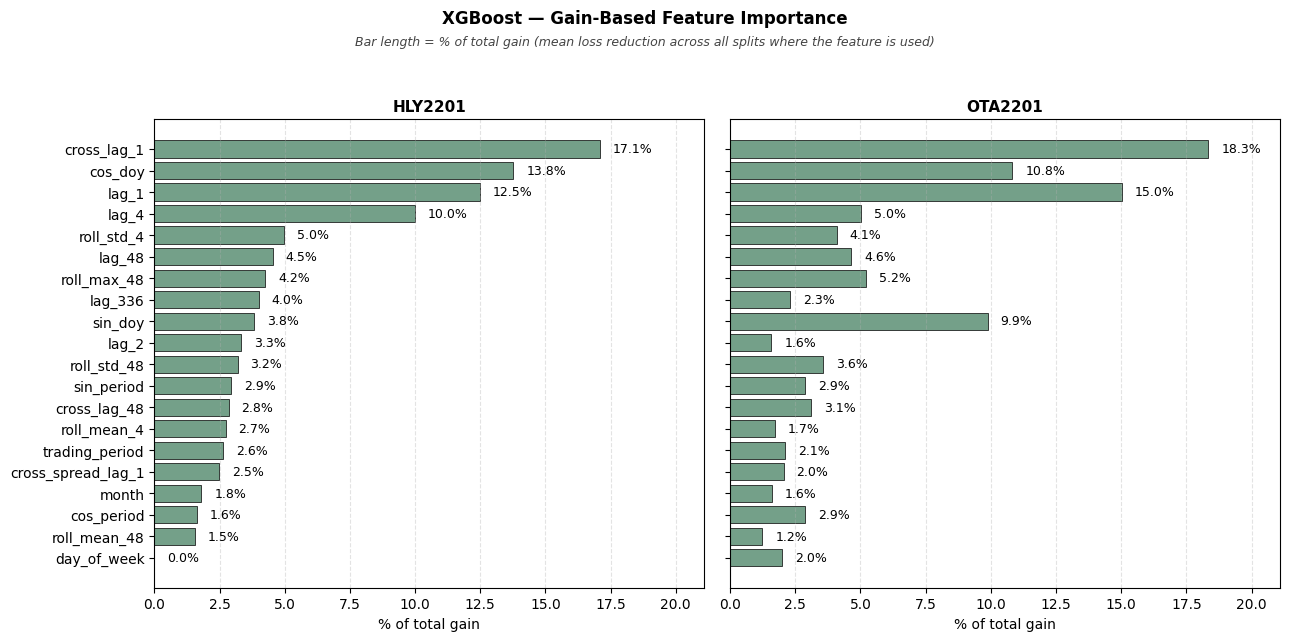


Top 5 Features by Gain — XGBoost

--- HLY2201 ---
  cross_lag_1                17.09% of total gain
  cos_doy                    13.77% of total gain
  lag_1                      12.48% of total gain
  lag_4                       9.98% of total gain
  roll_std_4                  4.98% of total gain

--- OTA2201 ---
  cross_lag_1                18.34% of total gain
  lag_1                      15.02% of total gain
  cos_doy                    10.83% of total gain
  sin_doy                     9.88% of total gain
  roll_max_48                 5.22% of total gain

Huber-vs-XGBoost — Top 5 Features per Model

--- HLY2201 ---
  rank  Huber                       XGBoost                     
  ----  -----                       -------                     
  1     lag_1                       cross_lag_1                 
  2     cross_lag_1                 cos_doy                     
  3     cross_spread_lag_1          lag_1                       
  4     roll_std_4                  lag_4    

In [ ]:
# Plot — XGBoost Feature Importance (gain-based)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Extract gain-based importances for both PoCs
importance_data = {}
for poc in TARGET_POCS:
    booster = xgb_models[poc].get_booster()
    score   = booster.get_score(importance_type='gain')
    
    if all(k.startswith('f') and k[1:].isdigit() for k in score.keys()):
        importance = pd.Series({FEATURE_COLS[int(k[1:])]: v for k, v in score.items()})
    else:
        importance = pd.Series(score)
    # Add any features that didn't get used (gain = 0)
    importance = importance.reindex(FEATURE_COLS).fillna(0.0)
    # Normalize to percent of total gain so the magnitudes are comparable
    importance = 100.0 * importance / importance.sum()
    importance_data[poc] = importance.sort_values(ascending=True)

# Use HLY ordering as the reference; OTA features follow same order
ordered_features = importance_data[TARGET_POCS[0]].index.tolist()

# ── Figure 
fig, axes = plt.subplots(1, 2, figsize=(13, max(6, 0.32 * len(ordered_features))),
                         sharey=True)
fig.suptitle('XGBoost — Gain-Based Feature Importance',
             fontsize=12, fontweight='bold', y=0.995)
fig.text(0.5, 0.955,
         'Bar length = % of total gain (mean loss reduction across all splits where the feature is used)',
         ha='center', va='top', fontsize=9, style='italic', color='#444')

for ax, poc in zip(axes, TARGET_POCS):
    imps = importance_data[poc].reindex(ordered_features)

    bars = ax.barh(range(len(ordered_features)), imps.values,
                   color='#74A089', edgecolor='black', linewidth=0.5)

    # Annotate each bar with its value
    for i, (bar, val) in enumerate(zip(bars, imps.values)):
        ax.text(val + 0.5, i, f'{val:.1f}%',
                va='center', ha='left',
                fontsize=9, color='black')

    ax.set_yticks(range(len(ordered_features)))
    ax.set_yticklabels(ordered_features, fontsize=10)
    ax.set_xlabel('% of total gain', fontsize=10)
    ax.set_title(poc, fontsize=11, fontweight='bold')
    ax.grid(True, axis='x', linestyle='--', alpha=0.35)
    ax.set_xlim(0, max(importance_data[poc].max(), importance_data[TARGET_POCS[1]].max()) * 1.15)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('./data/plot_xgboost_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Print top-5 tables and a Huber-vs-XGBoost ranking comparison ───
print('\n' + '=' * 80)
print('Top 5 Features by Gain — XGBoost')
print('=' * 80)
for poc in TARGET_POCS:
    print(f'\n--- {poc} ---')
    top5 = importance_data[poc].sort_values(ascending=False).head(5)
    for feat, val in top5.items():
        print(f'  {feat:<25s}  {val:5.2f}% of total gain')

# Side-by-side ranking comparison (Huber vs XGBoost)
print('\n' + '=' * 80)
print('Huber-vs-XGBoost — Top 5 Features per Model')
print('=' * 80)
for poc in TARGET_POCS:
    print(f'\n--- {poc} ---')
    huber_top  = coef_data[poc].reindex(coef_data[poc].abs().sort_values(ascending=False).index).head(5).index.tolist()
    xgb_top    = importance_data[poc].sort_values(ascending=False).head(5).index.tolist()
    print(f'  {"rank":<6}{"Huber":<28}{"XGBoost":<28}')
    print(f'  {"----":<6}{"-----":<28}{"-------":<28}')
    for i in range(5):
        h = huber_top[i] if i < len(huber_top) else '—'
        x = xgb_top[i]   if i < len(xgb_top)   else '—'
        marker = '   ←same' if h == x else ''
        print(f'  {i+1:<6}{h:<28}{x:<28}{marker}')

print('\nSaved: ./data/plot_xgboost_importance.png')

In [ ]:

# Plot — Sub-RQ 1: Forecast Horizon Degradation

import matplotlib.pyplot as plt
import numpy as np

# Sanity check
assert 'rq1_full' in dir(), 'Run Cell 36 (Sub-RQ 1 main experiment) first.'

HORIZONS    = [1, 2, 4, 48]
H_LABELS    = ['h=1\n(30 min)', 'h=2\n(1 h)', 'h=4\n(2 h)', 'h=48\n(24 h)']
MODELS      = ['Persistence', 'Huber', 'XGBoost']   # three selected models

PALETTE = {
    'Persistence':   '#888888',
    'Ridge':         '#4393C3',
    'Huber':         '#D6604D',
    'Random Forest': '#4DAC26',
    'XGBoost':       '#7B2D8B',
}
MARKERS = {
    'Persistence':   's',
    'Ridge':         'o',
    'Huber':         '^',
    'Random Forest': 'D',
    'XGBoost':       'P',
}

# 2 rows (PoCs) × 2 cols (splits) 
fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True)
fig.suptitle('Sub-RQ 1 — Forecast Horizon Degradation by Model and Regime',
             fontsize=13, fontweight='bold', y=0.995)
fig.text(0.5, 0.955,
         'Direct-forecasting MAE across h ∈ {30 min, 1 h, 2 h, 24 h}; '
         'Persistence shown dashed as the baseline to beat.',
         ha='center', va='top', fontsize=10, style='italic', color='#444')

splits_to_plot = [('test_a', 'Test-A (Jul–Dec 2024, in-regime)'),
                  ('test_b', 'Test-B (Jan–Dec 2025, out-of-regime)')]

for row, poc in enumerate(TARGET_POCS):
    for col, (split_key, split_title) in enumerate(splits_to_plot):
        ax = axes[row, col]

        for model in MODELS:
            try:
                mae_vals = [rq1_full[poc][h][model][split_key]['MAE'] for h in HORIZONS]
            except KeyError:
                continue  # model wasn't evaluated at that horizon

            linestyle = '--' if model == 'Persistence' else '-'
            ax.plot(range(len(HORIZONS)), mae_vals,
                    color=PALETTE[model], marker=MARKERS[model],
                    markersize=9, linewidth=2.2, linestyle=linestyle,
                    label=model, alpha=0.92)

            # Annotate the h=48 endpoint with the MAE value
            ax.text(len(HORIZONS) - 1 + 0.06, mae_vals[-1],
                    f'{mae_vals[-1]:.1f}',
                    color=PALETTE[model], fontsize=8, va='center', ha='left')

        ax.set_xticks(range(len(HORIZONS)))
        ax.set_xticklabels(H_LABELS, fontsize=9)
        ax.set_title(f'{poc} — {split_title}', fontsize=10, fontweight='bold')
        ax.grid(True, linestyle='--', alpha=0.35)
        ax.set_ylabel('MAE [$/MWh]', fontsize=10)
        if row == 1:
            ax.set_xlabel('Forecast horizon', fontsize=10)

# Single combined legend, positioned below all panels
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=len(MODELS),
           frameon=True, fontsize=10, bbox_to_anchor=(0.5, -0.01))

plt.tight_layout(rect=[0, 0.04, 1, 0.93])
plt.savefig('./data/plot_horizon_degradation.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Print compact summary table 
print('\n' + '=' * 90)
print('Sub-RQ 1 — MAE by Horizon and Model')
print('=' * 90)
for poc in TARGET_POCS:
    for split_key, split_label in [('test_a', 'Test-A'), ('test_b', 'Test-B')]:
        print(f'\n--- {poc} | {split_label} ---')
        header = f'  {"Model":<18}' + ''.join(f'{l.replace(chr(10), " "):>16}' for l in H_LABELS)
        print(header)
        print('  ' + '-' * (len(header) - 2))
        for model in MODELS:
            try:
                row = '  ' + f'{model:<18}'
                for h in HORIZONS:
                    mae = rq1_full[poc][h][model][split_key]['MAE']
                    row += f'{mae:>16.2f}'
                print(row)
            except KeyError:
                continue

print('\nSaved: ./data/plot_horizon_degradation.png')